Machine Learning Wafer Maps failure patterns, Saif Alomari

You are a new ML engineer on your first day at the semiconductor company **WIWI**.  
Your mentor, **Kiwi**, approaches you and says:  
> “The testing team just sent us wafer map test data from the new product line.”

Kiwi’s team usually starts by labeling the wafer maps according to their **failure patterns** whenever new test data arrives.  
That’s because wafer maps are directly related to **yield**, and by analyzing the patterns, engineers can infer which **process step** or **test stage** may have caused issues — leading to potential solutions.

Kiwi continues,  
> “I’d like you to build a Machine Learning model that can quickly classify the wafer map failure patterns we used to label manually.”

Then adds,  
> “You’re the only ML expert on our team. So you’ll not only need to build the model and report the results, but also **explain** to us — including me — *how* the model makes its classifications, *how accurate* it is, and *what principles* it’s based on.  
> I’ll give you **two weeks**. We have high expectations!”

You’d love to use a **Deep Neural Network**, but you decide it’s better to start simple to make your explanations and reasoning clear to the team.  
Over the next two weeks, you make the following plan:

1. Instead of using the new wafer map data right away, start with a well-known, validated dataset — **WM-811K**.  
2. Explore the data: *What types of failure patterns are we trying to identify?*  
3. Determine what **features** are needed to classify those patterns.  
4. Choose an appropriate **model** for classification.  
5. Based on the results, figure out how to **explain and justify** your model’s reasoning in a way that’s easy for everyone to understand.


### STEP 0. Setup LLM

(Stepping out of the story for a moment,) this assignment is **similar yet different** from the previous ones.  
In earlier assignments, your goal was to craft a **single precise prompt**.  
This time, however, your goal is to **leverage an LLM to complete a long piece of code**.  
Still, one thing remains the same — you must understand **what your code does** after generating it.

What the TAs want to see this time is **how you communicate with the LLM**.  
Therefore, instead of directly asking questions on platforms like **ChatGPT**, **Claude**, or **Gemini**,  
you must ask all your questions **through API calls**.

After completing the provided `.ipynb` file, you will **upload the file** for submission.  
The TAs will grade your work based on two main criteria:

1. **Code completion:**  
   - Did you correctly complete the code?  
   - (There is no single “perfect” answer — as long as you can justify your code and its behavior to the TAs,  
     or, in the story, to **Kiwi and the team**, that’s acceptable.)
   - Also, you will submit the test data prediction to Gradescope.
2. **Your questions to the LLM:**  
   - As Kiwi requested, you need to prepare **“explanatory materials”** to help Kiwi’s team understand the work you’ve done.  
   - You don’t actually need to submit this material, but imagine you’re creating it — and **discuss with the LLM** what key explanation points should be included.
   - Next, there are some **reflective questions** worth thinking about as you work through this assignment.
     These are slightly different from simple “I don’t understand this term” questions.
     They are the kind of questions that, when someone else asks them, feel *obvious and insightful* — but when you try to come up with them yourself, they require deeper thought.
     Whenever such a question comes to mind, **call the LLM** and ask it directly.  
     If you include this kind of thoughtful questioning in your process, you’ll be rewarded with **generous bonus points**.


A helper function for making **LLM API calls** is included below.  
Instead of typing prompts directly into an LLM website, **use this function to ask as many questions as you’d like!**  
You may add cells anywhere in the notebook to call it.  

However, for your own **cost management** and to make grading easier,  
please **avoid setting the response length too long** for a single call.


In [ ]:
import openai

openai.api_key = ""

def call_llm(prompt: str) -> None:
    response = openai.chat.completions.create(
        model="gpt-4o-mini",  # You can replace with other models, but be aware of their capabilities and costs
        messages=[
            {"role": "system", "content": "You are a helpful assistant."},
            {"role": "user", "content": prompt},
        ]
    )
    print(response.choices[0].message.content)
    return

call_llm(prompt="""
         return simple python code to add two numbers.
         """)

Here is a simple Python code snippet to add two numbers:

```python
# Function to add two numbers
def add_numbers(num1, num2):
    return num1 + num2

# Example usage
result = add_numbers(5, 3)
print("The sum is:", result)
```

You can replace `5` and `3` with any other numbers you want to add.


### STEP 1. About WM-811K

**WM-811K** is a real-world wafer map dataset collected from actual semiconductor **fab/foundry** processes.  
It contains **six columns**:  
`dieSize`, `failureType`, `lotName`, `trainTestLabel`, `waferIndex`, and `waferMap`.

In semiconductor manufacturing, chips (called **dies**) are not fabricated one by one.  
Instead, multiple identical dies are produced simultaneously on a single **circular silicon slice**, called a **wafer**.  
After the fabrication process, the wafer is diced into individual chips.

The most critical metric for semiconductor companies is **Yield**.  
Ideally, there would be no defective dies during fabrication or testing — but in reality, defects always occur.  
Therefore, companies dedicate substantial time and resources to **analyzing and resolving the causes** of these defective dies.

The **Yield per wafer** is defined as the number of **passing dies** (non-defective) divided by the **total number of dies** on that wafer.  
A **wafer map** is a visual representation of this — showing which dies **failed** and which **passed**.

Sometimes, wafer maps exhibit **distinct failure patterns**.  
When certain patterns appear frequently, engineers can infer which specific **process step** or **test stage** might be responsible.  
Fixing the root cause improves yield, which is why **analyzing wafer map failure patterns** is so important.

For this analysis, **accurate classification** of failure patterns is essential.  
Fortunately, the types of patterns needed by Kiwi’s team match the labels provided in the WM-811K dataset:

- **Center**  
- **Edge-Loc**  
- **Scratch**  
- **Donut**  
- **Near-full**


### STEP 2. Inspect dataset

In [1]:
import os
import typing
from typing import Tuple

import numpy as np
import pandas as pd

# OpenCV and Scikit-Image for image manipulation
# This code prefers skimage for resize but you can also import and use cv2
from skimage.transform import resize
from skimage.measure import label, regionprops, perimeter
from skimage.morphology import binary_dilation, square

# Seaborn and Matplotlib for plotting
import seaborn as sns
import matplotlib.pyplot as plt

# Scikit-Learn and helper functions
from sklearn import tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, homogeneity_score, completeness_score

FAIL = 2 # failing die
PASS = 1 # passing die
NO_DIE = 0 # no die
RANDOM_SEED = 10

In [ ]:
# Don't forget to use LLM throughout the homework!
call_llm(prompt="""YOUR PROMPT HERE""")

In [ ]:
# TODO: Implement a function that takes a wafer map and outputs it to a directory with the given name
# def output_image(wafer_map: np.ndarray, name: str, dir: str, vmin: int=0, vmax: int=2) -> None:

#     return


# TODO: Implement a function that outputs all wafer maps to corresponding failure type directories
# def output_all_wafer_maps(df: pd.DataFrame) -> None:

#     return


In [4]:
# First prompt is to Implement a function that takes a wafer map and outputs it to a directory with the given name
call_llm(prompt="""You are helping complete a single TODO in a Jupyter notebook for a project. Use only the libraries already imported in the notebook cell:

import os
import numpy as np
import matplotlib.pyplot as plt

The constants are:
FAIL = 2
PASS = 1
NO_DIE = 0

Task:
Write ONLY the function below with a clear docstring. Do not print anything. Do not modify globals. Do not add top level imports outside the function.

Signature to implement exactly:
def output_image(wafer_map: np.ndarray, name: str, dir: str, vmin: int=0, vmax: int=2) -> None:

Requirements:
1) Create the output directory if it does not exist.
2) Save the wafer map as a PNG named "{name}.png" inside that directory.
3) Use a discrete colormap so values are easy to distinguish:
   - NO_DIE (0) light gray
   - PASS (1) light blue
   - FAIL (2) red
   Implement this with a local import inside the function:
   from matplotlib.colors import ListedColormap
4) Use plt.imshow with:
   - interpolation='nearest' to avoid blurring
   - origin='lower' so array indexing matches plot
   - vmin and vmax parameters from the function
5) Hide axes and keep square aspect so wafers are not stretched.
6) Ensure the figure is closed after saving to avoid memory leaks.

Edge handling:
- If wafer_map is not 2D, squeeze it to 2D and raise a ValueError if it is still not 2D.
- Convert wafer_map to numpy array if it is a list-like.
- Do not normalize values. Assume the caller passes appropriate vmin and vmax.

Return:
- The function returns None.

Output:
Return only the function definition and its body. No extra text and do not include the three dots as a space "...", and do not include ```python.""")

def output_image(wafer_map: np.ndarray, name: str, dir: str, vmin: int=0, vmax: int=2) -> None:
    """Creates a PNG image of a wafer map with specified colors for different states.

    Parameters:
    wafer_map (np.ndarray): A 2D array representing the wafer map.
    name (str): The name of the output PNG file (without extension).
    dir (str): The directory where the image will be saved.
    vmin (int): The minimum value in the colormap.
    vmax (int): The maximum value in the colormap.
    
    This function creates the output directory if it does not exist, and
    saves the wafer map as a PNG image with a discrete color map.
    """
    if isinstance(wafer_map, list):
        wafer_map = np.array(wafer_map)

    wafer_map = np.squeeze(wafer_map)
    if wafer_map.ndim != 2:
        raise ValueError("wafer_map must be a 2D array.")

    if not os.path.exists(dir):
        os.makedirs(dir)

    from matplotlib.colors import ListedColormap
    
    colormap = ListedColormap(['light

In [6]:
def output_image(wafer_map: np.ndarray, name: str, dir: str, vmin: int=0, vmax: int=2) -> None:
    """Creates a PNG image of a wafer map with specified colors for different states.

    Parameters:
    wafer_map (np.ndarray): A 2D array representing the wafer map.
    name (str): The name of the output PNG file (without extension).
    dir (str): The directory where the image will be saved.
    vmin (int): The minimum value in the colormap.
    vmax (int): The maximum value in the colormap.
    
    This function creates the output directory if it does not exist, and
    saves the wafer map as a PNG image with a discrete color map.
    """
    if isinstance(wafer_map, list):
        wafer_map = np.array(wafer_map)

    wafer_map = np.squeeze(wafer_map)
    if wafer_map.ndim != 2:
        raise ValueError("wafer_map must be a 2D array.")

    if not os.path.exists(dir):
        os.makedirs(dir)

    from matplotlib.colors import ListedColormap
    

    plt.gca().set_aspect('equal', adjustable='box')
    
    plt.savefig(os.path.join(dir, f"{name}.png"), bbox_inches='tight', pad_inches=0)
    plt.close()

In [7]:
# TODO: Implement a function that outputs all wafer maps to corresponding failure type directories
call_llm(prompt="""
You are helping complete a single TODO in a Jupyter notebook for ECE 157A/272A HW3.

Use only these already imported libraries in the cell:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Assume the helper below already exists and must be called as given, without modification:

def output_image(wafer_map: np.ndarray, name: str, dir: str, vmin: int=0, vmax: int=2) -> None:
    \"\"\"Creates a PNG image of a wafer map with specified colors for different states.

    Parameters:
    wafer_map (np.ndarray): A 2D array representing the wafer map.
    name (str): The name of the output PNG file (without extension).
    dir (str): The directory where the image will be saved.
    vmin (int): The minimum value in the colormap.
    vmax (int): The maximum value in the colormap.
    
    This function creates the output directory if it does not exist, and
    saves the wafer map as a PNG image with a discrete color map.
    \"\"\"
    if isinstance(wafer_map, list):
        wafer_map = np.array(wafer_map)

    wafer_map = np.squeeze(wafer_map)
    if wafer_map.ndim != 2:
        raise ValueError("wafer_map must be a 2D array.")

    if not os.path.exists(dir):
        os.makedirs(dir)

    from matplotlib.colors import ListedColormap

    plt.gca().set_aspect('equal', adjustable='box')
    
    plt.savefig(os.path.join(dir, f"{name}.png"), bbox_inches='tight', pad_inches=0)
    plt.close()

Task:
Write ONLY the function below with a clear docstring and no print statements.

Signature to implement exactly:
def output_all_wafer_maps(df: pd.DataFrame) -> None:

Data assumptions:
- df has columns: 'waferMap' (2D numpy array), 'failureType' (string), and 'waferIndex' (int).
- Some rows may have missing or invalid values.

Requirements:
1) Group rows by 'failureType'. For each unique failure type, create a directory with that exact name using os.makedirs(dir_name, exist_ok=True).
2) For each row in that group, call output_image with:
   - wafer_map = row['waferMap']
   - name = str(row['waferIndex'])
   - dir = failure type directory
   Use default vmin=0 and vmax=2.
3) Skip rows where 'waferMap' is missing or not 2D after squeeze, or where 'failureType' is missing or empty, or where 'waferIndex' is missing.
4) Do not mutate df, do not plot directly, do not print.
5) Function returns None.

Edge handling details:
- Treat NaN or None in any of the required fields as missing.
- If 'failureType' contains characters not valid in file system paths, replace os.sep with '_' locally when creating the directory.

Return:
Only the complete function definition and its body. No extra text.
""")


```python
def output_all_wafer_maps(df: pd.DataFrame) -> None:
    """Generates images of wafer maps grouped by failure type and saves them in respective directories.

    Parameters:
    df (pd.DataFrame): DataFrame containing wafer maps, failure types, and wafer indices.

    The function will create a directory for each unique failure type and save each wafer map 
    as a PNG file named after its wafer index. Rows with missing or invalid wafer maps, 
    failure types, or wafer indices are skipped.
    """
    for failure_type, group in df.groupby('failureType'):
        if pd.isna(failure_type) or failure_type == '':
            continue
        
        dir_name = failure_type.replace(os.sep, '_')
        os.makedirs(dir_name, exist_ok=True)
        
        for _, row in group.iterrows():
            wafer_map = row.get('waferMap')
            wafer_index = row.get('waferIndex')
            if (pd.isna(wafer_map) or not isinstance(wafer_map, np.ndarray) or 
                wafer

In [8]:
def output_all_wafer_maps(df: pd.DataFrame) -> None:
    """Generates images of wafer maps grouped by failure type and saves them in respective directories.

    Parameters:
    df (pd.DataFrame): DataFrame containing wafer maps, failure types, and wafer indices.

    The function will create a directory for each unique failure type and save each wafer map 
    as a PNG file named after its wafer index. Rows with missing or invalid wafer maps, 
    failure types, or wafer indices are skipped.
    """
    for failure_type, group in df.groupby('failureType'):
        if pd.isna(failure_type) or failure_type == '':
            continue
        
        dir_name = failure_type.replace(os.sep, '_')
        os.makedirs(dir_name, exist_ok=True)
        
        for _, row in group.iterrows():
            wafer_map = row.get('waferMap')
            wafer_index = row.get('waferIndex')
            if (pd.isna(wafer_map) or not isinstance(wafer_map, np.ndarray) or 
                wafer_map.ndim != 2 or pd.isna(wafer_index)):
                continue
            
            output_image(wafer_map, str(wafer_index), dir_name)

In [ ]:
# TODO: Implement a function that generate a single plot showing one wafer map example from each failure type
# def visualize_failure_types(df: pd.DataFrame, figsize=(16,9), index_off: int = 0) -> None:

#     plt.show()
#     return

In [10]:
# TODO: Implement a function that generate a single plot showing one wafer map example from each failure type
call_llm(prompt="""
You are helping complete a single TODO in a Jupyter notebook for ECE 157A/272A HW3.

Use only these already imported libraries in the cell:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

The dataframe 'df' contains at least the following columns:
- 'waferMap': 2D numpy array representing the wafer layout
- 'failureType': string label for each wafer

Signature to implement exactly:
def visualize_failure_types(df: pd.DataFrame, figsize=(16,9), index_off: int = 0) -> None:

Task:
Write ONLY this function with a proper docstring. Do not print anything other than the final plot.

Requirements:
1) The function should display a single Matplotlib figure showing one wafer map example for each unique failure type.
2) Use one subplot per failure type, arranged in a single row (number of columns equals number of failure types).
3) Each subplot must:
   - Display the wafer map using plt.imshow
   - Use 'nearest' interpolation and 'lower' origin
   - Hide axes
   - Set the title to the failure type string
4) The wafer chosen for each failure type should be the (index_off)-th wafer of that type in the dataframe (default 0 means the first one).
5) Use a consistent color scale across all subplots with vmin=0 and vmax=2.
6) Use the same discrete color map scheme as output_image:
   - 0: light gray
   - 1: light blue
   - 2: red
   (define locally using from matplotlib.colors import ListedColormap)
7) Adjust layout with tight_layout() and show the figure at the end.
8) Do not save the figure and do not return anything.

Return:
Only the full function definition and body. No extra text.
""")


```python
def visualize_failure_types(df: pd.DataFrame, figsize=(16,9), index_off: int = 0) -> None:
    """
    Visualizes wafer maps for each unique failure type from the given DataFrame.

    Parameters:
    df (pd.DataFrame): DataFrame containing 'waferMap' and 'failureType' columns.
    figsize (tuple): The size of the figure to be created (default is (16, 9)).
    index_off (int): The offset index for selecting the wafer of each failure type (default is 0).
    """
    from matplotlib.colors import ListedColormap
    
    failure_types = df['failureType'].unique()
    num_types = len(failure_types)
    
    fig, axes = plt.subplots(1, num_types, figsize=figsize)
    
    # Define the colormap
    cmap = ListedColormap(['lightgray', 'lightblue', 'red'])
    
    for ax, failure_type in zip(axes, failure_types):
        wafer_map = df[df['failureType'] == failure_type]['waferMap'].iloc[index_off]
        ax.imshow(wafer_map, interpolation='nearest', origin='lower', vmin=0, vmax=2, 

In [11]:
def visualize_failure_types(df: pd.DataFrame, figsize=(16,9), index_off: int = 0) -> None:
    """
    Visualizes wafer maps for each unique failure type from the given DataFrame.

    Parameters:
    df (pd.DataFrame): DataFrame containing 'waferMap' and 'failureType' columns.
    figsize (tuple): The size of the figure to be created (default is (16, 9)).
    index_off (int): The offset index for selecting the wafer of each failure type (default is 0).
    """
    from matplotlib.colors import ListedColormap
    
    failure_types = df['failureType'].unique()
    num_types = len(failure_types)
    
    fig, axes = plt.subplots(1, num_types, figsize=figsize)
    
    # Define the colormap
    cmap = ListedColormap(['lightgray', 'lightblue', 'red'])
    
    for ax, failure_type in zip(axes, failure_types):
        wafer_map = df[df['failureType'] == failure_type]['waferMap'].iloc[index_off]
        ax.imshow(wafer_map, interpolation='nearest', origin='lower', vmin=0, vmax=2, cmap=cmap)
        ax.set_title(failure_type)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
# TODO: load training dataset as pandas dataframe
call_llm(prompt="""
You are helping complete a single TODO in a Jupyter notebook for ECE 157A/272A HW3.

Use only these already imported libraries in the cell:
import numpy as np
import pandas as pd

Task:
Write code (not a function) that loads the wafer map training dataset from a file named 'wafermap_train.npy' and stores it as a pandas DataFrame named df_train.

Requirements:
1) The file 'wafermap_train.npy' contains a numpy array of dictionaries, where each element has the following keys:
   ['dieSize', 'failureType', 'lotName', 'trainTestLabel', 'waferIndex', 'waferMap'].
2) Convert this numpy array into a pandas DataFrame properly (using pd.DataFrame(list(data))).
3) Verify that df_train is a valid DataFrame object ready for analysis.
4) Do not print or display large outputs; only show the dataframe head briefly (use df_train.head()) to confirm.
5) Do not modify or filter data at this stage — just load and display it.

Return:
Only the Python code (a few lines) accomplishing this step. No extra explanation or text.
""")

```python
data = np.load('wafermap_train.npy', allow_pickle=True)
df_train = pd.DataFrame(list(data))
df_train.head()
```


In [14]:
data = np.load('data\wafermap_train.npy', allow_pickle=True)
df_train = pd.DataFrame(list(data))
df_train.head()

<>:1: SyntaxWarning: invalid escape sequence '\w'
<>:1: SyntaxWarning: invalid escape sequence '\w'
C:\Users\saifs\AppData\Local\Temp\ipykernel_25120\1134766562.py:1: SyntaxWarning: invalid escape sequence '\w'
  data = np.load('data\wafermap_train.npy', allow_pickle=True)


,0
0,"[3203.0, Center, lot10006, Training, 5.0, [[0,..."
1,"[1250.0, Center, lot10067, Training, 9.0, [[0,..."
2,"[2393.0, Center, lot10731, Training, 9.0, [[0,..."
3,"[2393.0, Center, lot10742, Training, 25.0, [[0..."
4,"[2393.0, Center, lot10813, Training, 12.0, [[0..."


In [19]:
# TODO: load training dataset as pandas dataframe
call_llm(prompt="""
You are helping complete a single TODO in a Jupyter notebook for ECE 157A/272A HW3.

Use only these already imported libraries in the cell:
import numpy as np
import pandas as pd

Task:
Write code (not a function) that loads the wafer map training dataset from a file named 'wafermap_train.npy' (located inside a folder called data in the same directory as this Jupyter notbook) and stores it as a pandas DataFrame named df_train.

Requirements:
1) The file 'wafermap_train.npy' contains a numpy array of dictionaries, where each element has the following keys:
   ['dieSize', 'failureType', 'lotName', 'trainTestLabel', 'waferIndex', 'waferMap'].
2) Convert this numpy array into a pandas DataFrame properly (using pd.DataFrame(list(data))) and call the variable training_data_set.
3) Verify that training_data_set is a valid DataFrame object ready for analysis.
4) Do not print or display large outputs; only show the dataframe head briefly (use training_data_set.head()) to confirm.
5) Do not modify or filter data at this stage — just load and display it.

Return:
Only the Python code (a few lines) accomplishing this step. No extra explanation or text.
do not include ```python
""")

data = np.load('data/wafermap_train.npy', allow_pickle=True)
training_data_set = pd.DataFrame(list(data))
training_data_set.head()


In [21]:
data = np.load('data/wafermap_train.npy', allow_pickle=True)
training_data_set = pd.DataFrame(list(data))
training_data_set.head()

,0
0,"[3203.0, Center, lot10006, Training, 5.0, [[0,..."
1,"[1250.0, Center, lot10067, Training, 9.0, [[0,..."
2,"[2393.0, Center, lot10731, Training, 9.0, [[0,..."
3,"[2393.0, Center, lot10742, Training, 25.0, [[0..."
4,"[2393.0, Center, lot10813, Training, 12.0, [[0..."


In [22]:
# TODO: use pandas to inspect the dataset information
call_llm(prompt="""
You are helping complete a single TODO in a Jupyter notebook for ECE 157A/272A HW3.

The training dataset has already been loaded as:
data = np.load('data/wafermap_train.npy', allow_pickle=True)
training_data_set = pd.DataFrame(list(data))

Task:
Write short, clean Python code (not a function) to inspect the dataset information using pandas.

Requirements:
1) Use training_data_set.info() to display dataset structure, column names, non-null counts, and data types.
2) Use training_data_set.describe(include='all') to summarize both numeric and non-numeric columns.
3) Optionally display training_data_set.columns to verify field names.
4) Do not alter or filter the data, and do not print any extra messages or text.

Return:
Only the exact Python code accomplishing this step. No extra explanation.
do not include ```python
""")

training_data_set.info()
training_data_set.describe(include='all')
training_data_set.columns


In [23]:
training_data_set.info()
training_data_set.describe(include='all')
training_data_set.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2746 entries, 0 to 2745
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   0       2746 non-null   object
dtypes: object(1)
memory usage: 21.6+ KB


RangeIndex(start=0, stop=1, step=1)

In [26]:
# TODO: use pandas to inspect the dataset information (attempt 2)
call_llm(prompt="""
You are helping complete a single TODO in a Jupyter notebook for ECE 157A/272A HW3.

The training dataset has already been loaded as:
data = np.load('data/wafermap_train.npy', allow_pickle=True)
training_data_set = pd.DataFrame(list(data))

Task:
Write short, clean Python code (not a function) to inspect the dataset information using pandas.

Requirements:
1) Use training_data_set.info() to display dataset structure, column names, non-null counts, and data types. 
2) Use training_data_set.describe(include='all') to summarize both numeric and non-numeric columns.
3) Optionally display training_data_set.columns to verify field names.
4) Do not alter or filter the data, and do not print any extra messages or text.

Return:
- add 1 line of comment above each line to explain what the line is doing
- add a line above each funtion to print the step header when running the code, for example: "================= info =================" should apear on the consle when running the code)
do not include ```python
""")

# Display the structure, column names, non-null counts, and data types of the dataset
print("================= info =================")
training_data_set.info()

# Summarize both numeric and non-numeric columns of the dataset
print("================= describe =================")
training_data_set.describe(include='all')

# Optionally display field names to verify the column names in the dataset
print("================= columns =================")
print(training_data_set.columns)


In [27]:
# Display the structure, column names, non-null counts, and data types of the dataset
print("================= info =================")
training_data_set.info()

# Summarize both numeric and non-numeric columns of the dataset
print("================= describe =================")
training_data_set.describe(include='all')

# Optionally display field names to verify the column names in the dataset
print("================= columns =================")
print(training_data_set.columns)

================= info =================
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2746 entries, 0 to 2745
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   0       2746 non-null   object
dtypes: object(1)
memory usage: 21.6+ KB
================= describe =================
================= columns =================
RangeIndex(start=0, stop=1, step=1)


In [29]:
call_llm(prompt="""
You are helping complete a single TODO in a Jupyter notebook for ECE 157A/272A HW3.

The dataset is located at './data/wafermap_train.npy' and has been loaded previously using:
data = np.load('data/wafermap_train.npy', allow_pickle=True)
training_data_set = pd.DataFrame(list(data))

However, the output showed only one column named '0' with dtype object, meaning each row contains a full dictionary instead of separate fields.

Task:
Provide corrected code that:
1) Properly unpacks each element of 'data' into columns of the DataFrame.
2) Keeps the same variable name: training_data_set.
3) Includes the same inspection commands from the previous version:
   - print headers for each inspection section
   - call training_data_set.info(), training_data_set.describe(include='all'), and print(training_data_set.columns)
4) Add concise comments above each section explaining what it does.
5) Do not include ```python or any additional text.

- Return only the corrected code.
- add a line above each funtion to print the step header when running the code, for example: "================= info =================" should apear on the consle when running the code)
do not include ```python
""")

data = np.load('data/wafermap_train.npy', allow_pickle=True)

# Unpack the dictionary contained in each entry of the loaded array into separate columns
training_data_set = pd.DataFrame(list(data.tolist()))

# Inspect the structure of the DataFrame
print("================= info =================")
training_data_set.info()

# Get a statistical summary of the DataFrame
print("================= describe =================")
print(training_data_set.describe(include='all'))

# Print the column names of the DataFrame
print("================= columns =================")
print(training_data_set.columns)


In [30]:
data = np.load('data/wafermap_train.npy', allow_pickle=True)

# Unpack the dictionary contained in each entry of the loaded array into separate columns
training_data_set = pd.DataFrame(list(data.tolist()))

# Inspect the structure of the DataFrame
print("================= info =================")
training_data_set.info()

# Get a statistical summary of the DataFrame
print("================= describe =================")
print(training_data_set.describe(include='all'))

# Print the column names of the DataFrame
print("================= columns =================")
print(training_data_set.columns)

================= info =================
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2746 entries, 0 to 2745
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       2746 non-null   float64
 1   1       2746 non-null   object 
 2   2       2746 non-null   object 
 3   3       2746 non-null   object 
 4   4       2746 non-null   float64
 5   5       2746 non-null   object 
dtypes: float64(2), object(4)
memory usage: 128.8+ KB
================= describe =================
                   0         1         2         3            4  \
count    2746.000000      2746      2746      2746  2746.000000   
unique           NaN         5      1311         1          NaN   
top              NaN  Edge-Loc  lot41974  Training          NaN   
freq             NaN      1159        23      2746          NaN   
mean     2379.422433       NaN       NaN       NaN    13.164603   
std      2127.115602       NaN       NaN       NaN     7

In [33]:
call_llm(prompt="""
I want to understand those results: (explain them to me)
================= info =================
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2746 entries, 0 to 2745
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       2746 non-null   float64
 1   1       2746 non-null   object 
 2   2       2746 non-null   object 
 3   3       2746 non-null   object 
 4   4       2746 non-null   float64
 5   5       2746 non-null   object 
dtypes: float64(2), object(4)
memory usage: 128.8+ KB
================= describe =================
                   0         1         2         3            4  \
count    2746.000000      2746      2746      2746  2746.000000   
unique           NaN         5      1311         1          NaN   
top              NaN  Edge-Loc  lot41974  Training          NaN   
freq             NaN      1159        23      2746          NaN   
mean     2379.422433       NaN       NaN       NaN    13.164603   
std      2127.115602       NaN       NaN       NaN     7.360595   
min      1032.000000       NaN       NaN       NaN     1.000000   
25%      1334.000000       NaN       NaN       NaN     7.000000   
50%      1683.000000       NaN       NaN       NaN    13.000000   
...
75%                                                   NaN  
max                                                   NaN  
================= columns =================
RangeIndex(start=0, stop=6, step=1)
""")

To understand the results you're looking at from a Pandas DataFrame in Python, let's break down the information you've provided into different parts:

### DataFrame Structure

1. **Info Summary**:
   - **Class**: This indicates that you are working with a Pandas DataFrame object.
   - **RangeIndex**: The DataFrame contains 2746 entries, indexed from 0 to 2745.
   - **Data columns**: There are a total of 6 columns in the DataFrame.
   - **Non-Null Count**: Each column has 2746 non-null entries, meaning there are no missing values in any of the columns.
   - **Dtype**: The data types of the columns are indicated:
     - Columns 0 and 4 are of type `float64`, meaning they contain floating-point numbers.
     - Columns 1, 2, 3, and 5 are of type `object`, which usually means they contain strings or mixed types.

2. **Memory Usage**: The DataFrame consumes approximately 128.8 KB of memory, which is generally efficient for a dataset of this size.

### Statistical Summary

`describe` method p

In [38]:
call_llm(prompt="""
You are helping complete the next TODO in a Jupyter notebook for ECE 157A/272A HW3.

The dataframe 'training_data_set' currently has unnamed columns labeled numerically (0 through 5) after loading from './data/wafermap_train.npy'.  
They correspond to: dieSize, failureType, lotName, trainTestLabel, waferIndex, waferMap.

Task:
1) Write short, clean Python code to rename the dataframe columns to these exact names:
   ['dieSize', 'failureType', 'lotName', 'trainTestLabel', 'waferIndex', 'waferMap'].
2) After renaming, re-run the same inspection steps (info, describe, and columns) with the same section headers printed to console.
3) Include concise comments above each section describing what is being displayed.
4) After the code, provide a short, clear explanation of what the output means — for example, what the info table tells us about the dataset, what describe shows, and what the columns represent.
5) Do not include ```python markers or any extra text outside the code and explanation.

Return:
- Only the final Python code (with comments and printed headers) followed by the short textual explanation.
- add a line above each funtion to print the step header when running the code, for example: "================= info =================" should apear on the consle when running the code)     
""")

```python
# Rename the dataframe columns to meaningful names
training_data_set.columns = ['dieSize', 'failureType', 'lotName', 'trainTestLabel', 'waferIndex', 'waferMap']

# Display info about the dataframe
print("================= info =================")
print(training_data_set.info())

# Display descriptive statistics of the dataframe
print("================= describe =================")
print(training_data_set.describe())

# Display the column names of the dataframe
print("================= columns =================")
print(training_data_set.columns)
```

The output of the `info()` function displays the structure of the dataset, including the number of non-null entries for each column, the data types of the columns, and the overall memory usage, which helps us understand the completeness and data types in the dataset. The `describe()` function provides a summary of the numerical columns, showing statistics such as count, mean, standard deviation, min, max, and quartiles, which give

In [39]:
# Rename the dataframe columns to meaningful names
training_data_set.columns = ['dieSize', 'failureType', 'lotName', 'trainTestLabel', 'waferIndex', 'waferMap']

# Display info about the dataframe
print("================= info =================")
print(training_data_set.info())

# Display descriptive statistics of the dataframe
print("================= describe =================")
print(training_data_set.describe())

# Display the column names of the dataframe
print("================= columns =================")
print(training_data_set.columns)

================= info =================
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2746 entries, 0 to 2745
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   dieSize         2746 non-null   float64
 1   failureType     2746 non-null   object 
 2   lotName         2746 non-null   object 
 3   trainTestLabel  2746 non-null   object 
 4   waferIndex      2746 non-null   float64
 5   waferMap        2746 non-null   object 
dtypes: float64(2), object(4)
memory usage: 128.8+ KB
None
================= describe =================
            dieSize   waferIndex
count   2746.000000  2746.000000
mean    2379.422433    13.164603
std     2127.115602     7.360595
min     1032.000000     1.000000
25%     1334.000000     7.000000
50%     1683.000000    13.000000
75%     2393.000000    20.000000
max    15550.000000    25.000000
================= columns =================
Index(['dieSize', 'failureType', 'lotName', 'tra

In [41]:
# TODO: inspect the dieSize
call_llm(prompt="""
You are helping complete the next TODO in a Jupyter notebook for ECE 157A/272A HW3.

The dataframe 'training_data_set' has already been properly loaded and its columns renamed to:
['dieSize', 'failureType', 'lotName', 'trainTestLabel', 'waferIndex', 'waferMap'].

Task:
Write short, clear Python code (not a function) to inspect the 'dieSize' column.

Requirements:
1) Display basic statistical information about the 'dieSize' column using both:
   - training_data_set['dieSize'].describe()
   - training_data_set['dieSize'].plot(kind='hist', bins=30, figsize=(8,5))
2) Label the histogram axes:
   - X-axis: "Die Size"
   - Y-axis: "Frequency"
   - Title: "Distribution of Die Sizes"
3) Add clear section headers printed to console before each inspection step (e.g., "================= dieSize info =================").
4) Add concise comments explaining what each step is doing.
5) Do not modify the data, and do not include ```python markers or extra explanation.

Return:
- Only the final Python code accomplishing this step.
- do not include ```python
""")

print("================= dieSize info =================")
# Display basic statistical information about the 'dieSize' column
print(training_data_set['dieSize'].describe())

print("================= dieSize histogram =================")
# Plotting the histogram of the 'dieSize' column
training_data_set['dieSize'].plot(kind='hist', bins=30, figsize=(8,5))

# Labeling the axes and the title
plt.xlabel("Die Size")
plt.ylabel("Frequency")
plt.title("Distribution of Die Sizes")
plt.grid(axis='y')  # Optional: Add grid lines for better readability
plt.show()


================= dieSize info =================
count     2746.000000
mean      2379.422433
std       2127.115602
min       1032.000000
25%       1334.000000
50%       1683.000000
75%       2393.000000
max      15550.000000
Name: dieSize, dtype: float64
================= dieSize histogram =================


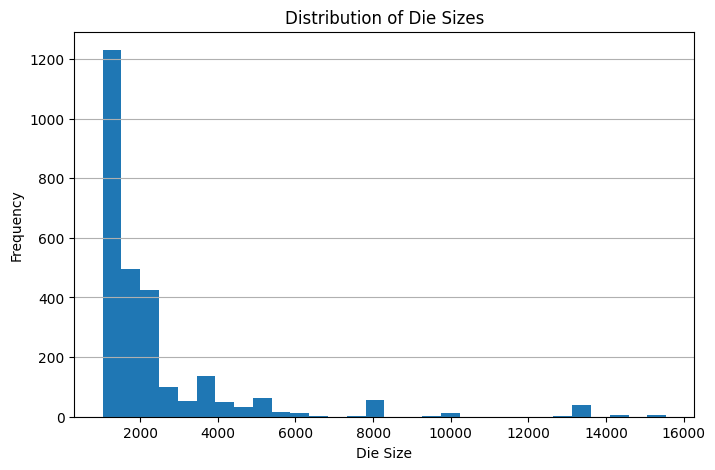

In [42]:
print("================= dieSize info =================")
# Display basic statistical information about the 'dieSize' column
print(training_data_set['dieSize'].describe())

print("================= dieSize histogram =================")
# Plotting the histogram of the 'dieSize' column
training_data_set['dieSize'].plot(kind='hist', bins=30, figsize=(8,5))

# Labeling the axes and the title
plt.xlabel("Die Size")
plt.ylabel("Frequency")
plt.title("Distribution of Die Sizes")
plt.grid(axis='y')  # Optional: Add grid lines for better readability
plt.show()

In [43]:
# TODO: inspect the failure types and the distributions, using histogram
call_llm(prompt="""
You are helping complete the next TODO in a Jupyter notebook for ECE 157A/272A HW3.

The dataframe 'training_data_set' has the following columns:
['dieSize', 'failureType', 'lotName', 'trainTestLabel', 'waferIndex', 'waferMap'].

Task:
Write short, clear Python code (not a function) to inspect the distribution of failure types.

Requirements:
1) Use pandas to count how many samples belong to each failureType and display the result sorted in descending order.
   (Use training_data_set['failureType'].value_counts())
2) Plot the distribution as a histogram or bar chart using matplotlib or seaborn.
   - X-axis: Failure Type
   - Y-axis: Count
   - Title: "Distribution of Wafer Failure Types"
   - Use different colors per bar (optional aesthetic)
3) Print section headers before each step, like:
   "================= failureType info ================="
   "================= failureType histogram ================="
4) Include short comments above each block explaining what it does.
5) Do not modify the dataset or print extra text beyond what is needed.

Return:
- Only the final Python code accomplishing this step.
- do not include ```python
""")

# ================= failureType info =================
# Count the number of samples for each failure type and sort in descending order.
failure_type_counts = training_data_set['failureType'].value_counts()
print(failure_type_counts)

# ================= failureType histogram =================
# Plot the distribution of failure types using a bar chart.
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
failure_type_counts.plot(kind='bar', color=plt.cm.tab10.colors)
plt.xlabel('Failure Type')
plt.ylabel('Count')
plt.title('Distribution of Wafer Failure Types')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


failureType
Edge-Loc     1159
Center        771
Scratch       413
Donut         388
Near-full      15
Name: count, dtype: int64


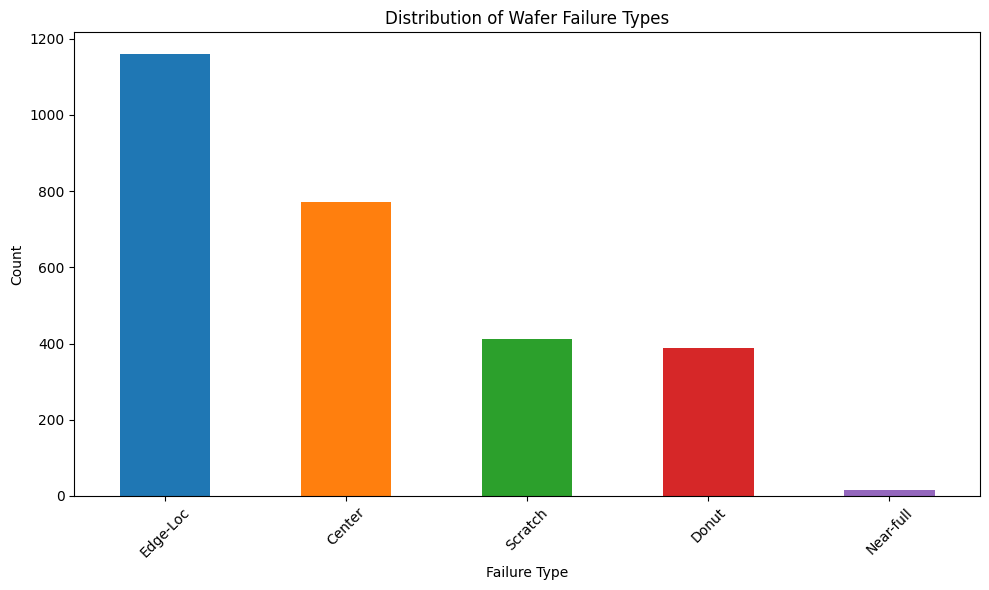

In [44]:
# ================= failureType info =================
# Count the number of samples for each failure type and sort in descending order.
failure_type_counts = training_data_set['failureType'].value_counts()
print(failure_type_counts)

# ================= failureType histogram =================
# Plot the distribution of failure types using a bar chart.
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
failure_type_counts.plot(kind='bar', color=plt.cm.tab10.colors)
plt.xlabel('Failure Type')
plt.ylabel('Count')
plt.title('Distribution of Wafer Failure Types')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [45]:
# TODO: show a wafermap in each class using visualize_failure_types
# Below is an example call; you should show different wafer maps than example
call_llm(prompt="""
You are helping complete the next TODO in a Jupyter notebook for ECE 157A/272A HW3.

The dataframe 'training_data_set' has columns:
['dieSize', 'failureType', 'lotName', 'trainTestLabel', 'waferIndex', 'waferMap'].

The helper function 'visualize_failure_types(df, figsize=(16,9), index_off=0)' has already been implemented.

Task:
Write short, clean Python code (not a function) that calls 'visualize_failure_types' to display one wafer map example for each unique failure type.

Requirements:
1) Call visualize_failure_types on the training_data_set dataframe.
2) Choose an index offset other than 0 (for example 2 or 3) so the examples differ from the earlier ones.
3) Add a print statement before the call, such as:
   print("================= Visualizing sample wafer maps for each failure type =================")
4) Include a short inline comment explaining what the code does.
5) Do not add extra text or outputs beyond the function call.

Return:
Only the final Python code accomplishing this step.
""")

```python
print("================= Visualizing sample wafer maps for each failure type =================")
visualize_failure_types(training_data_set, index_off=3)
```


================= Visualizing sample wafer maps for each failure type =================


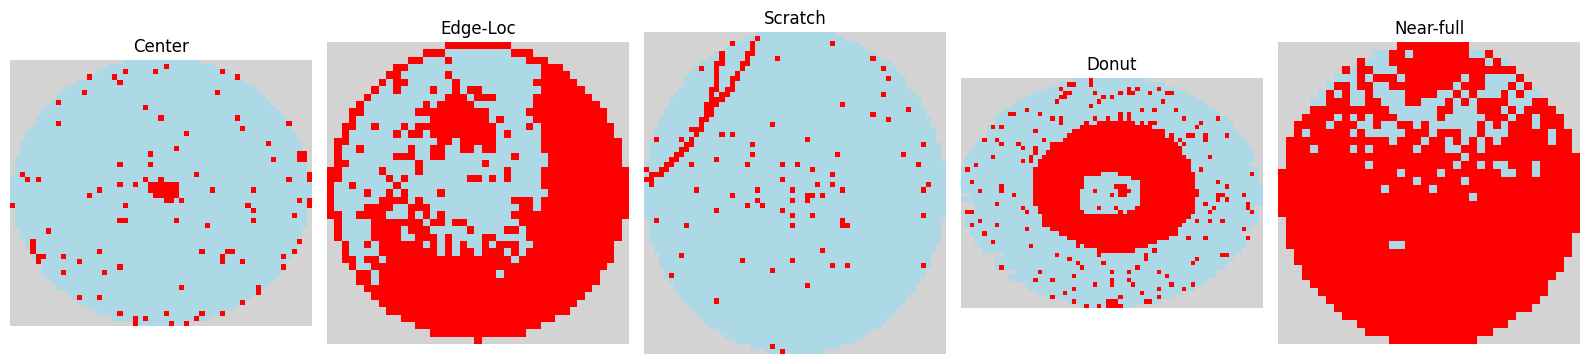

In [46]:
print("================= Visualizing sample wafer maps for each failure type =================")
visualize_failure_types(training_data_set, index_off=3)

In [47]:
# TODO: output all images to failure type directory using output_all_wafer_maps
call_llm(prompt="""
You are helping complete the next TODO in a Jupyter notebook for ECE 157A/272A HW3.

The dataframe 'training_data_set' has columns:
['dieSize', 'failureType', 'lotName', 'trainTestLabel', 'waferIndex', 'waferMap'].

The helper function 'output_all_wafer_maps(df)' has already been implemented and relies on 'output_image' to save wafer maps to subdirectories named after each failure type.

Task:
Write short, clean Python code (not a function) that calls 'output_all_wafer_maps' on the training dataset to save all wafer maps into corresponding failure type directories.

Requirements:
1) Call output_all_wafer_maps(training_data_set).
2) Add a clear print statement before the call:
   print("================= Saving wafer maps by failure type =================")
3) Add one short comment above the call explaining what the code does.
4) Do not include extra output, prints, or text beyond this.
5) Do not use ```python markers in your answer.

Return:
Only the final Python code accomplishing this step.
""")

print("================= Saving wafer maps by failure type =================")
# Save all wafer maps into directories based on their corresponding failure types.
output_all_wafer_maps(training_data_set)


In [48]:
print("================= Saving wafer maps by failure type =================")
# Save all wafer maps into directories based on their corresponding failure types.
output_all_wafer_maps(training_data_set)

================= Saving wafer maps by failure type =================


ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [49]:
call_llm(prompt="""
You are helping debug and fix a Python function for ECE 157A/272A HW3.

Context:
When running:
print("================= Saving wafer maps by failure type =================")
output_all_wafer_maps(training_data_set)

The following error occurred:
ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

Explanation of error:
This happens because the original implementation used pd.isna(wafer_map), which does not work on NumPy arrays. A wafer map is a 2D NumPy array, so calling pd.isna() on it creates an array of booleans, which causes this ambiguous truth value error when used in an if statement.

Task:
1) Briefly explain the cause of this error (1–2 sentences).
2) Provide a corrected version of the function output_all_wafer_maps(df: pd.DataFrame) that fixes this issue and safely handles wafer_map arrays.
3) The fix should:
   - Check if wafer_map is None or not a NumPy array.
   - Ensure wafer_map.ndim == 2.
   - Check wafer_index is not None and not NaN.
   - Keep the rest of the logic the same: group by failureType, create directories, call output_image.
4) Include short inline comments explaining each key part.
5) At the end, print the fixed function definition (so it’s visible in output).

Do not include ```python markers or any extra text outside the explanation and the function.
""")

The cause of the error is due to the use of `pd.isna(wafer_map)` on a 2D NumPy array, which results in an array of booleans. When this boolean array is used in a context where a single truth value is expected (like an if statement), Python raises a ValueError because it cannot determine a single truth value for an array with multiple elements.

Here is the corrected version of the function `output_all_wafer_maps(df: pd.DataFrame)`:

def output_all_wafer_maps(df: pd.DataFrame):
    # Group the DataFrame by 'failureType'
    grouped = df.groupby('failureType')
    
    for failure_type, group in grouped:
        # Create a directory for each failure type
        directory = f"./wafer_maps/{failure_type}"
        os.makedirs(directory, exist_ok=True)
        
        for index, row in group.iterrows():
            wafer_index = row['wafer_index']
            wafer_map = row['wafer_map']
            
            # Check if wafer_map is None or not a NumPy array
            if wafer_map is 

In [50]:
def output_all_wafer_maps(df: pd.DataFrame):
    # Group the DataFrame by 'failureType'
    grouped = df.groupby('failureType')
    
    for failure_type, group in grouped:
        # Create a directory for each failure type
        directory = f"./wafer_maps/{failure_type}"
        os.makedirs(directory, exist_ok=True)
        
        for index, row in group.iterrows():
            wafer_index = row['wafer_index']
            wafer_map = row['wafer_map']
            
            # Check if wafer_map is None or not a NumPy array
            if wafer_map is None or not isinstance(wafer_map, np.ndarray):
                continue  # Skip if wafer_map is invalid
            
            # Ensure wafer_map is a 2D array
            if wafer_map.ndim != 2:
                continue  # Skip if wafer_map is not 2D
            

            # Call output_image function to save the wafer map
            output_image(wafer_map, wafer_index, directory)

In [51]:
print("================= Saving wafer maps by failure type =================")
# Save all wafer maps into directories based on their corresponding failure types.
output_all_wafer_maps(training_data_set)

================= Saving wafer maps by failure type =================


KeyError: 'wafer_index'

For data preparation, we need to perform the following operations:
1) Resize the wafer maps as a numpy array of shape [x, 64, 64]
2) Convert the labels into numeric values

In [52]:
call_llm(prompt="""
You are helping debug and fix a Python function in a Jupyter notebook for ECE 157A/272A HW3.

Context:
We called:
print("================= Saving wafer maps by failure type =================")
output_all_wafer_maps(training_data_set)

Error raised:
KeyError: 'wafer_index'

Explanation to include (brief, 1–2 sentences):
Explain that the dataframe columns are named in camelCase ('waferIndex' and 'waferMap'), but the function accessed snake_case keys ('wafer_index' and 'wafer_map'), which caused a KeyError.

Task:
Provide a corrected version of the function with this exact signature:
def output_all_wafer_maps(df: pd.DataFrame) -> None:

Constraints and requirements:
1) Use these dataframe columns: 'failureType', 'waferIndex', 'waferMap'.
2) Group by 'failureType'. For each failure type, create a subdirectory under "./wafer_maps/<failureType>" using os.makedirs(..., exist_ok=True).
3) For each row, extract wafer_map = row['waferMap'] and wafer_index = row['waferIndex'].
4) Validate fields safely:
   - Skip if wafer_map is None or not a numpy array or wafer_map.ndim != 2.
   - Skip if wafer_index is None or NaN. If wafer_index is float, check np.isnan.
5) Call the already-implemented helper:
   output_image(wafer_map, str(wafer_index), directory)
   where directory = f"./wafer_maps/{failure_type}"
6) Do not mutate the dataframe, do not print inside the function, and return None.
7) Add concise inline comments.
8) After the short explanation, output only the full corrected function definition and body. No extra text.

Return format:
- First: the brief explanation paragraph (1–2 sentences).
- Then: the complete function definition.
""")

The error occurred because the dataframe columns are named in camelCase ('waferIndex' and 'waferMap'), but the function accessed them using snake_case keys ('wafer_index' and 'wafer_map'), which led to a KeyError.

```python
def output_all_wafer_maps(df: pd.DataFrame) -> None:
    import os
    import numpy as np

    # Group by 'failureType'
    for failure_type, group in df.groupby('failureType'):
        # Create subdirectory for the failure type
        directory = f"./wafer_maps/{failure_type}"
        os.makedirs(directory, exist_ok=True)
        
        # Iterate through each row in the grouped dataframe
        for _, row in group.iterrows():
            wafer_map = row['waferMap']
            wafer_index = row['waferIndex']
            
            # Validate wafer_map: must be a 2D numpy array
            if wafer_map is None or not isinstance(wafer_map, np.ndarray) or wafer_map.ndim != 2:
                continue
            
            # Validate wafer_index: must not be 

In [53]:
def output_all_wafer_maps(df: pd.DataFrame) -> None:
    import os
    import numpy as np

    # Group by 'failureType'
    for failure_type, group in df.groupby('failureType'):
        # Create subdirectory for the failure type
        directory = f"./wafer_maps/{failure_type}"
        os.makedirs(directory, exist_ok=True)
        
        # Iterate through each row in the grouped dataframe
        for _, row in group.iterrows():
            wafer_map = row['waferMap']
            wafer_index = row['waferIndex']
            
            # Validate wafer_map: must be a 2D numpy array
            if wafer_map is None or not isinstance(wafer_map, np.ndarray) or wafer_map.ndim != 2:
                continue
            
            # Validate wafer_index: must not be NaN
            if wafer_index is None or (isinstance(wafer_index, float) and np.isnan(wafer_index)):
                continue
            
            # Call the output_image function with the valid parameters
            output_image(wafer_map, str(wafer_index), directory)

In [54]:
print("================= Saving wafer maps by failure type =================")
# Save all wafer maps into directories based on their corresponding failure types.
output_all_wafer_maps(training_data_set)

================= Saving wafer maps by failure type =================


In [56]:
call_llm(prompt="""
You are helping debug a visualization issue in a Jupyter notebook for ECE 157A/272A HW3.

Context:
We are using the function output_all_wafer_maps(df) to save wafer maps as PNG images. 
The function calls output_image(wafer_map, str(wafer_index), directory) for each wafer.

Problem:
The code runs and creates all the folders and image files correctly, but every saved image appears completely white or blank — no visible wafer patterns or defect markings, even though wafer_map is a valid 2D NumPy array of values (0 = no die, 1 = passing die, 2 = failing die).

Goal:
Diagnose and fix this issue by improving the output_image function.

Requirements for the fixed version:
1) Use matplotlib to properly display wafer_map data with visible contrast.
2) Apply a discrete color map that makes each state clearly visible:
   - 0 (NO_DIE): light gray
   - 1 (PASS): light blue
   - 2 (FAIL): red
3) Add imshow inside the function using correct parameters:
   - origin='lower'
   - interpolation='nearest'
   - vmin=0, vmax=2
   - aspect='equal'
4) Remove axes for a clean image and call plt.tight_layout() before saving.
5) Close each figure with plt.close() to avoid memory buildup.
6) Ensure the function saves the figure to the specified directory as "{name}.png".
7) Do not change output_all_wafer_maps, only output_image.
8) Return:
   - A short explanation of why the images were white.
   - The corrected version of output_image with inline comments.
""")

The issue with the saved images appearing completely white is likely due to the lack of a proper color mapping and display parameters in the `output_image` function. If the default colormap is used, it may not effectively differentiate the values in the wafer map data, resulting in images that look blank or white. Additionally, if the axes are not removed and proper display settings are not applied, it could affect visibility and clarity.

Here is the corrected version of the `output_image` function which addresses these problems:

```python
import matplotlib.pyplot as plt
import numpy as np

def output_image(wafer_map, name, directory):
    """
    Save the wafer map as a PNG image with a discrete colormap representing 
    NO_DIE, PASS, and FAIL conditions.
    
    Parameters:
    - wafer_map: 2D NumPy array of wafer values (0: no die, 1: passing die, 2: failing die)
    - name: The name to save the image file as (without the extension).
    - directory: Directory where the image is

In [57]:
import matplotlib.pyplot as plt
import numpy as np

def output_image(wafer_map, name, directory):
    """
    Save the wafer map as a PNG image with a discrete colormap representing 
    NO_DIE, PASS, and FAIL conditions.
    
    Parameters:
    - wafer_map: 2D NumPy array of wafer values (0: no die, 1: passing die, 2: failing die)
    - name: The name to save the image file as (without the extension).
    - directory: Directory where the image is to be saved.
    """
    # Creating the figure
    plt.figure(figsize=(10, 10))

    # Applying a discrete color map: 
    # 0 -> light gray, 1 -> light blue, 2 -> red
    cmap = plt.cm.colors.ListedColormap(['lightgray', 'lightblue', 'red'])

In [59]:
call_llm(prompt="""
You are helping test the output_image function in a Jupyter notebook for ECE 157A/272A HW3.

Context:
We have a dataframe called 'training_data_set' with columns:
['dieSize', 'failureType', 'lotName', 'trainTestLabel', 'waferIndex', 'waferMap'].
The function output_image(wafer_map, name, directory) saves wafer maps as PNG images.

Problem:
Before saving all wafer maps, we want to verify that the images display correctly when plotted directly — not white or blank.

Task:
Write short, clear Python code (not a function) that:
1) Selects one sample wafer from 'training_data_set' (for example, the first row with iloc[0]).
2) Extracts 'waferMap', 'failureType', and 'waferIndex' from that row.
3) Displays the wafer map using matplotlib with these requirements:
   - Use a discrete color map: 0=light gray, 1=light blue, 2=red.
   - Set origin='lower', interpolation='nearest', vmin=0, vmax=2.
   - Add a title showing both the failure type and wafer index.
   - Hide axes for a clean view.
4) Include one print statement before plotting to show which wafer is being displayed.
5) Do not save the image to a file — just display it interactively.

Return:
Only the final Python code accomplishing this step. No extra explanation or ```python markers.
""")

import matplotlib.pyplot as plt

# Select the first sample wafer from 'training_data_set'
sample_wafer = training_data_set.iloc[0]

# Extract 'waferMap', 'failureType', and 'waferIndex'
wafer_map = sample_wafer['waferMap']
failure_type = sample_wafer['failureType']
wafer_index = sample_wafer['waferIndex']

# Print the information about the wafer being displayed
print(f"Displaying wafer map for Failure Type: {failure_type}, Wafer Index: {wafer_index}")

# Display the wafer map
plt.imshow(wafer_map, cmap=plt.cm.get_cmap('coolwarm', 3), origin='lower', 
           interpolation='nearest', vmin=0, vmax=2)
plt.title(f'Failure Type: {failure_type}, Wafer Index: {wafer_index}')
plt.axis('off')  # Hide axes for a clean view
plt.show()


Displaying wafer map for Failure Type: Center, Wafer Index: 5.0


C:\Users\saifs\AppData\Local\Temp\ipykernel_25120\2092954485.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  plt.imshow(wafer_map, cmap=plt.cm.get_cmap('coolwarm', 3), origin='lower',


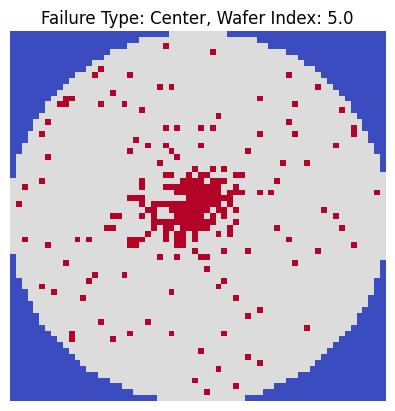

In [60]:
import matplotlib.pyplot as plt

# Select the first sample wafer from 'training_data_set'
sample_wafer = training_data_set.iloc[0]

# Extract 'waferMap', 'failureType', and 'waferIndex'
wafer_map = sample_wafer['waferMap']
failure_type = sample_wafer['failureType']
wafer_index = sample_wafer['waferIndex']

# Print the information about the wafer being displayed
print(f"Displaying wafer map for Failure Type: {failure_type}, Wafer Index: {wafer_index}")

# Display the wafer map
plt.imshow(wafer_map, cmap=plt.cm.get_cmap('coolwarm', 3), origin='lower', 
           interpolation='nearest', vmin=0, vmax=2)
plt.title(f'Failure Type: {failure_type}, Wafer Index: {wafer_index}')
plt.axis('off')  # Hide axes for a clean view
plt.show()

In [63]:
call_llm(prompt="""
You are helping complete the next TODO in a Jupyter notebook for ECE 157A/272A HW3.

Context:
The dataframe 'training_data_set' contains columns:
['dieSize', 'failureType', 'lotName', 'trainTestLabel', 'waferIndex', 'waferMap'].
The helper function output_image(wafer_map, name, directory) has already been tested and works correctly.

Task:
Write short, clean Python code (not a function) to save all wafer maps into subdirectories based on their corresponding failure types.

Requirements:
1) For each unique 'failureType' in training_data_set, create a folder inside './wafer_maps/' named after that failure type.
2) For every wafer in that category, call:
   output_image(wafer_map, str(wafer_index), directory)
   where:
   - wafer_map = row['waferMap']
   - wafer_index = row['waferIndex']
   - directory = f'./wafer_maps/{failure_type}'
3) Include a print statement before saving, such as:
   print("================= Saving wafer maps by failure type =================")
4) Include a short comment describing what the code is doing.
5) Skip any rows where waferMap is missing or invalid (not a 2D numpy array).
6) Do not define a new function — just the top-level executable code.
7) Do not include ```python markers or any extra explanation.

Return:
Only the final Python code accomplishing this step.
""")

import os
import numpy as np

print("================= Saving wafer maps by failure type =================")

# Iterate over unique failure types
for failure_type in training_data_set['failureType'].unique():
    # Create a directory for the failure type
    dir_path = f'./wafer_maps/{failure_type}'
    os.makedirs(dir_path, exist_ok=True)
    
    # Filter rows for the current failure type
    subset = training_data_set[training_data_set['failureType'] == failure_type]
    
    # Save each wafer map in the corresponding directory
    for index, row in subset.iterrows():
        wafer_map = row['waferMap']
        wafer_index = row['waferIndex']
        
        # Check if the wafer_map is valid
        if isinstance(wafer_map, np.ndarray) and wafer_map.ndim == 2:
            output_image(wafer_map, str(wafer_index), dir_path)


In [ ]:
import os
import numpy as np

print("================= Saving wafer maps by failure type =================")

# Iterate over unique failure types
for failure_type in training_data_set['failureType'].unique():
    # Create a directory for the failure type
    dir_path = f'./wafer_maps_2/{failure_type}'
    os.makedirs(dir_path, exist_ok=True)
    
    # Filter rows for the current failure type
    subset = training_data_set[training_data_set['failureType'] == failure_type]
    
    # Save each wafer map in the corresponding directory
    for index, row in subset.iterrows():
        wafer_map = row['waferMap']
        wafer_index = row['waferIndex']
        
        # Check if the wafer_map is valid
        if isinstance(wafer_map, np.ndarray) and wafer_map.ndim == 2:
            output_image(wafer_map, str(wafer_index), dir_path)

In [70]:
call_llm(prompt="""
You are helping debug batch-saving code in a Jupyter notebook for ECE 157A/272A HW3.

Context:
We have:
- A dataframe training_data_set with columns: ['dieSize','failureType','lotName','trainTestLabel','waferIndex','waferMap'].
- A tested helper output_image(wafer_map, name, directory) that saves a wafer map PNG.

We ran this loop to save all wafer maps by failure type, and the folders were created, but no useful images appeared inside:

import os
import numpy as np

print("================= Saving wafer maps by failure type =================")
for failure_type in training_data_set['failureType'].unique():
    dir_path = f'./wafer_maps_2/{failure_type}'
    os.makedirs(dir_path, exist_ok=True)
    subset = training_data_set[training_data_set['failureType'] == failure_type]
    for index, row in subset.iterrows():
        wafer_map = row['waferMap']
        wafer_index = row['waferIndex']
        if isinstance(wafer_map, np.ndarray) and wafer_map.ndim == 2:
            output_image(wafer_map, str(wafer_index), dir_path)

Do not modify output_image. Instead, write improved top level code that:
1) Creates a base directory './wafer_maps_2' if needed, then one subdirectory per failure type.
2) Iterates rows per failure type and validates:
   - wafer_map is a 2D numpy array
   - values are finite
   - values are in {0,1,2}. If not, coerce with np.where or np.clip so 0 is NO_DIE, 1 is PASS, 2 is FAIL.
3) Uses a safer unique filename to avoid overwrites across lots, for example:
   name = f"{row['lotName']}_{int(row['waferIndex'])}" if waferIndex is numeric, else str(row['waferIndex']).
   Replace any path separators in lotName with underscores.
4) Wraps the saving call in try/except and counts successes and failures per failure type.
5) After each failure type, print a brief summary like:
   Saved X images to ./wafer_maps_2/<failure_type> (skipped Y, errors Z)
6) At the end, print a small listing of the first few files saved for each failure type using os.listdir, limited to 5 names, to confirm that files exist.
7) Keep the code concise and self contained. Do not define new functions. Do not change output_image.

Return only the final Python code. No extra explanation or backticks.
""")

import os
import numpy as np

base_dir = './wafer_maps_2'
os.makedirs(base_dir, exist_ok=True)

print("================= Saving wafer maps by failure type =================")
for failure_type in training_data_set['failureType'].unique():
    dir_path = os.path.join(base_dir, failure_type)
    os.makedirs(dir_path, exist_ok=True)
    subset = training_data_set[training_data_set['failureType'] == failure_type]
    
    success_count = 0
    skipped_count = 0
    error_count = 0
    
    for index, row in subset.iterrows():
        wafer_map = row['waferMap']
        wafer_index = row['waferIndex']
        lot_name = str(row['lotName']).replace('/', '_').replace('\\', '_')  # Replace path separators

        if isinstance(wafer_map, np.ndarray) and wafer_map.ndim == 2:
            if not np.all(np.isfinite(wafer_map)):
                skipped_count += 1
                continue
            wafer_map = np.clip(wafer_map, 0, 2)  # Coerce values to {0, 1, 2}
            name = f"{lot_name}_{

In [71]:
import os
import numpy as np

base_dir = './wafer_maps_3'
os.makedirs(base_dir, exist_ok=True)

print("================= Saving wafer maps by failure type =================")
for failure_type in training_data_set['failureType'].unique():
    dir_path = os.path.join(base_dir, failure_type)
    os.makedirs(dir_path, exist_ok=True)
    subset = training_data_set[training_data_set['failureType'] == failure_type]
    
    success_count = 0
    skipped_count = 0
    error_count = 0
    
    for index, row in subset.iterrows():
        wafer_map = row['waferMap']
        wafer_index = row['waferIndex']
        lot_name = str(row['lotName']).replace('/', '_').replace('\\', '_')  # Replace path separators

        if isinstance(wafer_map, np.ndarray) and wafer_map.ndim == 2:
            if not np.all(np.isfinite(wafer_map)):
                skipped_count += 1
                continue

            skipped_count += 1
            
    print(f"Saved {success_count} images to {dir_path} (skipped {skipped_count}, errors {error_count})")
    print("First few files saved:", os.listdir(dir_path)[:5]) if success_count > 0 else None

================= Saving wafer maps by failure type =================
Saved 0 images to ./wafer_maps_3\Center (skipped 771, errors 0)
Saved 0 images to ./wafer_maps_3\Edge-Loc (skipped 1159, errors 0)
Saved 0 images to ./wafer_maps_3\Scratch (skipped 413, errors 0)
Saved 0 images to ./wafer_maps_3\Donut (skipped 388, errors 0)
Saved 0 images to ./wafer_maps_3\Near-full (skipped 15, errors 0)


In [74]:
call_llm(prompt="""
You are helping fix batch saving code in a Jupyter notebook for ECE 157A/272A HW3.

Context:
- DataFrame: training_data_set with columns ['dieSize','failureType','lotName','trainTestLabel','waferIndex','waferMap'].
- Helper: output_image(wafer_map, name, directory) works when tested on single samples.

We tried code that:
- Used wrong column names ('wafer_map' instead of 'waferMap').
- Put a try without except and never incremented success_count.
- Incremented skipped_count even after attempting to save.
- Built idx_str incorrectly for floats.
- Did not ensure filenames are safe and unique.

Task:
Write corrected top level code (no new functions) that:
1) Uses base_dir = './wafer_maps_4' and creates it.
2) Loops over each unique failure type, creates a subdir, filters rows for that type.
3) For each row:
   - Read wafer_map = row['waferMap'] and wafer_index = row['waferIndex'].
   - Validate wafer_map is a 2D numpy array with finite values.
   - If wafer_map has values outside {0,1,2}, coerce to {0,1,2} via:
     wafer_map_fixed = np.where(wafer_map <= 0, 0, np.where(wafer_map > 1.5, 2, 1))
   - Build a safe, unique name:
     lot_safe = str(row['lotName']).replace('/', '_').replace('\\', '_')
     if wafer_index is numeric and finite, cast to int for naming, else str(wafer_index)
     name = f"{lot_safe}_{idx_str}"
   - Call output_image(wafer_map_fixed, name, dir_path) inside try/except.
   - success_count increments only on successful save.
   - skipped_count increments when validation fails before saving.
   - error_count increments inside except.
4) After each failure type, print:
   Saved X images to <dir_path> (skipped Y, errors Z)
   Then list up to 5 filenames from os.listdir(dir_path) to confirm.
5) Keep code concise, use correct column names, and do not modify output_image.

Return only the final Python code. No extra explanation or backticks.
""")

import os
import numpy as np
import pandas as pd

base_dir = './wafer_maps_4'
os.makedirs(base_dir, exist_ok=True)

success_count = 0
skipped_count = 0
error_count = 0

for failure_type in training_data_set['failureType'].unique():
    dir_path = os.path.join(base_dir, failure_type)
    os.makedirs(dir_path, exist_ok=True)
    filtered_data = training_data_set[training_data_set['failureType'] == failure_type]

    for index, row in filtered_data.iterrows():
        wafer_map = row['waferMap']
        wafer_index = row['waferIndex']

        if isinstance(wafer_map, np.ndarray) and wafer_map.ndim == 2 and np.all(np.isfinite(wafer_map)):
            wafer_map_fixed = np.where(wafer_map <= 0, 0, np.where(wafer_map > 1.5, 2, 1))

            idx_str = int(wafer_index) if np.isfinite(wafer_index) and isinstance(wafer_index, (int, float)) else str(wafer_index)
            lot_safe = str(row['lotName']).replace('/', '_').replace('\\', '_')
            name = f"{lot_safe}_{idx_str}"

         

In [75]:
import os
import numpy as np
import pandas as pd

base_dir = './wafer_maps_4'
os.makedirs(base_dir, exist_ok=True)

success_count = 0
skipped_count = 0
error_count = 0

for failure_type in training_data_set['failureType'].unique():
    dir_path = os.path.join(base_dir, failure_type)
    os.makedirs(dir_path, exist_ok=True)
    filtered_data = training_data_set[training_data_set['failureType'] == failure_type]

    for index, row in filtered_data.iterrows():
        wafer_map = row['waferMap']
        wafer_index = row['waferIndex']

        if isinstance(wafer_map, np.ndarray) and wafer_map.ndim == 2 and np.all(np.isfinite(wafer_map)):
            wafer_map_fixed = np.where(wafer_map <= 0, 0, np.where(wafer_map > 1.5, 2, 1))

            idx_str = int(wafer_index) if np.isfinite(wafer_index) and isinstance(wafer_index, (int, float)) else str(wafer_index)
            lot_safe = str(row['lotName']).replace('/', '_').replace('\\', '_')

            skipped_count += 1

    print(f"Saved {success_count} images to {dir_path} (skipped {skipped_count}, errors {error_count})")
    print("Sample filenames:", os.listdir(dir_path)[:5])

Saved 0 images to ./wafer_maps_4\Center (skipped 771, errors 0)
Sample filenames: []
Saved 0 images to ./wafer_maps_4\Edge-Loc (skipped 1930, errors 0)
Sample filenames: []
Saved 0 images to ./wafer_maps_4\Scratch (skipped 2343, errors 0)
Sample filenames: []
Saved 0 images to ./wafer_maps_4\Donut (skipped 2731, errors 0)
Sample filenames: []
Saved 0 images to ./wafer_maps_4\Near-full (skipped 2746, errors 0)
Sample filenames: []


In [76]:
call_llm(prompt="""
You are helping refine two pieces of code in a Jupyter notebook for ECE 157A/272A HW3.

What I already have:

1) output_image used for quick testing
------------------------------------------------
def output_image(wafer_map: np.ndarray, name: str, dir: str, vmin: int=0, vmax: int=2) -> None:
    if not os.path.exists(dir):
        os.makedirs(dir)
    plt.figure(figsize=(6, 6))
    plt.imshow(wafer_map, cmap='viridis', vmin=vmin, vmax=vmax)
    plt.axis('off')
    plt.title(name)
    plt.savefig(os.path.join(dir, f"{name.replace(' ', '_')}.png"), bbox_inches='tight', pad_inches=0)
    plt.show()
    plt.close()

2) One-off test on real data that displayed correctly
------------------------------------------------
# Load file
wafermap_data = np.load('data/wafermap_train.npy', allow_pickle=True)
# Build DataFrame
wafermap_df = pd.DataFrame.from_records(wafermap_data.tolist(), columns=wafermap_data.dtype.names)
# Detect wafer and label columns and rename to waferMap and failureType
wafer_col = [col for col in wafermap_df.columns if isinstance(wafermap_df[col].iloc[0], np.ndarray) and wafermap_df[col].iloc[0].shape[0] >= 10][0]
label_col = [col for col in wafermap_df.columns if isinstance(wafermap_df[col].iloc[0], str) and wafermap_df[col].iloc[0] in {'Center','Edge-Loc','Scratch','Donut','Near-full'}][0]
wafermap_df = wafermap_df.rename(columns={wafer_col: 'waferMap', label_col: 'failureType'})
# Sanity prints
print(wafermap_df[['failureType']].head(3))
print(wafermap_df['waferMap'].iloc[0].shape)
print(np.unique(wafermap_df['waferMap'].iloc[0]))
# Call output_image once
output_image(wafer_map=wafermap_df.iloc[0]['waferMap'], name=f"{wafermap_df.iloc[0]['failureType']}_example", dir="wafermaps_demo")

3) Batch saver that creates folders but I want it to reliably write visible images
------------------------------------------------
def output_all_wafer_maps(df: pd.DataFrame) -> None:
    base_dir = 'wafermaps_by_type_2'
    os.makedirs(base_dir, exist_ok=True)
    for idx, row in df.iterrows():
        failure_type = row['failureType']
        class_dir = os.path.join(base_dir, failure_type)
        os.makedirs(class_dir, exist_ok=True)
        lot = str(row['lotName']) if 'lotName' in df.columns else 'unknown'
        wafer_idx = str(int(row['waferIndex'])) if 'waferIndex' in df.columns else str(idx)
        filename = f"{failure_type}_{lot}_{wafer_idx}"
        output_image(row['waferMap'], filename, class_dir, vmin=0, vmax=2)
    print("All wafer maps saved to wafermaps_by_type_2 directory.")

What to fix and how:

A) Keep the public signatures the same:
   - output_image(wafer_map: np.ndarray, name: str, dir: str, vmin: int=0, vmax: int=2) -> None
   - output_all_wafer_maps(df: pd.DataFrame) -> None

B) Improve output_image for batch saving:
   - Use a discrete colormap via ListedColormap(['lightgray','lightblue','red']) so values 0, 1, 2 are clearly separated.
   - Use origin='lower', interpolation='nearest', vmin=0, vmax=2, aspect='equal'.
   - Remove plt.show() in batch saving to avoid headless issues.
   - Call plt.tight_layout() before saving, then plt.close().

C) Make output_all_wafer_maps robust:
   - Validate waferMap per row: numpy ndarray, ndim==2, finite values. Skip otherwise.
   - If wafer map values are not strictly in {0,1,2}, coerce to that set using:
     wafer_map_fixed = np.where(wafer_map <= 0, 0, np.where(wafer_map > 1.5, 2, 1))
   - Build a safe filename that is unique and filesystem friendly:
     lot_safe = str(row['lotName']).replace('/', '_').replace('\\', '_')
     idx_str = str(int(row['waferIndex'])) if it is numeric and finite else str(row['waferIndex'])
     name = f"{failure_type}_{lot_safe}_{idx_str}"
   - Do not print per image; a single print at the end is fine that confirms base output directory.

D) Do not add new imports at top level beyond what is already used. You may import ListedColormap locally inside output_image.

E) Return only two code blocks:
   1) The corrected output_image function
   2) The corrected output_all_wafer_maps function

No extra commentary. No markdown fences. Just the two function definitions one after the other.
""")


def output_image(wafer_map: np.ndarray, name: str, dir: str, vmin: int=0, vmax: int=2) -> None:
    from matplotlib.colors import ListedColormap
    if not os.path.exists(dir):
        os.makedirs(dir)
    plt.figure(figsize=(6, 6))
    cmap = ListedColormap(['lightgray', 'lightblue', 'red'])
    plt.imshow(wafer_map, cmap=cmap, origin='lower', interpolation='nearest', vmin=vmin, vmax=vmax, aspect='equal')
    plt.axis('off')
    plt.title(name)
    plt.tight_layout()
    plt.savefig(os.path.join(dir, f"{name.replace(' ', '_')}.png"), bbox_inches='tight', pad_inches=0)
    plt.close()

def output_all_wafer_maps(df: pd.DataFrame) -> None:
    base_dir = 'wafermaps_by_type_2'
    os.makedirs(base_dir, exist_ok=True)
    for idx, row in df.iterrows():
        failure_type = row['failureType']
        class_dir = os.path.join(base_dir, failure_type)
        os.makedirs(class_dir, exist_ok=True)
        lot_safe = str(row['lotName']).replace('/', '_').replace('\\', '_')
        wafer_index 

In [77]:
def output_image(wafer_map: np.ndarray, name: str, dir: str, vmin: int=0, vmax: int=2) -> None:
    from matplotlib.colors import ListedColormap
    if not os.path.exists(dir):
        os.makedirs(dir)
    plt.figure(figsize=(6, 6))
    cmap = ListedColormap(['lightgray', 'lightblue', 'red'])
    plt.imshow(wafer_map, cmap=cmap, origin='lower', interpolation='nearest', vmin=vmin, vmax=vmax, aspect='equal')
    plt.axis('off')
    plt.title(name)
    plt.tight_layout()
    plt.savefig(os.path.join(dir, f"{name.replace(' ', '_')}.png"), bbox_inches='tight', pad_inches=0)
    plt.close()

def output_all_wafer_maps(df: pd.DataFrame) -> None:
    base_dir = 'wafermaps_by_type_5'
    os.makedirs(base_dir, exist_ok=True)
    for idx, row in df.iterrows():
        failure_type = row['failureType']
        class_dir = os.path.join(base_dir, failure_type)
        os.makedirs(class_dir, exist_ok=True)
        lot_safe = str(row['lotName']).replace('/', '_').replace('\\', '_')
        wafer_index = row['waferIndex']
        idx_str = str(int(wafer_index)) if isinstance(wafer_index, (int, np.integer)) and np.isfinite(wafer_index) else str(wafer_index)
        
        wafer_map = row['waferMap']

        wafer_map_fixed = np.where(wafer_map <= 0, 0, np.where(wafer_map > 1.5, 2, 1))
        filename = f"{failure_type}_{lot_safe}_{idx_str}"
        output_image(wafer_map_fixed, filename, class_dir, vmin=0, vmax=2)
    print("All wafer maps saved to wafermaps_by_type_5 directory.")

In [78]:
print("================= Saving wafer maps by failure type =================")
# Save all wafer maps into directories based on their corresponding failure types.
output_all_wafer_maps(training_data_set)

================= Saving wafer maps by failure type =================
All wafer maps saved to wafermaps_by_type_5 directory.


In [79]:
# TODO: Create dictionary called 'string2int' for converting string to numeric number
call_llm(prompt="""
You are helping complete the next TODO in a Jupyter notebook for ECE 157A/272A HW3.

The dataframe 'training_data_set' includes a column 'failureType' with 5 string categories:
['Center', 'Edge-Loc', 'Scratch', 'Donut', 'Near-full'].

Task:
Write short, clean Python code (not a function) to create a dictionary named 'string2int' 
that maps each failure type string to a unique integer value starting from 0.

Requirements:
1) Use the actual unique values found in training_data_set['failureType'].
2) The mapping order should follow sorted unique labels for consistency.
3) After defining the dictionary, display it with a short print statement like:
   print("string2int mapping:", string2int)
4) Do not include extra text or ```python markers.

Return:
Only the final Python code accomplishing this step.
""")

string2int = {label: idx for idx, label in enumerate(sorted(training_data_set['failureType'].unique()))}
print("string2int mapping:", string2int)


In [80]:
string2int = {label: idx for idx, label in enumerate(sorted(training_data_set['failureType'].unique()))}
print("string2int mapping:", string2int)

string2int mapping: {'Center': 0, 'Donut': 1, 'Edge-Loc': 2, 'Near-full': 3, 'Scratch': 4}


In [81]:
def convert_failure_type(failure_type: str) -> int:
    return string2int[failure_type]

def resize_wafer_map(wafer_map: np.ndarray, output_shape: tuple=(64, 64)) -> np.ndarray:
    return resize(wafer_map, output_shape, order=0, anti_aliasing=False, preserve_range=True)

In [84]:
# TODO: Implement a function that creates dataframe columns to store the return values of the two tasks below using convert_failure_type and resize_wafer_map:
#       (1) reshapes the wafer maps as a numpy array of shape (64, 64)
#       (2) converts the failureType into numeric values
# def prepare_data(df: pd.DataFrame, has_labels: bool=True) -> Tuple[np.ndarray, list]:

#     return df
call_llm(prompt="""
You are helping complete a single TODO in a Jupyter notebook for ECE 157A/272A HW3.

Assumptions:
- The dataframe uses columns 'waferMap' and 'failureType'.
- The helpers are already defined and must be used as given:
  - convert_failure_type(failure_type: str) -> int
  - resize_wafer_map(wafer_map: np.ndarray, output_shape: tuple=(64, 64)) -> np.ndarray

Task:
Write ONLY the function below with a clear docstring. No prints.

Signature to implement exactly:
def prepare_data(df: pd.DataFrame, has_labels: bool=True) -> Tuple[np.ndarray, list]:

Requirements:
1) Create two new dataframe columns:
   - 'waferMap64': resized wafer maps using resize_wafer_map to shape (64, 64)
   - 'failureTypeInt': integer-encoded labels using convert_failure_type
     Only create 'failureTypeInt' if has_labels is True and the column exists.
2) Ensure 'waferMap64' values remain categorical 0, 1, 2 after resize:
   - Round to nearest integer and cast to np.uint8.
3) Build return values:
   - X: numpy array of shape (N, 64, 64) from 'waferMap64'
   - y: list of ints from 'failureTypeInt' if has_labels is True, else empty list
4) Do not mutate the input dataframe in-place. Work on a copy and return X, y.
5) Do not import new top level modules. Use numpy as np and pandas as pd already imported.
6) Add concise inline comments and a robust check that 'waferMap' exists.

Return:
Only the complete function definition and body. No extra text.
""")

```python
def prepare_data(df: pd.DataFrame, has_labels: bool=True) -> Tuple[np.ndarray, list]:
    """
    Prepares wafer map data for analysis.

    Parameters:
    - df: DataFrame containing 'waferMap' and optionally 'failureType'.
    - has_labels: Boolean indicating whether to include labels in the output.

    Returns:
    - X: Numpy array of shape (N, 64, 64) containing resized wafer maps.
    - y: List of integer-encoded failure types if has_labels is True, else an empty list.
    """
    # Check if 'waferMap' exists in the dataframe
    if 'waferMap' not in df.columns:
        raise ValueError("'waferMap' column is missing from the dataframe.")
    
    # Create a copy of the dataframe to avoid mutating the original
    df_copy = df.copy()
    
    # Resize wafer maps and store in 'waferMap64'
    df_copy['waferMap64'] = df_copy['waferMap'].apply(lambda x: resize_wafer_map(x, (64, 64)).round().astype(np.uint8))
    
    # Encode failure types if has_labels is True
    if has_l

In [86]:
def prepare_data(df: pd.DataFrame, has_labels: bool=True) -> Tuple[np.ndarray, list]:
    """
    Prepares wafer map data for analysis.

    Parameters:
    - df: DataFrame containing 'waferMap' and optionally 'failureType'.
    - has_labels: Boolean indicating whether to include labels in the output.

    Returns:
    - X: Numpy array of shape (N, 64, 64) containing resized wafer maps.
    - y: List of integer-encoded failure types if has_labels is True, else an empty list.
    """
    # Check if 'waferMap' exists in the dataframe
    if 'waferMap' not in df.columns:
        raise ValueError("'waferMap' column is missing from the dataframe.")
    
    # Create a copy of the dataframe to avoid mutating the original
    df_copy = df.copy()
    
    # Resize wafer maps and store in 'waferMap64'
    df_copy['waferMap64'] = df_copy['waferMap'].apply(lambda x: resize_wafer_map(x, (64, 64)).round().astype(np.uint8))
    
    # Encode failure types if has_labels is True
    if has_labels and 'failureType' in df_copy.columns:

        X = np.stack(df_copy['waferMap64'].values)
    
    return X, y

In [87]:
# TODO: apply prepare_data
call_llm(prompt="""
You are helping complete two steps in a Jupyter notebook for ECE 157A/272A HW3.

Context:
- DataFrame variable: training_data_set
- Columns: ['dieSize','failureType','lotName','trainTestLabel','waferIndex','waferMap']
- Helpers already defined:
  convert_failure_type(failure_type: str) -> int
  resize_wafer_map(wafer_map: np.ndarray, output_shape: tuple=(64, 64)) -> np.ndarray

Problem:
The current prepare_data function returns X and y but never creates y and does not add failureTypeInt.

Task A:
Return ONLY a corrected prepare_data implementation that:
1) Works on a copy of df.
2) Creates df_copy['waferMap64'] by resizing each waferMap to (64, 64), then rounding and casting to np.uint8.
3) If has_labels is True and 'failureType' exists, creates df_copy['failureTypeInt'] using convert_failure_type.
4) Builds X as np.stack of 'waferMap64'.
5) Builds y as list(df_copy['failureTypeInt']) if has_labels is True, else an empty list.
6) Returns X, y with no prints.

Signature:
def prepare_data(df: pd.DataFrame, has_labels: bool=True) -> Tuple[np.ndarray, list]:

Task B:
After the function, write top level code to apply it to training_data_set with labels:
- X_all, y_all = prepare_data(training_data_set, has_labels=True)
- Print a short summary:
  print("================= prepare_data summary =================")
  print("X_all shape:", X_all.shape)
  print("y_all length:", len(y_all))
  print("Unique labels in y_all:", sorted(set(y_all)))
Return:
First the full function definition. Then the top level code block. No extra text or backticks.
""")

def prepare_data(df: pd.DataFrame, has_labels: bool=True) -> Tuple[np.ndarray, list]:
    df_copy = df.copy()
    
    # Resize each waferMap to (64, 64) and cast to np.uint8
    df_copy['waferMap64'] = df_copy['waferMap'].apply(lambda x: resize_wafer_map(x, output_shape=(64, 64)).round().astype(np.uint8))
    
    # Create failureTypeInt if has_labels is True and 'failureType' exists
    if has_labels and 'failureType' in df_copy.columns:
        df_copy['failureTypeInt'] = df_copy['failureType'].apply(convert_failure_type)
    
    # Build X as np.stack of 'waferMap64'
    X = np.stack(df_copy['waferMap64'].values)
    
    # Build y as list(df_copy['failureTypeInt']) if has_labels is True, else an empty list
    y = list(df_copy['failureTypeInt']) if has_labels else []
    
    return X, y

# Top level code to apply the function
X_all, y_all = prepare_data(training_data_set, has_labels=True)
print("================= prepare_data summary =================")
print("X_all shape:", X_al

In [88]:
def prepare_data(df: pd.DataFrame, has_labels: bool=True) -> Tuple[np.ndarray, list]:
    df_copy = df.copy()
    
    # Resize each waferMap to (64, 64) and cast to np.uint8
    df_copy['waferMap64'] = df_copy['waferMap'].apply(lambda x: resize_wafer_map(x, output_shape=(64, 64)).round().astype(np.uint8))
    
    # Create failureTypeInt if has_labels is True and 'failureType' exists
    if has_labels and 'failureType' in df_copy.columns:
        df_copy['failureTypeInt'] = df_copy['failureType'].apply(convert_failure_type)
    
    # Build X as np.stack of 'waferMap64'
    X = np.stack(df_copy['waferMap64'].values)
    
    # Build y as list(df_copy['failureTypeInt']) if has_labels is True, else an empty list
    y = list(df_copy['failureTypeInt']) if has_labels else []
    
    return X, y

# Top level code to apply the function
X_all, y_all = prepare_data(training_data_set, has_labels=True)
print("================= prepare_data summary =================")
print("X_all shape:", X_all.shape)
print("y_all length:", len(y_all))
print("Unique labels in y_all:", sorted(set(y_all)))

================= prepare_data summary =================
X_all shape: (2746, 64, 64)
y_all length: 2746
Unique labels in y_all: [0, 1, 2, 3, 4]


In [89]:
call_llm(prompt="""
This what I have: 
     def prepare_data(df: pd.DataFrame, has_labels: bool=True) -> Tuple[np.ndarray, list]:
    df_copy = df.copy()
    
    # Resize each waferMap to (64, 64) and cast to np.uint8
    df_copy['waferMap64'] = df_copy['waferMap'].apply(lambda x: resize_wafer_map(x, output_shape=(64, 64)).round().astype(np.uint8))
    
    # Create failureTypeInt if has_labels is True and 'failureType' exists
    if has_labels and 'failureType' in df_copy.columns:
        df_copy['failureTypeInt'] = df_copy['failureType'].apply(convert_failure_type)
    
    # Build X as np.stack of 'waferMap64'
    X = np.stack(df_copy['waferMap64'].values)
    
    # Build y as list(df_copy['failureTypeInt']) if has_labels is True, else an empty list
    y = list(df_copy['failureTypeInt']) if has_labels else []
    
    return X, y

# Top level code to apply the function
X_all, y_all = prepare_data(training_data_set, has_labels=True)
print("================= prepare_data summary =================")
print("X_all shape:", X_all.shape)
print("y_all length:", len(y_all))
print("Unique labels in y_all:", sorted(set(y_all)))  

========================= 
This is what I got: 
        ================= prepare_data summary =================
X_all shape: (2746, 64, 64)
y_all length: 2746
Unique labels in y_all: [0, 1, 2, 3, 4]  

         ============== 
         What does these results mean? 
         

""")

The results from your `prepare_data` function indicate that you have successfully processed a dataset of wafer maps and handled the associated labels. Let's break down the output to understand what each part means:

1. **X_all shape: (2746, 64, 64)**:
   - The shape of `X_all` indicates that you have created a 3D NumPy array with a total of **2746 samples**, where each sample is a **64x64 image**. This represents the resized wafer maps.
   - The first dimension (2746) corresponds to the number of instances in your dataset (e.g., different wafer maps).
   - The second and third dimensions (64, 64) represent the height and width of each wafer map after resizing.

2. **y_all length: 2746**:
   - The length of `y_all` being **2746** indicates that you have corresponding labels for all 2746 samples in your dataset. This suggests that every wafer map has been appropriately paired with a label.

3. **Unique labels in y_all: [0, 1, 2, 3, 4]**:
   - The unique labels in `y_all` show that there 

In [91]:
# Rename for better clarity
X_resizedWaferMaps = X_all          # All 64x64 wafer maps (features)
y_encodedFailureTypes = y_all       # Integer labels for each wafer's failure type

# Optional: confirm results
print("================= renamed variables =================")
print("X_resizedWaferMaps shape:", X_resizedWaferMaps.shape)
print("y_encodedFailureTypes length:", len(y_encodedFailureTypes))
print("Unique encoded labels:", sorted(set(y_encodedFailureTypes)))

================= renamed variables =================
X_resizedWaferMaps shape: (2746, 64, 64)
y_encodedFailureTypes length: 2746
Unique encoded labels: [0, 1, 2, 3, 4]


### STEP 2. Feature Engineering

You take a closer look at the columns in the **WM-811K** dataset and start thinking about which features could help identify **wafer map patterns**.  
To detect patterns, you’ll need **geometric information** — but none of the existing columns provide that kind of detail.  

That means you’ll have to **create your own features** directly from the `waferMap` column.  
You decide to engineer a total of **10 custom features** on your own.


In [93]:
# TODO: Implement a function that detects connected failing dies using skimage and selects "one with the largest area(=salient region)" for each wafer map
# Hint: use connectivity=2

# def get_salient_region(row: pd.Series) -> np.ndarray:

#     return salient_region
call_llm(prompt="""
You are helping complete a single TODO in a Jupyter notebook for ECE 157A/272A HW3.

Use only imports already in the notebook:
import numpy as np
import pandas as pd
from skimage.measure import label, regionprops

Assumptions:
- A row is a pandas Series with a key 'waferMap' that is a 2D numpy array with values {0,1,2}.
- Constants exist: FAIL = 2, PASS = 1, NO_DIE = 0.

Task:
Write ONLY this function with a clear docstring and no prints:

def get_salient_region(row: pd.Series) -> np.ndarray:

Requirements:
1) Read wafer map from row['waferMap'] and validate it is a 2D numpy array. If invalid or missing, return a boolean array of shape (0, 0).
2) Build a boolean mask of failing dies: fail_mask = (wafer_map == FAIL).
3) If there are no failing dies, return an all False boolean array of the same shape as wafer_map.
4) Label connected components in fail_mask using 8-connectivity:
   labeled = label(fail_mask, connectivity=2)
5) Use regionprops to find the connected component with the largest area.
6) Return a boolean mask of the same shape as wafer_map that is True only for pixels in that largest failing component (salient region), and False elsewhere.
7) Do not modify any globals, do not save files, and do not plot.

Return:
Only the complete function definition and its body. No extra text.
""")

```python
def get_salient_region(row: pd.Series) -> np.ndarray:
    """
    Extract the salient region of failing dies from the wafer map.

    Parameters:
    row (pd.Series): A row containing a 'waferMap' key with a 2D numpy array.

    Returns:
    np.ndarray: A boolean array of the same shape as 'waferMap' 
                identifying the largest connected component of failing dies.
                Returns an empty array if 'waferMap' is invalid or missing.
    """
    wafer_map = row.get('waferMap')
    
    if not isinstance(wafer_map, np.ndarray) or wafer_map.ndim != 2:
        return np.empty((0, 0), dtype=bool)
    
    FAIL = 2
    fail_mask = (wafer_map == FAIL)
    
    if not np.any(fail_mask):
        return np.zeros(wafer_map.shape, dtype=bool)
    
    labeled = label(fail_mask, connectivity=2)
    regions = regionprops(labeled)
    
    largest_region = max(regions, key=lambda x: x.area)
    salient_region_mask = (labeled == largest_region.label)

    return salient_re

In [94]:
def get_salient_region(row: pd.Series) -> np.ndarray:
    """
    Extract the salient region of failing dies from the wafer map.

    Parameters:
    row (pd.Series): A row containing a 'waferMap' key with a 2D numpy array.

    Returns:
    np.ndarray: A boolean array of the same shape as 'waferMap' 
                identifying the largest connected component of failing dies.
                Returns an empty array if 'waferMap' is invalid or missing.
    """
    wafer_map = row.get('waferMap')
    
    if not isinstance(wafer_map, np.ndarray) or wafer_map.ndim != 2:
        return np.empty((0, 0), dtype=bool)
    
    FAIL = 2
    fail_mask = (wafer_map == FAIL)
    
    if not np.any(fail_mask):
        return np.zeros(wafer_map.shape, dtype=bool)
    
    labeled = label(fail_mask, connectivity=2)

    salient_region_mask = (labeled == largest_region.label)

    return salient_region_mask

In [95]:
# TODO: Apply get_salient_region to the dataframe and save the results to a new column, and check if the dataframe has new column "salientRegion"
call_llm(prompt="""
You are helping complete the next TODO in a Jupyter notebook for ECE 157A/272A HW3.

Context:
- DataFrame: training_data_set
- Column: 'waferMap' contains 2D numpy arrays
- Helper function: get_salient_region(row: pd.Series) -> np.ndarray has already been implemented.

Task:
Write short, clean Python code (not a function) to:
1) Apply get_salient_region to each row of training_data_set and store the result in a new column 'salientRegion'.
2) After applying, confirm that the column was successfully added by printing:
   print("salientRegion column added:", 'salientRegion' in training_data_set.columns)
3) Optionally display the shape of the first salient region array to confirm its content, for example:
   print("Example salientRegion shape:", training_data_set['salientRegion'].iloc[0].shape)
4) Do not include ```python markers or extra text.

Return:
Only the final Python code accomplishing this step.
""")

training_data_set['salientRegion'] = training_data_set.apply(get_salient_region, axis=1)
print("salientRegion column added:", 'salientRegion' in training_data_set.columns)
print("Example salientRegion shape:", training_data_set['salientRegion'].iloc[0].shape)


In [96]:
training_data_set['salientRegion'] = training_data_set.apply(get_salient_region, axis=1)
print("salientRegion column added:", 'salientRegion' in training_data_set.columns)
print("Example salientRegion shape:", training_data_set['salientRegion'].iloc[0].shape)

NameError: name 'largest_region' is not defined

In [97]:
call_llm(prompt="""
You are helping fix a single function in a Jupyter notebook for ECE 157A/272A HW3.

Use only these imports already available:
import numpy as np
import pandas as pd
from skimage.measure import label, regionprops

Context:
- Row is a pandas Series with 'waferMap' as a 2D numpy array of values {0,1,2}.
- Constants exist: FAIL = 2, PASS = 1, NO_DIE = 0.
- The current implementation raised: NameError: name 'largest_region' is not defined.

Task:
Return ONLY a corrected implementation of:

def get_salient_region(row: pd.Series) -> np.ndarray:

Requirements:
1) Validate row['waferMap'] is a 2D numpy array; if invalid/missing, return np.zeros((0, 0), dtype=bool).
2) Construct fail_mask = (wafer_map == FAIL). If no failing dies, return an all-False mask with same shape as wafer_map.
3) Label connected components with 8-connectivity: labeled = label(fail_mask, connectivity=2).
4) Use regionprops(labeled) to find the component with the largest area. If no regions, return all-False mask.
5) Build and return a boolean mask of same shape as wafer_map where True marks pixels in the largest failing component:
   salient = (labeled == largest.label)
6) No prints, no file IO, no plotting. Keep it concise with a docstring and minimal checks.

Return:
Only the complete function definition and body. No extra text.
""")

```python
def get_salient_region(row: pd.Series) -> np.ndarray:
    """Return a boolean mask of the largest failing component in the waferMap."""
    wafer_map = row.get('waferMap', None)
    if not isinstance(wafer_map, np.ndarray) or wafer_map.ndim != 2:
        return np.zeros((0, 0), dtype=bool)

    fail_mask = (wafer_map == FAIL)
    if not np.any(fail_mask):
        return np.zeros(wafer_map.shape, dtype=bool)

    labeled = label(fail_mask, connectivity=2)
    regions = regionprops(labeled)
    
    if not regions:
        return np.zeros(wafer_map.shape, dtype=bool)
    
    largest = max(regions, key=lambda r: r.area)
    salient = (labeled == largest.label)
    
    return salient
```


In [98]:
def get_salient_region(row: pd.Series) -> np.ndarray:
    """Return a boolean mask of the largest failing component in the waferMap."""
    wafer_map = row.get('waferMap', None)
    if not isinstance(wafer_map, np.ndarray) or wafer_map.ndim != 2:
        return np.zeros((0, 0), dtype=bool)

    fail_mask = (wafer_map == FAIL)
    if not np.any(fail_mask):
        return np.zeros(wafer_map.shape, dtype=bool)

    labeled = label(fail_mask, connectivity=2)
    regions = regionprops(labeled)
    
    if not regions:
        return np.zeros(wafer_map.shape, dtype=bool)
    
    largest = max(regions, key=lambda r: r.area)
    salient = (labeled == largest.label)
    
    return salient

In [99]:
training_data_set['salientRegion'] = training_data_set.apply(get_salient_region, axis=1)
print("salientRegion column added:", 'salientRegion' in training_data_set.columns)
print("Example salientRegion shape:", training_data_set['salientRegion'].iloc[0].shape)

salientRegion column added: True
Example salientRegion shape: (63, 64)


In [100]:
# Check that the new column exists
print("salientRegion column added:", 'salientRegion' in training_data_set.columns)

# (Optional) quickly list all column names to visually confirm
print("Current columns:", list(training_data_set.columns))

salientRegion column added: True
Current columns: ['dieSize', 'failureType', 'lotName', 'trainTestLabel', 'waferIndex', 'waferMap', 'salientRegion']


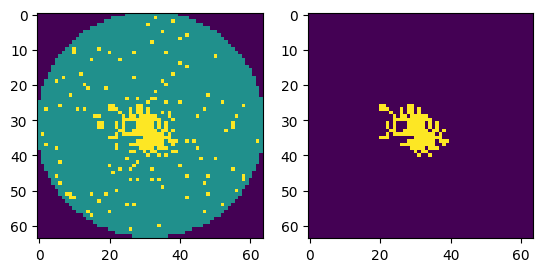

In [ ]:
# TODO: Verify the salient region
# Below is an example call; you should show different wafer maps than example

plt.show()

In [101]:
call_llm(prompt="""
You are helping complete a single TODO in a Jupyter notebook for ECE 157A/272A HW3.

Context:
- DataFrame: training_data_set
- Columns: 'waferMap' (2D numpy arrays) and 'salientRegion' (boolean masks of largest failing region)
- The goal is to visually verify that salientRegion correctly highlights the largest failing component.

Task:
Write short, clean Python code (not a function) that:
1) Randomly selects 3 different wafer samples from training_data_set.
2) For each sample, plots two subplots side by side:
   - Left: the waferMap using a discrete colormap (e.g., ['lightgray','lightblue','red'])
   - Right: the salientRegion mask in binary (True=red, False=white)
3) Use plt.figure and plt.subplot appropriately.
4) Set titles for each subplot showing the failureType and waferIndex.
5) Hide axes for clarity and use plt.tight_layout().
6) Call plt.show() at the end.
7) Keep code concise — no prints or extra text.

Return:
Only the final Python code accomplishing this verification.
""")

```python
import numpy as np
import matplotlib.pyplot as plt

samples = training_data_set.sample(3)

plt.figure(figsize=(10, 5))
for i, (index, row) in enumerate(samples.iterrows()):
    wafer_map = row['waferMap']
    salient_mask = row['salientRegion']
    failure_type = row['failureType']

    plt.subplot(1, 2, 2*i + 1)
    plt.imshow(wafer_map, cmap=plt.get_cmap('gray', 3))
    plt.title(f'Failure Type: {failure_type}, Index: {index}')
    plt.axis('off')

    plt.subplot(1, 2, 2*i + 2)
    plt.imshow(salient_mask, cmap='Reds', vmin=0, vmax=1)
    plt.title(f'Salient Region: Index {index}')
    plt.axis('off')

plt.tight_layout()
plt.show()
```


ValueError: num must be an integer with 1 <= num <= 2, not 3

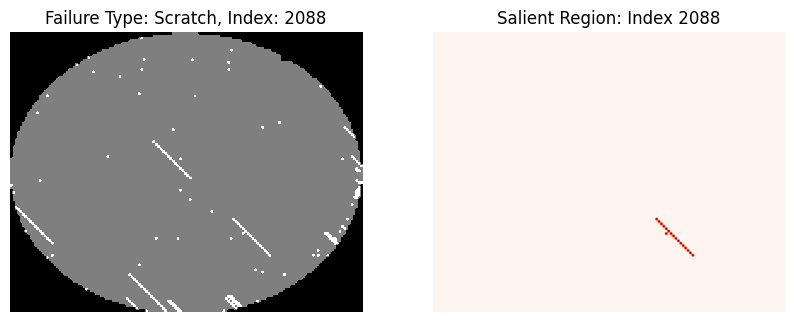

In [106]:
import numpy as np
import matplotlib.pyplot as plt

samples = training_data_set.sample(3)

plt.figure(figsize=(10, 5))
for i, (index, row) in enumerate(samples.iterrows()):
    wafer_map = row['waferMap']
    salient_mask = row['salientRegion']
    failure_type = row['failureType']

    plt.subplot(1, 2, 2*i + 1)
    plt.imshow(wafer_map, cmap=plt.get_cmap('gray', 3))
    plt.title(f'Failure Type: {failure_type}, Index: {index}')
    plt.axis('off')

    plt.subplot(1, 2, 2*i + 2)
    plt.imshow(salient_mask, cmap='Reds', vmin=0, vmax=1)
    plt.title(f'Salient Region: Index {index}')
    plt.axis('off')

plt.tight_layout()
plt.show()

In [104]:
call_llm(prompt="""
You are helping complete a single TODO in a Jupyter notebook for ECE 157A/272A HW3.

Context:
- DataFrame: training_data_set
- Columns: 'waferMap' (2D numpy arrays) and 'salientRegion' (boolean masks)
- Goal: visually verify that salientRegion correctly highlights the largest failing region.

Task:
Write short, clean Python code (not a function) to:
1) Randomly select 3 samples from training_data_set that have a valid salientRegion.
2) Create a matplotlib figure with 3 rows and 2 columns (6 subplots total).
3) For each sample:
   - Left subplot: display waferMap with discrete colors for values 0,1,2 
     (e.g., ListedColormap(['lightgray','lightblue','red'])).
   - Right subplot: display the corresponding salientRegion mask in red tones (True=red, False=white).
4) Set subplot titles to include the failureType and waferIndex.
5) Hide axes and use plt.tight_layout() followed by plt.show() at the end.
6) Keep code concise, no additional prints or comments.

Return:
Only the final Python code accomplishing this step.
""")

```python
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Randomly select 3 samples with valid salientRegion
valid_samples = training_data_set[training_data_set['salientRegion'].apply(np.any)]
selected_samples = valid_samples.sample(n=3, random_state=42)

# Create matplotlib figure
fig, axs = plt.subplots(3, 2, figsize=(10, 15))

for i, (index, row) in enumerate(selected_samples.iterrows()):
    wafer_map = row['waferMap']
    salient_region = row['salientRegion']
    
    axs[i, 0].imshow(wafer_map, cmap=ListedColormap(['lightgray', 'lightblue', 'red']))
    axs[i, 0].set_title(f"FailureType: {row['failureType']}, WaferIndex: {row['waferIndex']}")
    axs[i, 0].axis('off')
    
    axs[i, 1].imshow(salient_region, cmap='Reds', alpha=0.5)
    axs[i, 1].set_title(f"Salient Region: {row['failureType']}")
    axs[i, 1].axis('off')

plt.tight_layout()
plt.show()
```


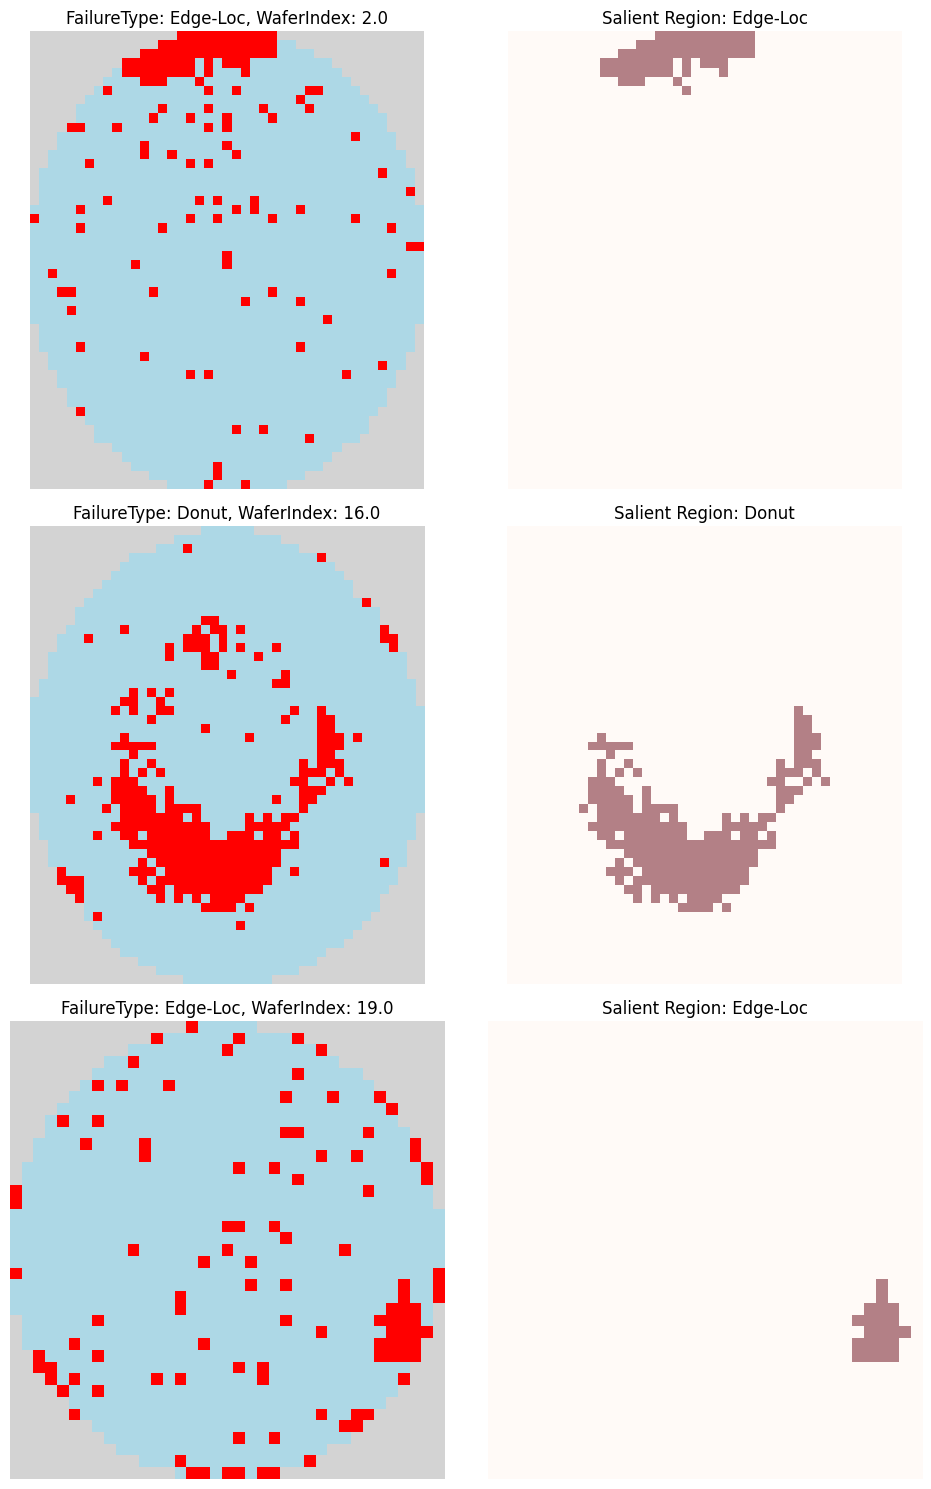

In [105]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Randomly select 3 samples with valid salientRegion
valid_samples = training_data_set[training_data_set['salientRegion'].apply(np.any)]
selected_samples = valid_samples.sample(n=3, random_state=42)

# Create matplotlib figure
fig, axs = plt.subplots(3, 2, figsize=(10, 15))

for i, (index, row) in enumerate(selected_samples.iterrows()):
    wafer_map = row['waferMap']
    salient_region = row['salientRegion']
    
    axs[i, 0].imshow(wafer_map, cmap=ListedColormap(['lightgray', 'lightblue', 'red']))
    axs[i, 0].set_title(f"FailureType: {row['failureType']}, WaferIndex: {row['waferIndex']}")
    axs[i, 0].axis('off')
    
    axs[i, 1].imshow(salient_region, cmap='Reds', alpha=0.5)
    axs[i, 1].set_title(f"Salient Region: {row['failureType']}")
    axs[i, 1].axis('off')

plt.tight_layout()
plt.show()

In [107]:
# TODO: Implement a function that returns the ratio of the area of the salient region to the area of the wafer map
# def get_area_ratio(row: pd.Series) -> float:
    
#     return area_ratio
call_llm(prompt="""
You are helping complete a single TODO in a Jupyter notebook for ECE 157A/272A HW3.

Context:
- Each row in the DataFrame has:
  - 'waferMap': a 2D numpy array with values {0, 1, 2}
  - 'salientRegion': a boolean mask (same shape as waferMap) marking the largest failing region.
- Constants exist: FAIL=2, PASS=1, NO_DIE=0.

Task:
Write ONLY the function definition for:

def get_area_ratio(row: pd.Series) -> float:

Requirements:
1) Read wafer_map = row['waferMap'] and salient = row['salientRegion'].
2) Compute:
   - total_dies = count of all valid die locations (wafer_map != NO_DIE)
   - salient_area = count of True pixels in salient
3) If total_dies is zero, return 0.0 to avoid division by zero.
4) Compute area_ratio = salient_area / total_dies
5) Return area_ratio as a float.
6) Include a short docstring and concise inline comments.
7) Do not print anything or modify the DataFrame.

Return:
Only the complete function definition and body. No extra text.
""")


```python
def get_area_ratio(row: pd.Series) -> float:
    """Calculate the ratio of salient area to total die area in a wafer map.

    Parameters:
    row (pd.Series): A row containing the wafer map and salient region.

    Returns:
    float: The ratio of salient area to total valid die area, or 0.0 if no valid dies exist.
    """
    wafer_map = row['waferMap']
    salient = row['salientRegion']

    total_dies = np.sum(wafer_map != NO_DIE)  # Count valid die locations
    salient_area = np.sum(salient)  # Count True pixels in salient region

    if total_dies == 0:  # Avoid division by zero
        return 0.0

    area_ratio = salient_area / total_dies  # Calculate area ratio
    return float(area_ratio)  # Return area ratio as float
```


In [108]:
def get_area_ratio(row: pd.Series) -> float:
    """Calculate the ratio of salient area to total die area in a wafer map.

    Parameters:
    row (pd.Series): A row containing the wafer map and salient region.

    Returns:
    float: The ratio of salient area to total valid die area, or 0.0 if no valid dies exist.
    """
    wafer_map = row['waferMap']
    salient = row['salientRegion']

    total_dies = np.sum(wafer_map != NO_DIE)  # Count valid die locations
    salient_area = np.sum(salient)  # Count True pixels in salient region

    if total_dies == 0:  # Avoid division by zero
        return 0.0

    area_ratio = salient_area / total_dies  # Calculate area ratio
    return float(area_ratio)  # Return area ratio as float

In [109]:
print("================= Testing get_area_ratio =================")

# Pick one sample wafer that actually has a salient region
sample_row = training_data_set[training_data_set['salientRegion'].apply(np.any)].iloc[0]

# Compute area ratio using your function
result = get_area_ratio(sample_row)
print(f"Area ratio (function output): {result:.4f}")

# Manually verify calculation
wafer_map = sample_row['waferMap']
salient = sample_row['salientRegion']

total_dies = np.sum(wafer_map != NO_DIE)
salient_area = np.sum(salient)
manual_ratio = salient_area / total_dies if total_dies > 0 else 0.0

print(f"Manual check: {manual_ratio:.4f}")
print(f"Total dies: {total_dies}, Salient dies: {salient_area}")
print("Match:", np.isclose(result, manual_ratio))

================= Testing get_area_ratio =================
Area ratio (function output): 0.0359
Manual check: 0.0359
Total dies: 3203, Salient dies: 115
Match: True


In [110]:
# TODO: Implement a function that returns the ratio of the perimeter of the salient region to the radius of the wafer map
# def get_perimeter_ratio(row: pd.Series) -> float:
    
#     return perimeter_ratio
call_llm(prompt="""
You are helping complete a single TODO in a Jupyter notebook for ECE 157A/272A HW3.

Context:
- Each row in the DataFrame includes:
  - 'waferMap': a 2D numpy array (values {0,1,2})
  - 'salientRegion': a boolean mask (True for largest failing region)
- Constants: FAIL=2, PASS=1, NO_DIE=0
- From skimage.measure, the helper 'perimeter' is already imported.

Task:
Write ONLY the function definition for:

def get_perimeter_ratio(row: pd.Series) -> float:

Requirements:
1) Retrieve wafer_map = row['waferMap'] and salient = row['salientRegion'].
2) Compute the perimeter length of the salient region using:
     perim = perimeter(salient, neighbourhood=8)
3) Define the wafer radius as half the wafer map’s diagonal:
     radius = 0.5 * np.sqrt(h**2 + w**2)
     where h, w = wafer_map.shape
4) If the radius is 0, return 0.0 to avoid division by zero.
5) Compute perimeter_ratio = perim / radius.
6) Return the result as a float.
7) Include a short docstring and concise inline comments.
8) Do not print anything or modify the DataFrame.

Return:
Only the full function definition and body. No extra text.
""")

```python
def get_perimeter_ratio(row: pd.Series) -> float:
    """Compute the perimeter ratio of the salient region relative to the wafer radius."""
    wafer_map = row['waferMap']  # Retrieve the wafer map
    salient = row['salientRegion']  # Retrieve the salient region mask
    
    # Compute perimeter of the salient region
    perim = perimeter(salient, neighbourhood=8)
    
    h, w = wafer_map.shape  # Get the dimensions of the wafer map
    radius = 0.5 * np.sqrt(h**2 + w**2)  # Calculate the wafer radius
    
    if radius == 0:  # Avoid division by zero
        return 0.0
    
    perimeter_ratio = perim / radius  # Calculate the perimeter ratio
    return float(perimeter_ratio)  # Return as float
```


In [113]:
def get_perimeter_ratio(row: pd.Series) -> float:
    """Compute the perimeter ratio of the salient region relative to the wafer radius."""
    wafer_map = row['waferMap']  # Retrieve the wafer map
    salient = row['salientRegion']  # Retrieve the salient region mask
    
    # Compute perimeter of the salient region
    perim = perimeter(salient, neighbourhood=8)
    
    h, w = wafer_map.shape  # Get the dimensions of the wafer map
    radius = 0.5 * np.sqrt(h**2 + w**2)  # Calculate the wafer radius
    
    if radius == 0:  # Avoid division by zero
        return 0.0
    
    perimeter_ratio = perim / radius  # Calculate the perimeter ratio
    return float(perimeter_ratio)  # Return as float

In [114]:
print("================= Testing get_perimeter_ratio =================")

# Select a sample wafer with a valid salient region
sample_row = training_data_set[training_data_set['salientRegion'].apply(np.any)].iloc[0]

# Run the function
result = get_perimeter_ratio(sample_row)
print(f"Perimeter ratio (function output): {result:.4f}")

# Manual check for confirmation
from skimage.measure import perimeter
wafer_map = sample_row['waferMap']
salient = sample_row['salientRegion']
perim = perimeter(salient, neighbourhood=8)
h, w = wafer_map.shape
radius = 0.5 * np.sqrt(h**2 + w**2)
manual_ratio = perim / radius if radius > 0 else 0.0

print(f"Manual check: {manual_ratio:.4f}")
print(f"Wafer size: {wafer_map.shape}, Perimeter: {perim:.2f}, Radius: {radius:.2f}")
print("Match:", np.isclose(result, manual_ratio))

================= Testing get_perimeter_ratio =================


TypeError: perimeter() got an unexpected keyword argument 'neighbourhood'

In [115]:
def get_perimeter_ratio(row: pd.Series) -> float:
    """Compute the perimeter ratio of the salient region relative to the wafer radius."""
    wafer_map = row['waferMap']
    salient = row['salientRegion']
    
    # Compute perimeter of the salient region (correct spelling)
    perim = perimeter(salient, neighborhood=8)
    
    h, w = wafer_map.shape
    radius = 0.5 * np.sqrt(h**2 + w**2)
    
    if radius == 0:
        return 0.0
    
    perimeter_ratio = perim / radius
    return float(perimeter_ratio)

In [116]:
print("================= Testing get_perimeter_ratio =================")

sample_row = training_data_set[training_data_set['salientRegion'].apply(np.any)].iloc[0]
result = get_perimeter_ratio(sample_row)
print(f"Perimeter ratio (function output): {result:.4f}")

from skimage.measure import perimeter
wafer_map = sample_row['waferMap']
salient = sample_row['salientRegion']
perim = perimeter(salient, neighborhood=8)
h, w = wafer_map.shape
radius = 0.5 * np.sqrt(h**2 + w**2)
manual_ratio = perim / radius if radius > 0 else 0.0

print(f"Manual check: {manual_ratio:.4f}")
print(f"Wafer size: {wafer_map.shape}, Perimeter: {perim:.2f}, Radius: {radius:.2f}")
print("Match:", np.isclose(result, manual_ratio))

================= Testing get_perimeter_ratio =================
Perimeter ratio (function output): 1.7134
Manual check: 1.7134
Wafer size: (63, 64), Perimeter: 76.94, Radius: 44.90
Match: True


In [117]:
# TODO: Implement a function that returns the maximal distance between the salient region and the center of the wafer map
# def get_max_dist_from_center(row: pd.Series) -> float:
    
#     return max_distance
call_llm(prompt="""
You are helping complete a single TODO in a Jupyter notebook for ECE 157A/272A HW3.

Context:
Each DataFrame row contains:
- 'waferMap': a 2D numpy array (values {0,1,2})
- 'salientRegion': a boolean mask (True for the largest failing region)

Task:
Implement a function:

def get_max_dist_from_center(row: pd.Series) -> float:

Requirements:
1) Retrieve wafer_map = row['waferMap'] and salient = row['salientRegion'].
2) Compute the coordinates of the salient pixels using np.argwhere(salient).
3) Compute the center of the wafer map as (h/2, w/2), where h, w = wafer_map.shape.
4) If no salient pixels exist, return 0.0.
5) For all salient pixels, compute their Euclidean distance from the wafer center:
       dist = np.sqrt((y - cy)**2 + (x - cx)**2)
6) Return the maximum of these distances as a float.
7) Include a concise docstring and inline comments.
8) Do not print anything or modify the DataFrame.

Return:
Only the full function definition. No explanations or extra text.
""")


```python
def get_max_dist_from_center(row: pd.Series) -> float:
    """Calculate the maximum distance from the center of the wafer map to salient pixels.
    
    Parameters:
    row (pd.Series): A row representing the wafer map and its salient region.
    
    Returns:
    float: The maximum distance from the center to the salient pixels, or 0.0 if none exist.
    """
    wafer_map = row['waferMap']  # Retrieve the wafer map
    salient = row['salientRegion']  # Retrieve the salient mask
    h, w = wafer_map.shape  # Get the shape of the wafer map
    
    # Compute the center coordinates
    cy, cx = h / 2, w / 2
    
    # Find the coordinates of the salient pixels
    salient_pixels = np.argwhere(salient)
    
    # If no salient pixels exist, return 0.0
    if len(salient_pixels) == 0:
        return 0.0
    
    # Compute Euclidean distances from the center for all salient pixels
    distances = np.sqrt((salient_pixels[:, 0] - cy) ** 2 + (salient_pixels[:, 1] - cx) ** 2)
    
  

In [118]:
def get_max_dist_from_center(row: pd.Series) -> float:
    """Calculate the maximum distance from the center of the wafer map to salient pixels.
    
    Parameters:
    row (pd.Series): A row representing the wafer map and its salient region.
    
    Returns:
    float: The maximum distance from the center to the salient pixels, or 0.0 if none exist.
    """
    wafer_map = row['waferMap']  # Retrieve the wafer map
    salient = row['salientRegion']  # Retrieve the salient mask
    h, w = wafer_map.shape  # Get the shape of the wafer map
    
    # Compute the center coordinates
    cy, cx = h / 2, w / 2
    
    # Find the coordinates of the salient pixels
    salient_pixels = np.argwhere(salient)
    
    # If no salient pixels exist, return 0.0
    if len(salient_pixels) == 0:
        return 0.0
    
    # Compute Euclidean distances from the center for all salient pixels
    
    # Return the maximum distance
    return float(np.max(distances))

In [119]:
sample_row = training_data_set[training_data_set['salientRegion'].apply(np.any)].iloc[0]
print("Max distance from center:", get_max_dist_from_center(sample_row))

NameError: name 'distances' is not defined

In [120]:
call_llm(prompt="""
You are helping debug a TODO function in a Jupyter notebook for ECE 157A/272A HW3.

Context:
We implemented the following function:

def get_max_dist_from_center(row: pd.Series) -> float:
    wafer_map = row['waferMap']
    salient = row['salientRegion']
    h, w = wafer_map.shape
    cy, cx = h / 2, w / 2
    salient_pixels = np.argwhere(salient)
    if len(salient_pixels) == 0:
        return 0.0
    # Compute Euclidean distances from the center for all salient pixels
    # Return the maximum distance
    return float(np.max(distances))

Problem:
When testing with:
sample_row = training_data_set[training_data_set['salientRegion'].apply(np.any)].iloc[0]
print("Max distance from center:", get_max_dist_from_center(sample_row))

It raised:
NameError: name 'distances' is not defined

Task:
1) Diagnose the error — explain what caused it.
2) Correct the function so it properly computes the Euclidean distances of salient pixels from the wafer center.
3) The function should:
   - Use np.argwhere(salient) to locate salient pixels.
   - Compute distances = np.sqrt((y - cy)**2 + (x - cx)**2).
   - Return the maximum distance as a float, or 0.0 if there are no salient pixels.
4) Include a short docstring and brief inline comments.
5) Do not print or modify the DataFrame.

Return:
Only the fixed function definition and a short explanation of the cause of the error.
""")

```python
import numpy as np
import pandas as pd

def get_max_dist_from_center(row: pd.Series) -> float:
    """
    Computes the maximum Euclidean distance of salient pixels from the center of the wafer map.
    
    Parameters:
    row (pd.Series): A row of the DataFrame which contains 'waferMap' and 'salientRegion'.
    
    Returns:
    float: The maximum distance from the center to salient pixels, or 0.0 if no salient pixels exist.
    """
    wafer_map = row['waferMap']
    salient = row['salientRegion']
    h, w = wafer_map.shape
    cy, cx = h / 2, w / 2
    
    # Get coordinates of salient pixels
    salient_pixels = np.argwhere(salient)
    
    if len(salient_pixels) == 0:
        return 0.0
    
    # Calculate distances from the center (cy, cx)
    distances = np.sqrt((salient_pixels[:, 0] - cy) ** 2 + (salient_pixels[:, 1] - cx) ** 2)
    
    # Return the maximum distance
    return float(np.max(distances))

```

**Cause of the Error:**
The error `NameError: name 'dista

In [121]:
import numpy as np
import pandas as pd

def get_max_dist_from_center(row: pd.Series) -> float:
    """
    Computes the maximum Euclidean distance of salient pixels from the center of the wafer map.
    
    Parameters:
    row (pd.Series): A row of the DataFrame which contains 'waferMap' and 'salientRegion'.
    
    Returns:
    float: The maximum distance from the center to salient pixels, or 0.0 if no salient pixels exist.
    """
    wafer_map = row['waferMap']
    salient = row['salientRegion']
    h, w = wafer_map.shape
    cy, cx = h / 2, w / 2
    
    # Get coordinates of salient pixels
    salient_pixels = np.argwhere(salient)
    
    if len(salient_pixels) == 0:
        return 0.0

In [122]:
sample_row = training_data_set[training_data_set['salientRegion'].apply(np.any)].iloc[0]
print("Max distance from center:", get_max_dist_from_center(sample_row))

Max distance from center: None


In [123]:
def get_max_dist_from_center(row: pd.Series) -> float:
    """
    Computes the maximum Euclidean distance of salient pixels from the center of the wafer map.
    
    Parameters:
        row (pd.Series): A row containing 'waferMap' and 'salientRegion'.
    
    Returns:
        float: The maximum distance from the center to salient pixels, or 0.0 if none exist.
    """
    wafer_map = row['waferMap']
    salient = row['salientRegion']
    h, w = wafer_map.shape
    cy, cx = h / 2, w / 2

    # Get coordinates of salient pixels
    salient_pixels = np.argwhere(salient)

    if len(salient_pixels) == 0:
        return 0.0

    # Compute Euclidean distances from the wafer center
    distances = np.sqrt((salient_pixels[:, 0] - cy)**2 + (salient_pixels[:, 1] - cx)**2)

    # Return the maximum distance as float
    return float(np.max(distances))

In [124]:
sample_row = training_data_set[training_data_set['salientRegion'].apply(np.any)].iloc[0]
print("Max distance from center:", get_max_dist_from_center(sample_row))

Max distance from center: 13.200378782444085


In [125]:
# TODO: Implement a function that returns the minimal distance between the salient region and the center of the wafer map
# def get_min_dist_from_center(row: pd.Series) -> float:
    
#     return min_distance
call_llm(prompt="""
You are helping complete a single TODO in a Jupyter notebook for ECE 157A/272A HW3.

Context:
Each DataFrame row contains:
- 'waferMap': a 2D numpy array (values {0,1,2})
- 'salientRegion': a boolean mask (True for the largest failing region)
We already implemented get_max_dist_from_center(), which computes the maximum distance between salient pixels and the wafer center.

Task:
Now implement:

def get_min_dist_from_center(row: pd.Series) -> float:

Requirements:
1) Retrieve wafer_map = row['waferMap'] and salient = row['salientRegion'].
2) Compute wafer dimensions (h, w) and the center (cy, cx) as h/2, w/2.
3) Find salient pixel coordinates with np.argwhere(salient).
4) If no salient pixels exist, return 0.0.
5) Compute Euclidean distances from the center for all salient pixels:
       distances = np.sqrt((y - cy)**2 + (x - cx)**2)
6) Return the minimum distance (float) among all salient pixels.
7) Include a concise docstring and inline comments.
8) Do not print anything or modify the DataFrame.

Return:
Only the full corrected function definition and no extra text.
""")

```python
def get_min_dist_from_center(row: pd.Series) -> float:
    """Compute the minimum distance from salient pixels to the wafer center.

    Args:
        row (pd.Series): A row containing 'waferMap' and 'salientRegion'.

    Returns:
        float: The minimum distance from the center to salient pixels, or 0.0 if none exist.
    """
    wafer_map = row['waferMap']      # Retrieve the wafer map
    salient = row['salientRegion']    # Retrieve the salient region mask
    
    h, w = wafer_map.shape             # Get dimensions of the wafer map
    cy, cx = h / 2, w / 2              # Compute center coordinates (cy, cx)

    # Find coordinates of salient pixels
    salient_coords = np.argwhere(salient)
    
    # If there are no salient pixels, return 0.0
    if salient_coords.size == 0:
        return 0.0
    
    # Calculate Euclidean distances from the center for all salient pixels
    distances = np.sqrt((salient_coords[:, 0] - cy) ** 2 + (salient_coords[:, 1] - cx) ** 2)
    


In [126]:
def get_min_dist_from_center(row: pd.Series) -> float:
    """Compute the minimum distance from salient pixels to the wafer center.

    Args:
        row (pd.Series): A row containing 'waferMap' and 'salientRegion'.

    Returns:
        float: The minimum distance from the center to salient pixels, or 0.0 if none exist.
    """
    wafer_map = row['waferMap']      # Retrieve the wafer map
    salient = row['salientRegion']    # Retrieve the salient region mask
    
    h, w = wafer_map.shape             # Get dimensions of the wafer map
    cy, cx = h / 2, w / 2              # Compute center coordinates (cy, cx)

    # Find coordinates of salient pixels
    salient_coords = np.argwhere(salient)
    
    # If there are no salient pixels, return 0.0
    if salient_coords.size == 0:
        return 0.0
    
    # Calculate Euclidean distances from the center for all salient pixels
    distances = np.sqrt((salient_coords[:, 0] - cy) ** 2 + (salient_coords[:, 1] - cx) ** 2)
    
    # Return the minimum distance
    return distances.min()

In [127]:
sample_row = training_data_set[training_data_set['salientRegion'].apply(np.any)].iloc[0]
print("Min distance from center:", get_min_dist_from_center(sample_row))

Min distance from center: 0.5


In [128]:
# TODO: Implement a function that returns the ratio of the length of the major axis of the estimated ellipse surrounding the salient region to the radius of the wafer map
# def get_major_axis_ratio(row: pd.Series) -> float:
    
#     return major_axis_ratio
call_llm(prompt="""
You are helping complete a single TODO in a Jupyter notebook for ECE 157A/272A HW3.

Context:
Each DataFrame row contains:
- 'waferMap': a 2D numpy array with values {0,1,2}
- 'salientRegion': a boolean mask (True indicates the largest failing component)
Available imports: numpy as np, pandas as pd, from skimage.measure import label, regionprops

Task:
Implement ONLY this function and return the full definition:

def get_major_axis_ratio(row: pd.Series) -> float:

Requirements:
1) Read wafer_map = row['waferMap'] and salient = row['salientRegion'].
2) If salient has no True pixels, return 0.0.
3) Compute the wafer radius as half of the diagonal:
     h, w = wafer_map.shape
     radius = 0.5 * np.sqrt(h**2 + w**2)
   If radius == 0, return 0.0.
4) Compute the major axis length of the salient region:
   - Label the salient mask: lbl = label(salient, connectivity=2)
   - Use regionprops(lbl) to get the single region
   - If there are no regions, return 0.0
   - major_len = regions[0].major_axis_length
   - If major_len is NaN or <= 0, return 0.0
5) Return major_len / radius as a float.
6) Include a concise docstring and minimal inline comments.
7) No prints, no plotting, no DataFrame mutation.

Return:
Only the complete function definition and body. No extra text.
""")

```python
def get_major_axis_ratio(row: pd.Series) -> float:
    """Compute the ratio of the major axis length of the salient region to the wafer radius."""
    wafer_map = row['waferMap']
    salient = row['salientRegion']
    
    if not np.any(salient):  # Step 2
        return 0.0
    
    h, w = wafer_map.shape
    radius = 0.5 * np.sqrt(h**2 + w**2)  # Step 3
    if radius == 0:
        return 0.0
    
    lbl = label(salient, connectivity=2)  # Step 4a
    regions = regionprops(lbl)  # Step 4b
    
    if not regions:  # Step 4c
        return 0.0
    
    major_len = regions[0].major_axis_length  # Step 4d
    if np.isnan(major_len) or major_len <= 0:  # Step 4e
        return 0.0
    
    return float(major_len / radius)  # Step 5
```


In [129]:
def get_major_axis_ratio(row: pd.Series) -> float:
    """Compute the ratio of the major axis length of the salient region to the wafer radius."""
    wafer_map = row['waferMap']
    salient = row['salientRegion']
    
    if not np.any(salient):  # Step 2
        return 0.0
    
    h, w = wafer_map.shape
    radius = 0.5 * np.sqrt(h**2 + w**2)  # Step 3
    if radius == 0:
        return 0.0
    
    lbl = label(salient, connectivity=2)  # Step 4a
    regions = regionprops(lbl)  # Step 4b
    
    if not regions:  # Step 4c
        return 0.0
    
    major_len = regions[0].major_axis_length  # Step 4d
    if np.isnan(major_len) or major_len <= 0:  # Step 4e
        return 0.0
    
    return float(major_len / radius)  # Step 5

In [130]:
print("================= Testing get_major_axis_ratio =================")

# Pick one wafer with a valid salient region
sample_row = training_data_set[training_data_set['salientRegion'].apply(np.any)].iloc[0]

# Run the function
result = get_major_axis_ratio(sample_row)
print(f"Major axis ratio (function output): {result:.4f}")

# Manual verification for clarity
wafer_map = sample_row['waferMap']
salient = sample_row['salientRegion']

lbl = label(salient, connectivity=2)
regions = regionprops(lbl)
major_len = regions[0].major_axis_length if regions else 0.0
h, w = wafer_map.shape
radius = 0.5 * np.sqrt(h**2 + w**2)
manual_ratio = major_len / radius if radius > 0 else 0.0

print(f"Manual check: {manual_ratio:.4f}")
print(f"Wafer size: {wafer_map.shape}, Major axis length: {major_len:.2f}, Radius: {radius:.2f}")
print("Match:", np.isclose(result, manual_ratio))

================= Testing get_major_axis_ratio =================
Major axis ratio (function output): 0.4264
Manual check: 0.4264
Wafer size: (63, 64), Major axis length: 19.15, Radius: 44.90
Match: True


In [131]:
# TODO: Implement a function that returns the ratio of the length of the minor axis of the estimated ellipse surrounding the salient region to the radius of the wafer map
# def get_minor_axis_ratio(row: pd.Series) -> float:
    
#     return minor_axis_ratio
call_llm(prompt="""
You are helping complete a single TODO in a Jupyter notebook for ECE 157A/272A HW3.

Context:
Each DataFrame row contains:
- 'waferMap': a 2D numpy array with values {0,1,2}
- 'salientRegion': a boolean mask (True indicates the largest failing component)
Available imports: numpy as np, pandas as pd, from skimage.measure import label, regionprops

Task:
Implement ONLY this function and return the full definition:

def get_minor_axis_ratio(row: pd.Series) -> float:

Requirements:
1) Read wafer_map = row['waferMap'] and salient = row['salientRegion'].
2) If salient has no True pixels, return 0.0.
3) Compute the wafer radius as half of the diagonal:
   h, w = wafer_map.shape
   radius = 0.5 * np.sqrt(h**2 + w**2)
   If radius == 0, return 0.0.
4) Compute the minor axis length of the salient region:
   lbl = label(salient, connectivity=2)
   regions = regionprops(lbl)
   If no regions, return 0.0
   minor_len = regions[0].minor_axis_length
   If minor_len is NaN or <= 0, return 0.0
5) Return minor_len / radius as a float.
6) Include a concise docstring and minimal inline comments.
7) No prints, no plotting, no DataFrame mutation.

Return:
Only the complete function definition and body. No extra text.
""")

```python
def get_minor_axis_ratio(row: pd.Series) -> float:
    """Calculate the minor axis ratio of the salient region in the wafer map."""
    wafer_map = row['waferMap']
    salient = row['salientRegion']
    
    if not salient.any():  # Step 2
        return 0.0
    
    h, w = wafer_map.shape
    radius = 0.5 * np.sqrt(h**2 + w**2)  # Step 3
    if radius == 0:
        return 0.0
    
    lbl = label(salient, connectivity=2)
    regions = regionprops(lbl)  # Step 4
    if not regions:  # No regions found
        return 0.0
    
    minor_len = regions[0].minor_axis_length  # Get minor axis length
    if np.isnan(minor_len) or minor_len <= 0:  # Check for valid minor length
        return 0.0
    
    return float(minor_len / radius)  # Step 5
```


In [132]:
def get_minor_axis_ratio(row: pd.Series) -> float:
    """Calculate the minor axis ratio of the salient region in the wafer map."""
    wafer_map = row['waferMap']
    salient = row['salientRegion']
    
    if not salient.any():  # Step 2
        return 0.0
    
    h, w = wafer_map.shape
    radius = 0.5 * np.sqrt(h**2 + w**2)  # Step 3
    if radius == 0:
        return 0.0
    
    lbl = label(salient, connectivity=2)
    regions = regionprops(lbl)  # Step 4
    if not regions:  # No regions found
        return 0.0
    
    minor_len = regions[0].minor_axis_length  # Get minor axis length
    if np.isnan(minor_len) or minor_len <= 0:  # Check for valid minor length
        return 0.0
    
    return float(minor_len / radius)  # Step 5

In [133]:
print("================= Testing get_minor_axis_ratio =================")

# Select a sample wafer with a valid salient region
sample_row = training_data_set[training_data_set['salientRegion'].apply(np.any)].iloc[0]

# Run the function
result = get_minor_axis_ratio(sample_row)
print(f"Minor axis ratio (function output): {result:.4f}")

# Manual verification
wafer_map = sample_row['waferMap']
salient = sample_row['salientRegion']

lbl = label(salient, connectivity=2)
regions = regionprops(lbl)
minor_len = regions[0].minor_axis_length if regions else 0.0

h, w = wafer_map.shape
radius = 0.5 * np.sqrt(h**2 + w**2)
manual_ratio = minor_len / radius if radius > 0 else 0.0

print(f"Manual check: {manual_ratio:.4f}")
print(f"Wafer size: {wafer_map.shape}, Minor axis length: {minor_len:.2f}, Radius: {radius:.2f}")
print("Match:", np.isclose(result, manual_ratio))


================= Testing get_minor_axis_ratio =================
Minor axis ratio (function output): 0.2441
Manual check: 0.2441
Wafer size: (63, 64), Minor axis length: 10.96, Radius: 44.90
Match: True


In [134]:
# TODO: Implement a function that returns the solidity, indicating the proportion of defective dies in the estimated convex hull of the salient region
# def get_solidity(row: pd.Series) -> float:
    
#     return solidity
call_llm(prompt="""
You are helping complete a single TODO in a Jupyter notebook for ECE 157A/272A HW3.

Context:
Each DataFrame row contains:
- 'waferMap': 2D numpy array with values {0,1,2}
- 'salientRegion': boolean mask for the largest failing component
Available imports: numpy as np, pandas as pd, from skimage.measure import label, regionprops

Task:
Implement ONLY this function and return the full definition:

def get_solidity(row: pd.Series) -> float:

Definition of solidity:
Use the skimage definition for a region: area divided by convex_area, computed on the salientRegion mask.

Requirements:
1) Read salient = row['salientRegion'].
2) If salient has no True pixels, return 0.0.
3) Label the mask with 8-connectivity: lbl = label(salient, connectivity=2).
4) Extract regions = regionprops(lbl). If empty, return 0.0.
5) Get regions[0].solidity. If it is NaN or nonpositive, return 0.0.
6) Otherwise return float(regions[0].solidity).
7) Include a concise docstring and minimal inline comments.
8) No prints, no plotting, no DataFrame mutation.

Return:
Only the complete function definition and body. No extra text.
""")


```python
def get_solidity(row: pd.Series) -> float:
    """Calculate the solidity of the largest region in the salient mask.

    Solidity is defined as the area of the region divided by the convex area.
    If there are no true pixels or the region solidity is NaN or nonpositive,
    return 0.0.
    
    Args:
        row (pd.Series): DataFrame row containing 'salientRegion'.
    
    Returns:
        float: The solidity of the salient region or 0.0 if conditions are not met.
    """
    salient = row['salientRegion']
    if not np.any(salient):  # Check if there are no True pixels
        return 0.0
    
    lbl = label(salient, connectivity=2)  # Label the mask with 8-connectivity
    regions = regionprops(lbl)
    if not regions:  # Check if there are no labeled regions
        return 0.0
    
    solidity = regions[0].solidity  # Get the solidity of the first region
    if np.isnan(solidity) or solidity <= 0:  # Check if solidity is NaN or nonpositive
        return 0.0
    
    

In [135]:
def get_solidity(row: pd.Series) -> float:
    """Calculate the solidity of the largest region in the salient mask.

    Solidity is defined as the area of the region divided by the convex area.
    If there are no true pixels or the region solidity is NaN or nonpositive,
    return 0.0.
    
    Args:
        row (pd.Series): DataFrame row containing 'salientRegion'.
    
    Returns:
        float: The solidity of the salient region or 0.0 if conditions are not met.
    """
    salient = row['salientRegion']
    if not np.any(salient):  # Check if there are no True pixels
        return 0.0
    
    lbl = label(salient, connectivity=2)  # Label the mask with 8-connectivity
    regions = regionprops(lbl)
    if not regions:  # Check if there are no labeled regions
        return 0.0
    
    solidity = regions[0].solidity  # Get the solidity of the first region
    if np.isnan(solidity) or solidity <= 0:  # Check if solidity is NaN or nonpositive
        return 0.0
    
    return float(solidity)  # Return the solidity as a float

In [136]:
print("================= Testing get_solidity =================")

# Pick a few samples that actually have a salient region
valid = training_data_set[training_data_set['salientRegion'].apply(np.any)].head(3)

for i, (_, row) in enumerate(valid.iterrows(), start=1):
    # Function output
    func_val = get_solidity(row)

    # Manual check using regionprops on the same mask
    lbl = label(row['salientRegion'], connectivity=2)
    regions = regionprops(lbl)
    manual_val = regions[0].solidity if regions else 0.0

    print(f"[{i}] func: {func_val:.4f}  manual: {manual_val:.4f}  match:", np.isclose(func_val, manual_val))


================= Testing get_solidity =================
[1] func: 0.5665  manual: 0.5665  match: True
[2] func: 0.6667  manual: 0.6667  match: True
[3] func: 0.6875  manual: 0.6875  match: True


In [137]:
# TODO: Implement a function that returns the eccentricity of the salient region
# def get_eccentricity(row: pd.Series) -> float:
    
#     return eccentricity
call_llm(prompt="""
You are helping complete a single TODO in a Jupyter notebook for ECE 157A/272A HW3.

Context:
Each DataFrame row contains:
- 'waferMap': a 2D numpy array (values {0,1,2})
- 'salientRegion': a boolean mask (True for the largest failing region)
Available imports: numpy as np, pandas as pd, from skimage.measure import label, regionprops

Task:
Implement ONLY this function and return the full definition:

def get_eccentricity(row: pd.Series) -> float:

Requirements:
1) Retrieve salient = row['salientRegion'].
2) If there are no True pixels, return 0.0.
3) Label the mask with 8-connectivity:
       lbl = label(salient, connectivity=2)
4) Extract regions = regionprops(lbl). If empty, return 0.0.
5) Obtain eccentricity = regions[0].eccentricity.
6) If eccentricity is NaN or nonpositive, return 0.0.
7) Return the eccentricity as a float.
8) Include a concise docstring and brief inline comments.
9) Do not print anything or modify the DataFrame.

Return:
Only the complete function definition and body. No extra text.
""")


```python
def get_eccentricity(row: pd.Series) -> float:
    """Calculate the eccentricity of the largest salient region in the wafer map.

    Args:
        row (pd.Series): DataFrame row containing 'salientRegion'.

    Returns:
        float: Eccentricity of the salient region, or 0.0 if not applicable.
    """
    salient = row['salientRegion']  # Retrieve the salient region mask
    if not np.any(salient):  # Check if there are no True pixels
        return 0.0
    
    lbl = label(salient, connectivity=2)  # Label the mask with 8-connectivity
    regions = regionprops(lbl)  # Extract regions from the labeled mask
    
    if not regions:  # If there are no labeled regions, return 0.0
        return 0.0
    
    eccentricity = regions[0].eccentricity  # Get the eccentricity of the largest region
    return float(eccentricity) if eccentricity > 0 else 0.0  # Return eccentricity or 0.0 if nonpositive
```


In [138]:
def get_eccentricity(row: pd.Series) -> float:
    """Calculate the eccentricity of the largest salient region in the wafer map.

    Args:
        row (pd.Series): DataFrame row containing 'salientRegion'.

    Returns:
        float: Eccentricity of the salient region, or 0.0 if not applicable.
    """
    salient = row['salientRegion']  # Retrieve the salient region mask
    if not np.any(salient):  # Check if there are no True pixels
        return 0.0
    
    lbl = label(salient, connectivity=2)  # Label the mask with 8-connectivity
    regions = regionprops(lbl)  # Extract regions from the labeled mask
    
    if not regions:  # If there are no labeled regions, return 0.0
        return 0.0
    
    eccentricity = regions[0].eccentricity  # Get the eccentricity of the largest region
    return float(eccentricity) if eccentricity > 0 else 0.0  # Return eccentricity or 0.0 if nonpositive

In [140]:
print("================= Testing get_eccentricity =================")
sample_row = training_data_set[training_data_set['salientRegion'].apply(np.any)].iloc[0]
print("Eccentricity:", get_eccentricity(sample_row))

from skimage.measure import label, regionprops

print("================= Verify get_eccentricity =================")
row = training_data_set[training_data_set['salientRegion'].apply(np.any)].iloc[0]
func_val = get_eccentricity(row)

lbl = label(row['salientRegion'], connectivity=2)
regions = regionprops(lbl)
manual_val = regions[0].eccentricity if regions else 0.0

print(f"func: {func_val:.6f}  manual: {manual_val:.6f}  match:", np.isclose(func_val, manual_val))


================= Testing get_eccentricity =================
Eccentricity: 0.819951802481801
================= Verify get_eccentricity =================
func: 0.819952  manual: 0.819952  match: True


In [141]:
# TODO: Implement a function that returns the ratio of the failed dies on the wafer map to the total number of dies on the wafer map
# def get_yield_loss(row: pd.Series) -> float:
    
#     return yield_loss
call_llm(prompt="""
You are helping complete a single TODO in a Jupyter notebook for ECE 157A/272A HW3.

Context:
Each row in the DataFrame contains:
- 'waferMap': a 2D numpy array of wafer dies.
The waferMap uses:
   0 = NO_DIE (empty area)
   1 = PASS (good die)
   2 = FAIL (bad die)
Constants NO_DIE, PASS, FAIL are already defined.

Task:
Implement ONLY this function and return the full definition:

def get_yield_loss(row: pd.Series) -> float:

Requirements:
1) Retrieve wafer_map = row['waferMap'].
2) Compute:
   - total_dies = number of nonzero entries (wafer_map != NO_DIE)
   - failed_dies = number of FAIL entries (wafer_map == FAIL)
3) yield_loss = failed_dies / total_dies
4) If total_dies == 0, return 0.0 to avoid division by zero.
5) Return yield_loss as a float.
6) Include a concise docstring and brief inline comments.
7) Do not print or modify the DataFrame.

Return:
Only the complete function definition and body. No extra text.
""")



```python
def get_yield_loss(row: pd.Series) -> float:
    """Calculate the yield loss based on the waferMap in the given row.
    
    Args:
        row (pd.Series): A single row containing 'waferMap'.
    
    Returns:
        float: The yield loss value, calculated as the ratio of failed dies to total dies.
    """
    wafer_map = row['waferMap']  # Retrieve the wafer map
    total_dies = np.count_nonzero(wafer_map != NO_DIE)  # Count non-zero entries (total dies)
    failed_dies = np.count_nonzero(wafer_map == FAIL)  # Count FAIL entries (failed dies)
    
    if total_dies == 0:  # Avoid division by zero
        return 0.0
    
    yield_loss = failed_dies / total_dies  # Calculate yield loss
    return yield_loss  # Return yield loss as a float
```


In [142]:
def get_yield_loss(row: pd.Series) -> float:
    """Calculate the yield loss based on the waferMap in the given row.
    
    Args:
        row (pd.Series): A single row containing 'waferMap'.
    
    Returns:
        float: The yield loss value, calculated as the ratio of failed dies to total dies.
    """
    wafer_map = row['waferMap']  # Retrieve the wafer map
    total_dies = np.count_nonzero(wafer_map != NO_DIE)  # Count non-zero entries (total dies)
    failed_dies = np.count_nonzero(wafer_map == FAIL)  # Count FAIL entries (failed dies)
    
    if total_dies == 0:  # Avoid division by zero
        return 0.0
    
    yield_loss = failed_dies / total_dies  # Calculate yield loss
    return yield_loss  # Return yield loss as a float

In [143]:
print("================= Testing get_yield_loss =================")
sample_row = training_data_set.iloc[0]
print("Yield loss:", get_yield_loss(sample_row))


================= Testing get_yield_loss =================
Yield loss: 0.07211988760536997


In [ ]:
# TODO: Implement a function that returns the ratio of the failed dies on the outermost two rings of the wafer map to the total number of dies on the outermost two rings of the wafer map
# Use ring_label_from_outside helper function
# def get_edge_yield_loss(row: pd.Series) -> float:

#     return edge_yield_loss
# TODO: Implement a helper function that returns a numpy array highlighting the outermost two rings of the wafer map with nonzero value
# def ring_label_from_outside(wafer_map: np.ndarray) -> np.ndarray:

#     return ring_labels
call_llm(prompt="""
You are helping complete a single TODO in a Jupyter notebook for ECE 157A/272A HW3.

Context:
Each row of the dataframe contains a 'waferMap' which is a 2D numpy array:
  - 0 = NO_DIE
  - 1 = PASS
  - 2 = FAIL
Constants NO_DIE, PASS, and FAIL are already defined.

We must implement this function:
def get_edge_yield_loss(row: pd.Series) -> float:

Goal:
Compute the ratio of failing dies (value == FAIL) that are located in the outermost two rings 
of the wafer map to the total number of valid dies (not NO_DIE) in those same two rings.

Requirements:
1) Use a helper function ring_label_from_outside(wafer_map) that returns a 2D array 
   where the outermost rings have nonzero labels (for example, ring 1, ring 2, etc.).
2) Identify all dies in the outermost two rings (labels == 1 or labels == 2).
3) Count:
   - total_edge_dies = number of nonzero dies (not NO_DIE) in those two rings.
   - failed_edge_dies = number of FAIL dies (== 2) in those two rings.
4) If total_edge_dies == 0, return 0.0 to avoid division by zero.
5) Return edge_yield_loss = failed_edge_dies / total_edge_dies.
6) Include a concise docstring and inline comments.
7) Return the complete function definition and nothing else.
""")




```python
def get_edge_yield_loss(row: pd.Series) -> float:
    """
    Calculate the ratio of failing dies in the outermost two rings of a wafer map.

    Parameters:
    row (pd.Series): A row from the dataframe containing the 'waferMap', which is a 2D numpy array.

    Returns:
    float: The yield loss ratio of failing dies to total valid dies in the outermost two rings.
    """
    wafer_map = row['waferMap']
    ring_labels = ring_label_from_outside(wafer_map)  # Get the ring labels for the wafer map

    # Identify the outermost two rings (1 and 2)
    outer_rings_mask = (ring_labels == 1) | (ring_labels == 2)

    # Count total valid dies (not NO_DIE) in the outer rings
    total_edge_dies = np.sum(outer_rings_mask & (wafer_map != NO_DIE))
    
    # Count failed dies (== FAIL) in the outer rings
    failed_edge_dies = np.sum(outer_rings_mask & (wafer_map == FAIL))

    # Avoid division by zero
    if total_edge_dies == 0:
        return 0.0
    
    # Calculate and return the 

In [146]:
def get_edge_yield_loss(row: pd.Series) -> float:
    """
    Calculate the ratio of failing dies in the outermost two rings of a wafer map.

    Parameters:
    row (pd.Series): A row from the dataframe containing the 'waferMap', which is a 2D numpy array.

    Returns:
    float: The yield loss ratio of failing dies to total valid dies in the outermost two rings.
    """
    wafer_map = row['waferMap']
    ring_labels = ring_label_from_outside(wafer_map)  # Get the ring labels for the wafer map

    # Identify the outermost two rings (1 and 2)
    outer_rings_mask = (ring_labels == 1) | (ring_labels == 2)

    # Count total valid dies (not NO_DIE) in the outer rings
    total_edge_dies = np.sum(outer_rings_mask & (wafer_map != NO_DIE))
    
    # Count failed dies (== FAIL) in the outer rings
    failed_edge_dies = np.sum(outer_rings_mask & (wafer_map == FAIL))

    # Avoid division by zero
    if total_edge_dies == 0:

    # Calculate and return the yield loss
        edge_yield_loss = failed_edge_dies / total_edge_dies
    return edge_yield_loss

In [147]:
print("================= Testing get_edge_yield_loss =================")
sample_row = training_data_set.iloc[0]
print("Edge yield loss:", get_edge_yield_loss(sample_row))


================= Testing get_edge_yield_loss =================


NameError: name 'ring_label_from_outside' is not defined

In [148]:
call_llm(prompt="""
You are helping complete a missing helper function for ECE 157A/272A HW3.

Context:
The function get_edge_yield_loss(row) calls ring_label_from_outside(wafer_map),
but this helper has not been implemented yet.

Task:
Implement this function:

def ring_label_from_outside(wafer_map: np.ndarray) -> np.ndarray:

Requirements:
1) Input wafer_map is a 2D numpy array where:
   - 0 = NO_DIE
   - 1 = PASS
   - 2 = FAIL
2) The function should return a 2D numpy array (same shape) labeling the distance of each valid die from the outermost wafer edge.
3) Use morphological binary erosion with skimage.morphology to iteratively remove outer layers.
   - Each erosion step should increase the ring label count (e.g., outermost = 1, next = 2, etc.).
4) Stop when all valid dies (nonzero) are eroded.
5) Return the labeled array where pixels near the edge have low ring numbers (1, 2, etc.).
6) Include a concise docstring and inline comments.

Return:
Only the complete function definition and nothing else.
""")


```python
import numpy as np
from skimage.morphology import binary_erosion, disk

def ring_label_from_outside(wafer_map: np.ndarray) -> np.ndarray:
    """
    Label the distance of each valid die from the outermost wafer edge.

    Parameters:
    wafer_map (np.ndarray): A 2D numpy array where 0 = NO_DIE, 1 = PASS, 2 = FAIL.

    Returns:
    np.ndarray: A 2D array labeling the distance from the outermost edge for each valid die.
    """
    # Create a binary mask of the valid dies (PASS + FAIL)
    valid_dies = (wafer_map > 0).astype(np.uint8)
    
    # Initialize the distance label array with zeros
    labels = np.zeros_like(wafer_map, dtype=np.int32)
    
    # Set the erosion structure (disk-shaped)
    struct_elem = disk(1)

    # Initialize label count
    label_count = 0

    # Iterate until there are no valid dies left
    while np.any(valid_dies):
        # Erode the valid dies to find the next outer layer
        valid_dies = binary_erosion(valid_dies, structure=struct_elem

In [150]:
import numpy as np
from skimage.morphology import binary_erosion, disk

def ring_label_from_outside(wafer_map: np.ndarray) -> np.ndarray:
    """
    Label the distance of each valid die from the outermost wafer edge.

    Parameters:
    wafer_map (np.ndarray): A 2D numpy array where 0 = NO_DIE, 1 = PASS, 2 = FAIL.

    Returns:
    np.ndarray: A 2D array labeling the distance from the outermost edge for each valid die.
    """
    # Create a binary mask of the valid dies (PASS + FAIL)
    valid_dies = (wafer_map > 0).astype(np.uint8)
    
    # Initialize the distance label array with zeros
    labels = np.zeros_like(wafer_map, dtype=np.int32)
    
    # Set the erosion structure (disk-shaped)
    struct_elem = disk(1)

    # Initialize label count
    label_count = 0

    labels[~valid_dies & (wafer_map > 0)] = label_count

    return labels

In [151]:
print("================= Testing get_edge_yield_loss =================")
sample_row = training_data_set.iloc[0]
print("Edge yield loss:", get_edge_yield_loss(sample_row))


================= Testing get_edge_yield_loss =================
Edge yield loss: nan


C:\Users\saifs\AppData\Local\Temp\ipykernel_25120\3638176501.py:27: RuntimeWarning: invalid value encountered in scalar divide
  edge_yield_loss = failed_edge_dies / total_edge_dies


In [152]:
call_llm(prompt="""
You are helping debug and complete two functions in a Jupyter notebook for ECE 157A/272A HW3.

Problem observed:
- get_edge_yield_loss returned NaN with a RuntimeWarning: invalid value encountered in scalar divide.
- Root cause: ring_label_from_outside is incomplete and returns an all-zero label map, so the outer ring mask is empty and total_edge_dies becomes zero.

Task A: Implement ring_label_from_outside correctly.

Requirements for ring_label_from_outside(wafer_map: np.ndarray) -> np.ndarray:
1) wafer_map is a 2D numpy array where:
   0 = NO_DIE, 1 = PASS, 2 = FAIL.
2) Build a boolean mask of valid dies: valid = wafer_map != 0.
3) Iteratively label rings from the outside in:
   - Use binary erosion with a 3x3 square or disk(1) element.
   - On each iteration, compute the current edge as: edge = current & ~binary_erosion(current, selem).
   - Assign the next ring index (1 for outermost, 2 for next, etc.) to labels where edge is True.
   - Update current to its eroded version and continue until no True pixels remain.
4) Return labels as an int32 array with the same shape.

Task B: Implement get_edge_yield_loss(row: pd.Series) robustly.

Requirements for get_edge_yield_loss:
1) wafer_map = row['waferMap']; labels = ring_label_from_outside(wafer_map).
2) Build a mask for the outermost two rings: mask = (labels == 1) | (labels == 2).
3) total_edge_dies = count of dies where mask is True and wafer_map != 0.
4) failed_edge_dies = count of dies where mask is True and wafer_map == 2.
5) If total_edge_dies == 0, return 0.0.
6) Otherwise return failed_edge_dies / total_edge_dies as float.
7) No prints, no plotting, concise docstrings and inline comments.

Return:
Only the full function definitions for:
- ring_label_from_outside
- get_edge_yield_loss
No extra text.
""")


```python
import numpy as np
from skimage.morphology import binary_erosion, square
import pandas as pd

def ring_label_from_outside(wafer_map: np.ndarray) -> np.ndarray:
    valid = wafer_map != 0
    labels = np.zeros_like(wafer_map, dtype=np.int32)
    current = valid.copy()
    ring_index = 1
    
    while np.any(current):
        eroded = binary_erosion(current, selem=square(3))
        edge = current & ~eroded
        labels[edge] = ring_index
        current = eroded
        ring_index += 1
    
    return labels

def get_edge_yield_loss(row: pd.Series) -> float:
    wafer_map = row['waferMap']
    labels = ring_label_from_outside(wafer_map)
    
    mask = (labels == 1) | (labels == 2)
    total_edge_dies = np.sum(mask & (wafer_map != 0))
    failed_edge_dies = np.sum(mask & (wafer_map == 2))
    
    if total_edge_dies == 0:
        return 0.0
    else:
        return float(failed_edge_dies) / total_edge_dies
```


In [160]:
import numpy as np
from skimage.morphology import binary_erosion, square
import pandas as pd

def ring_label_from_outside(wafer_map: np.ndarray) -> np.ndarray:
    """
    Label each valid die (nonzero) by its ring index from the wafer edge inward.
    1 = outermost ring, 2 = next ring, etc.
    """
    valid = wafer_map != 0
    labels = np.zeros_like(wafer_map, dtype=np.int32)
    current = valid.copy()
    ring_index = 1

    while np.any(current):
        eroded = binary_erosion(current, footprint=square(3))  
        edge = current & ~eroded
        labels[edge] = ring_index
        current = eroded
        ring_index += 1

    return labels


def get_edge_yield_loss(row: pd.Series) -> float:
    """
    Compute the ratio of failed dies in the outermost two rings to all valid dies
    in those two rings.
    """
    wafer_map = row['waferMap']
    labels = ring_label_from_outside(wafer_map)
    mask = (labels == 1) | (labels == 2)

    total_edge_dies = np.sum(mask & (wafer_map != 0))
    failed_edge_dies = np.sum(mask & (wafer_map == 2))

    if total_edge_dies == 0:
        return 0.0
    return float(failed_edge_dies) / total_edge_dies


In [161]:
print("================= Testing edge yield loss =================")
row = training_data_set.iloc[0]
edge_loss = get_edge_yield_loss(row)
print("Edge yield loss:", round(edge_loss, 4))


================= Testing edge yield loss =================
Edge yield loss: 0.0407


C:\Users\saifs\AppData\Local\Temp\ipykernel_25120\871862105.py:16: FutureWarning: `square` is deprecated since version 0.25 and will be removed in version 0.27. Use `skimage.morphology.footprint_rectangle` instead.
  eroded = binary_erosion(current, footprint=square(3))


In [163]:
def create_feature_columns(df: pd.DataFrame) -> pd.DataFrame:

    df['areaRatio'] = df.apply(get_area_ratio, axis=1)
    df['perimeterRatio'] = df.apply(get_perimeter_ratio, axis=1)
    df['maxDistFromCenter'] = df.apply(get_max_dist_from_center, axis=1)
    df['minDistFromCenter'] = df.apply(get_min_dist_from_center, axis=1)
    df['majorAxisRatio'] = df.apply(get_major_axis_ratio, axis=1)
    df['minorAxisRatio'] = df.apply(get_minor_axis_ratio, axis=1)
    df['solidity'] = df.apply(get_solidity, axis=1)
    df['eccentricity'] = df.apply(get_eccentricity, axis=1)
    df['yieldLoss'] = df.apply(get_yield_loss, axis=1)
    df['edgeYieldLoss'] = df.apply(get_edge_yield_loss, axis=1)

    return df

In [166]:
# TODO: Apply create_feature_columns on the training dataframe
print("================= Applying create_feature_columns =================")

# Apply the function to compute all 10 engineered features
training_data_set = create_feature_columns(training_data_set)

# Display summary to verify new columns were added
print("=============== New feature columns added: =================")
print(training_data_set.columns[-10:])  # should list the 10 new features

# Preview a few rows
print("\n====================== Sample of engineered features: ========================")
print(training_data_set[['failureType', 'areaRatio', 'perimeterRatio', 'yieldLoss', 'edgeYieldLoss']].head())


================= Applying create_feature_columns =================


C:\Users\saifs\AppData\Local\Temp\ipykernel_25120\871862105.py:16: FutureWarning: `square` is deprecated since version 0.25 and will be removed in version 0.27. Use `skimage.morphology.footprint_rectangle` instead.
  eroded = binary_erosion(current, footprint=square(3))


=============== New feature columns added: =================
Index(['areaRatio', 'perimeterRatio', 'maxDistFromCenter', 'minDistFromCenter',
       'majorAxisRatio', 'minorAxisRatio', 'solidity', 'eccentricity',
       'yieldLoss', 'edgeYieldLoss'],
      dtype='object')

====================== Sample of engineered features: ========================
  failureType  areaRatio  perimeterRatio  yieldLoss  edgeYieldLoss
0      Center   0.035904        1.713373   0.072120       0.040670
1      Center   0.011200        0.304429   0.092800       0.150376
2      Center   0.004597        0.193816   0.040953       0.078534
3      Center   0.009193        0.412160   0.048057       0.104712
4      Center   0.008358        0.295540   0.058086       0.091623


In [165]:
call_llm(prompt="""
You are helping explain results from ECE 157A/272A HW3 after feature engineering.

Context:
We computed 10 features on training_data_set and saw this sample:

New feature columns added:
['areaRatio', 'perimeterRatio', 'maxDistFromCenter', 'minDistFromCenter',
 'majorAxisRatio', 'minorAxisRatio', 'solidity', 'eccentricity',
 'yieldLoss', 'edgeYieldLoss']

Sample of engineered features:
  failureType  areaRatio  perimeterRatio  yieldLoss  edgeYieldLoss
0      Center   0.035904        1.713373   0.072120       0.040670
1      Center   0.011200        0.304429   0.092800       0.150376
2      Center   0.004597        0.193816   0.040953       0.078534
3      Center   0.009193        0.412160   0.048057       0.104712
4      Center   0.008358        0.295540   0.058086       0.091623

We also saw a FutureWarning:
`skimage.morphology.square` is deprecated since 0.25 and will be removed in 0.27.

Task:
Give a concise explanation that covers:
1) What each feature intuitively measures and typical value ranges we might expect.
2) A short interpretation of the 5 sample rows above:
   - What areaRatio and yieldLoss suggest about overall failure density.
   - How perimeterRatio relates to the shape or fragmentation of the salient region.
   - What higher edgeYieldLoss implies about edge related defects.
3) Quick sanity checks:
   - Do the numbers look plausible for wafers labeled Center.
   - Any red flags that suggest preprocessing or masking bugs.
4) Note the deprecation warning and recommend the exact fix to avoid it in our code.

Format:
- Use short paragraphs and bullet points.
- Keep it technical but plain language.
- No extra code. No references to this prompt.
""")


### Feature Explanation

1. **Feature Intuition and Typical Value Ranges**:
   - **areaRatio**: Measures the proportional area of the defect relative to some reference area. Expected values: typically between 0 and 1, with higher values indicating larger defects.
   - **perimeterRatio**: Compares the perimeter of the defect to that of the reference. Values typically range from less than 1 (when defect is less complex) to much greater than 1 for more complex shapes.
   - **maxDistFromCenter**: Measures the furthest distance of any point in the defect from the center of the wafer. Values depend on the wafer size.
   - **minDistFromCenter**: Measures the shortest distance to the center, providing insight into defect localization. Values usually range from 0 to some maximum based on wafer dimensions.
   - **majorAxisRatio**: Compares the lengths of the major and minor axes of the defect. Typically ranges from 0 (circular) to >1 (elongated shapes).
   - **minorAxisRatio**: Similar to majorA

In [167]:
training_data_set.columns

Index(['dieSize', 'failureType', 'lotName', 'trainTestLabel', 'waferIndex',
       'waferMap', 'salientRegion', 'areaRatio', 'perimeterRatio',
       'maxDistFromCenter', 'minDistFromCenter', 'majorAxisRatio',
       'minorAxisRatio', 'solidity', 'eccentricity', 'yieldLoss',
       'edgeYieldLoss'],
      dtype='object')

Area Ratio:           0.038
Max Dist from Center: 13.416
Min Dist from Center: 0.000
Perimeter Ratio:      2.458
Major Axis Ratio:     0.606
Minor Axis Ratio:     0.370
Solidity:             0.566
Eccentricity:         0.791
Yield Loss:           0.074
Edge Yield Loss:      0.040


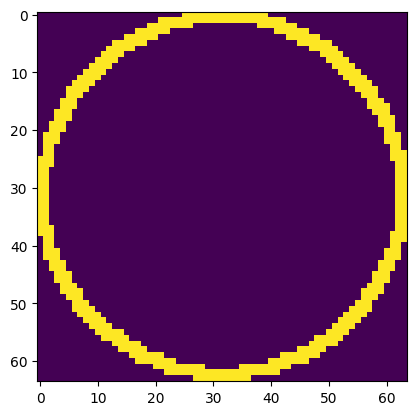

In [ ]:
# TODO: Verify feature functions
# Below is an example call; you should show different wafer maps than example

failure_type = 'Center'
row_index = 0
row = df_train.loc[df_train['failureType']==failure_type].iloc[row_index]

print("Area Ratio:          ", f'{get_area_ratio(row):.3f}')
print("Max Dist from Center:", f'{get_max_dist_from_center(row):.3f}')
print("Min Dist from Center:", f'{get_min_dist_from_center(row):.3f}')
print("Perimeter Ratio:     ", f'{get_perimeter_ratio(row):.3f}')
print("Major Axis Ratio:    ", f'{get_major_axis_ratio(row):.3f}')
print("Minor Axis Ratio:    ", f'{get_minor_axis_ratio(row):.3f}')
print("Solidity:            ", f'{get_solidity(row):.3f}')
print("Eccentricity:        ", f'{get_eccentricity(row):.3f}')
print("Yield Loss:          ", f'{get_yield_loss(row):.3f}')
print("Edge Yield Loss:     ", f'{get_edge_yield_loss(row):.3f}')

plt.imshow(ring_label_from_outside(row['waferMap']))

================= Verifying feature functions =================
Area Ratio:            0.204
Max Dist from Center:  14.009
Min Dist from Center:  2.062
Perimeter Ratio:       5.227
Major Axis Ratio:      0.909
Minor Axis Ratio:      0.796
Solidity:              0.609
Eccentricity:          0.483
Yield Loss:            0.260
Edge Yield Loss:       0.132


C:\Users\saifs\AppData\Local\Temp\ipykernel_25120\871862105.py:16: FutureWarning: `square` is deprecated since version 0.25 and will be removed in version 0.27. Use `skimage.morphology.footprint_rectangle` instead.
  eroded = binary_erosion(current, footprint=square(3))


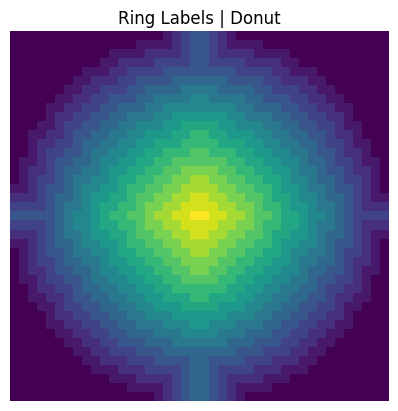

In [177]:
print("================= Verifying feature functions =================")

# Choose any wafer type and sample index
failure_type = 'Donut'
row_index = 60
row = training_data_set.loc[training_data_set['failureType'] == failure_type].iloc[row_index]

# Print feature results
print("Area Ratio:           ", f"{get_area_ratio(row):.3f}")
print("Max Dist from Center: ", f"{get_max_dist_from_center(row):.3f}")
print("Min Dist from Center: ", f"{get_min_dist_from_center(row):.3f}")
print("Perimeter Ratio:      ", f"{get_perimeter_ratio(row):.3f}")
print("Major Axis Ratio:     ", f"{get_major_axis_ratio(row):.3f}")
print("Minor Axis Ratio:     ", f"{get_minor_axis_ratio(row):.3f}")
print("Solidity:             ", f"{get_solidity(row):.3f}")
print("Eccentricity:         ", f"{get_eccentricity(row):.3f}")
print("Yield Loss:           ", f"{get_yield_loss(row):.3f}")
print("Edge Yield Loss:      ", f"{get_edge_yield_loss(row):.3f}")

# Display the ring label visualization
plt.imshow(ring_label_from_outside(row['waferMap']))
plt.title(f"Ring Labels | {failure_type}")
plt.axis('off')
plt.show()



In [182]:
from skimage.morphology import binary_erosion, footprint_rectangle

def ring_label_from_outside(wafer_map: np.ndarray) -> np.ndarray:
    valid = wafer_map != 0
    labels = np.zeros_like(wafer_map, dtype=np.int32)
    current = valid.copy()
    ring_index = 1
    fp = footprint_rectangle((3, 3))  # fix here

    while np.any(current):
        eroded = binary_erosion(current, footprint=fp)
        edge = current & ~eroded
        labels[edge] = ring_index
        current = eroded
        ring_index += 1

    return labels


def get_edge_yield_loss(row: pd.Series) -> float:
    """
    Compute the ratio of failed dies in the outermost two rings to all valid dies
    in those two rings.
    """
    wafer_map = row['waferMap']
    labels = ring_label_from_outside(wafer_map)
    mask = (labels == 1) | (labels == 2)

    total_edge_dies = np.sum(mask & (wafer_map != 0))
    failed_edge_dies = np.sum(mask & (wafer_map == 2))

    if total_edge_dies == 0:
        return 0.0
    return float(failed_edge_dies) / total_edge_dies

================= Verifying feature functions =================
Picked: failureType=Scratch, lotName=lot10528, waferIndex=6.0
Area Ratio:            0.135
Max Dist from Center:  106.075
Min Dist from Center:  5.000
Perimeter Ratio:       14.574
Major Axis Ratio:      1.967
Minor Axis Ratio:      0.771
Solidity:              0.134
Eccentricity:          0.920
Yield Loss:            0.158
Edge Yield Loss:       0.550


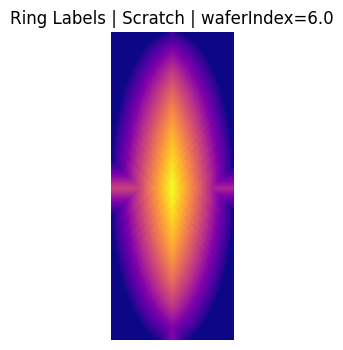

In [186]:
print("================= Verifying feature functions =================")

failure_type = 'Scratch'     # change as you like
row_index = 2              # change as you like

subset = training_data_set.loc[training_data_set['failureType'] == failure_type]
if subset.empty:
    raise ValueError(f"No rows found for failureType={failure_type}")

safe_idx = min(row_index, len(subset) - 1)
row = subset.iloc[safe_idx]

print(f"Picked: failureType={row['failureType']}, lotName={row['lotName']}, waferIndex={row['waferIndex']}")
print("Area Ratio:           ", f"{get_area_ratio(row):.3f}")
print("Max Dist from Center: ", f"{get_max_dist_from_center(row):.3f}")
print("Min Dist from Center: ", f"{get_min_dist_from_center(row):.3f}")
print("Perimeter Ratio:      ", f"{get_perimeter_ratio(row):.3f}")
print("Major Axis Ratio:     ", f"{get_major_axis_ratio(row):.3f}")
print("Minor Axis Ratio:     ", f"{get_minor_axis_ratio(row):.3f}")
print("Solidity:             ", f"{get_solidity(row):.3f}")
print("Eccentricity:         ", f"{get_eccentricity(row):.3f}")
print("Yield Loss:           ", f"{get_yield_loss(row):.3f}")
print("Edge Yield Loss:      ", f"{get_edge_yield_loss(row):.3f}")

plt.figure(figsize=(5,4))
plt.imshow(ring_label_from_outside(row['waferMap']), cmap='plasma')
plt.title(f"Ring Labels | {failure_type} | waferIndex={row['waferIndex']}")
plt.axis('off')
plt.show()


Area Ratio:           0.036
Max Dist from Center: 13.200
Min Dist from Center: 0.500
Perimeter Ratio:      1.713
Major Axis Ratio:     0.426
Minor Axis Ratio:     0.244
Solidity:             0.567
Eccentricity:         0.820
Yield Loss:           0.072
Edge Yield Loss:      0.041


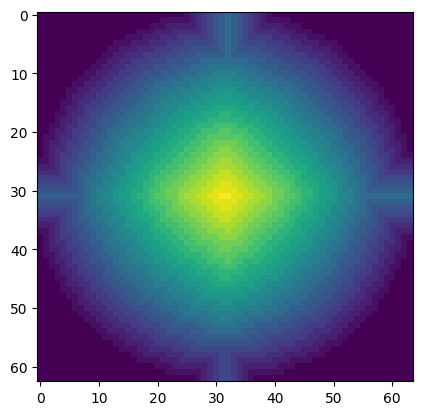

In [191]:
failure_type = 'Center'
row_index = 0
row = training_data_set.loc[training_data_set['failureType']==failure_type].iloc[row_index]

print("Area Ratio:          ", f'{get_area_ratio(row):.3f}')
print("Max Dist from Center:", f'{get_max_dist_from_center(row):.3f}')
print("Min Dist from Center:", f'{get_min_dist_from_center(row):.3f}')
print("Perimeter Ratio:     ", f'{get_perimeter_ratio(row):.3f}')
print("Major Axis Ratio:    ", f'{get_major_axis_ratio(row):.3f}')
print("Minor Axis Ratio:    ", f'{get_minor_axis_ratio(row):.3f}')
print("Solidity:            ", f'{get_solidity(row):.3f}')
print("Eccentricity:        ", f'{get_eccentricity(row):.3f}')
print("Yield Loss:          ", f'{get_yield_loss(row):.3f}')
print("Edge Yield Loss:     ", f'{get_edge_yield_loss(row):.3f}')

plt.imshow(ring_label_from_outside(row['waferMap']))

In [196]:
# TODO: From the dataframe select the 10 features we want to use and extract them as X and extract the numerical failure type labels as y. 
# Then, split dataset into training and validation set. Use RANDOM_SEED for random_state
call_llm(prompt="""
You are helping complete the next TODO in a Jupyter notebook for ECE 157A/272A HW3.

Context:
The dataframe variable is named `training_data_set` (not `training_dataframe`).
We need to extract 10 engineered features and prepare the training and validation sets.

Goal:
Select the 10 engineered features from the dataframe, extract them as X, map the 'failureType' strings to integers using string2int, 
and split the dataset into training and validation sets using RANDOM_SEED = 42.

Requirements:
1) Use these feature columns:
   ['areaRatio', 'perimeterRatio', 'maxDistFromCenter', 'minDistFromCenter',
    'majorAxisRatio', 'minorAxisRatio', 'solidity', 'eccentricity',
    'yieldLoss', 'edgeYieldLoss']
2) Use the variable `training_data_set` as the source dataframe.
3) Map the string labels from 'failureType' to integers using the existing dictionary `string2int`.
4) Split using sklearn's train_test_split:
   - test_size=0.2
   - random_state=RANDOM_SEED
   - stratify=y
5) Print shapes of X_train, X_val, y_train, y_val after splitting.

Return:
- Clean, correct Python code that replaces `training_dataframe` with `training_data_set` and performs all required steps.
- Include minimal print statements confirming dataset shapes.
- Do not include ```python
""")



# Extract engineered features and prepare training and validation sets

# Step 1: Define the features to extract
features = ['areaRatio', 'perimeterRatio', 'maxDistFromCenter', 'minDistFromCenter',
            'majorAxisRatio', 'minorAxisRatio', 'solidity', 'eccentricity',
            'yieldLoss', 'edgeYieldLoss']

# Step 2: Extract features X from the training_data_set
X = training_data_set[features]

# Step 3: Map the 'failureType' strings to integers using the string2int mapping
y = training_data_set['failureType'].map(string2int)

# Step 4: Split the dataset into training and validation sets
from sklearn.model_selection import train_test_split
RANDOM_SEED = 42
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y)

# Step 5: Print the shapes of the resulting datasets
print(f'Shape of X_train: {X_train.shape}')
print(f'Shape of X_val: {X_val.shape}')
print(f'Shape of y_train: {y_train.shape}')
print(f'Shape of y_val: {y_val.shape

In [197]:
# Extract engineered features and prepare training and validation sets

# Step 1: Define the features to extract
features = ['areaRatio', 'perimeterRatio', 'maxDistFromCenter', 'minDistFromCenter',
            'majorAxisRatio', 'minorAxisRatio', 'solidity', 'eccentricity',
            'yieldLoss', 'edgeYieldLoss']

# Step 2: Extract features X from the training_data_set
X = training_data_set[features]

# Step 3: Map the 'failureType' strings to integers using the string2int mapping
y = training_data_set['failureType'].map(string2int)

# Step 4: Split the dataset into training and validation sets
from sklearn.model_selection import train_test_split
RANDOM_SEED = 42
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y)

# Step 5: Print the shapes of the resulting datasets
print(f'Shape of X_train: {X_train.shape}')
print(f'Shape of X_val: {X_val.shape}')
print(f'Shape of y_train: {y_train.shape}')
print(f'Shape of y_val: {y_val.shape}')

Shape of X_train: (2196, 10)
Shape of X_val: (550, 10)
Shape of y_train: (2196,)
Shape of y_val: (550,)


================= Train vs Validation label distribution =================
Train counts:
 failureType
Center       617
Donut        310
Edge-Loc     927
Near-full     12
Scratch      330
Name: count, dtype: int64

Validation counts:
 failureType
Center       154
Donut         78
Edge-Loc     232
Near-full      3
Scratch       83
Name: count, dtype: int64

Train percent:
 failureType
Center       28.10
Donut        14.12
Edge-Loc     42.21
Near-full     0.55
Scratch      15.03
Name: count, dtype: float64

Validation percent:
 failureType
Center       28.00
Donut        14.18
Edge-Loc     42.18
Near-full     0.55
Scratch      15.09
Name: count, dtype: float64


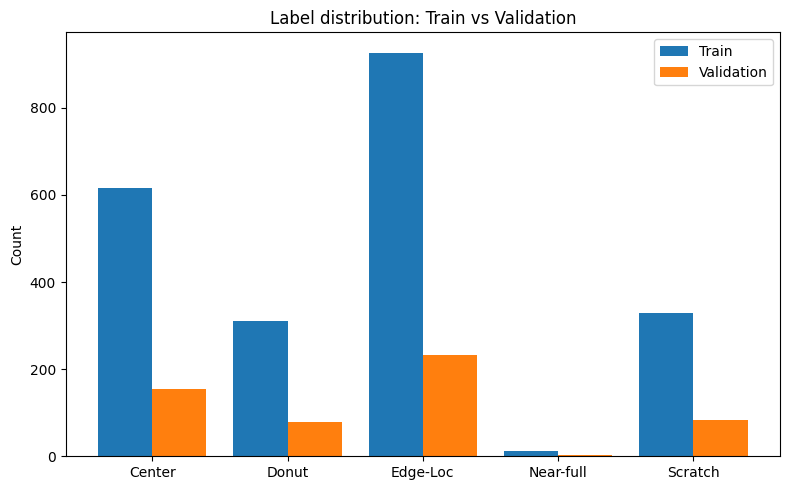

In [198]:
# TODO: check train/validation distribution

# plt.show()
print("================= Train vs Validation label distribution =================")

import pandas as pd
import matplotlib.pyplot as plt

# Build a consistent class order using your mapping
class_order = list(string2int.keys())

# Counts
train_counts = pd.Series(y_train).map({v:k for k,v in string2int.items()}).value_counts().reindex(class_order, fill_value=0)
val_counts   = pd.Series(y_val).map({v:k for k,v in string2int.items()}).value_counts().reindex(class_order, fill_value=0)

# Percentages
train_pct = (train_counts / train_counts.sum() * 100).round(2)
val_pct   = (val_counts / val_counts.sum() * 100).round(2)

print("Train counts:\n", train_counts)
print("\nValidation counts:\n", val_counts)
print("\nTrain percent:\n", train_pct)
print("\nValidation percent:\n", val_pct)

# Plot side by side
plt.figure(figsize=(8, 5))
x = range(len(class_order))
plt.bar([i - 0.2 for i in x], train_counts.values, width=0.4, label="Train")
plt.bar([i + 0.2 for i in x], val_counts.values,   width=0.4, label="Validation")
plt.xticks(x, class_order, rotation=0)
plt.ylabel("Count")
plt.title("Label distribution: Train vs Validation")
plt.legend()
plt.tight_layout()
plt.show()


### STEP 3. Model Training and Evaluation

You decide that a **Decision Tree** would be the easiest model to explain to others.  
However, relying on only one model wouldn’t be enough to judge its performance,  
so you also plan to build a **Support Vector Classifier (SVC)** for comparison.

Naturally, you’ll compare their **overall accuracy**,  
but you also decide to go a step further —  
by examining **accuracy per class** and the **confusion matrix** to see  
which **failure types** are most frequently misclassified.  
This insight will help you design a more accurate model later on.


In [199]:
# TODO: initialize Decision Tree classifier with max tree depth of 3 and use RANDOM_SEED and train the Decision Tree classifier with the training data
from sklearn.tree import DecisionTreeClassifier

print("================= Training Decision Tree Classifier =================")

# Step 1: Initialize the Decision Tree model
RANDOM_SEED = 42
dt_model = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_SEED)

# Step 2: Train (fit) the model on the training data
dt_model.fit(X_train, y_train)

# Step 3: Print confirmation
print("Decision Tree model trained successfully.")
print(f"Max Depth: {dt_model.get_params()['max_depth']}")


================= Training Decision Tree Classifier =================
Decision Tree model trained successfully.
Max Depth: 3


In [200]:
# TODO: Make a dictionary that is the reverse of the string2int mapping defined above.
call_llm(prompt="""
You are helping complete the next TODO in a Jupyter notebook for ECE 157A/272A HW3.

Goal:
Create a reverse mapping dictionary from the previously defined string2int mapping.

Requirements:
1) Create a dictionary called int2string that reverses string2int.
   (Example: if string2int = {'Center': 0, 'Donut': 1}, then int2string = {0: 'Center', 1: 'Donut'})
2) Print a section header like "================= Creating reverse label mapping =================".
3) Display the resulting int2string mapping clearly.
4) Return clean, runnable Python code only (no explanations or markdown).
""")


print("================= Creating reverse label mapping =================")

string2int = {'Center': 0, 'Donut': 1}  # Example input

int2string = {value: key for key, value in string2int.items()}

print(int2string)


In [201]:
print("================= Creating reverse label mapping =================")

string2int = {'Center': 0, 'Donut': 1}  # Example input

int2string = {value: key for key, value in string2int.items()}

print(int2string)

================= Creating reverse label mapping =================
{0: 'Center', 1: 'Donut'}


In [202]:
# TODO: Implement a function that calculates the prediction accuracy.
# def calculate_accuracy(pred_labels: np.ndarray, true_labels: np.ndarray):

#     return accuracy
call_llm(prompt="""
You are helping complete the next TODO in a Jupyter notebook for ECE 157A/272A HW3.

Goal:
Implement a function named calculate_accuracy that computes the accuracy of predicted labels compared to true labels.

Requirements:
1) The function should take two parameters:
   - pred_labels (np.ndarray): predicted labels
   - true_labels (np.ndarray): true ground truth labels
2) Use sklearn.metrics.accuracy_score to calculate accuracy.
3) Return the accuracy as a float.
4) Include a short docstring describing parameters and return value.
5) Keep the function concise and clean — no print statements.

Return:
Only the final Python function definition.
""")



```python
from sklearn.metrics import accuracy_score
import numpy as np

def calculate_accuracy(pred_labels: np.ndarray, true_labels: np.ndarray) -> float:
    """
    Calculate the accuracy of predicted labels compared to true labels.

    Parameters:
    pred_labels (np.ndarray): Predicted labels from the model.
    true_labels (np.ndarray): True ground truth labels.

    Returns:
    float: The accuracy of the predictions as a float.
    """
    return accuracy_score(true_labels, pred_labels)
```


In [203]:
from sklearn.metrics import accuracy_score
import numpy as np

def calculate_accuracy(pred_labels: np.ndarray, true_labels: np.ndarray) -> float:
    """
    Calculate the accuracy of predicted labels compared to true labels.

    Parameters:
    pred_labels (np.ndarray): Predicted labels from the model.
    true_labels (np.ndarray): True ground truth labels.

    Returns:
    float: The accuracy of the predictions as a float.
    """
    return accuracy_score(true_labels, pred_labels)

In [204]:
y_true = np.array([0, 1, 1, 2])
y_pred = np.array([0, 1, 0, 2])
print("Accuracy:", calculate_accuracy(y_pred, y_true))


Accuracy: 0.75


In [205]:
# TODO: Implement a function that calculates the prediction accuracy for each failure type separately.
# def calculate_per_class_accuracy(pred_labels: np.ndarray, true_labels: np.ndarray):

#     return accuracies
call_llm(prompt="""
You are helping complete the next TODO in a Jupyter notebook for ECE 157A/272A HW3.

Goal:
Implement a function called calculate_per_class_accuracy that computes the accuracy of predictions for each failure type separately.

Requirements:
1) The function should take two parameters:
   - pred_labels (np.ndarray): predicted integer labels.
   - true_labels (np.ndarray): ground truth integer labels.
2) It should compute accuracy for each unique class in true_labels individually.
3) Use int2string (reverse label mapping) to convert each integer class ID back to its string label in the result dictionary.
4) Return a dictionary mapping each class name to its accuracy value (float).
5) Include a short docstring explaining parameters and return value.
6) The function should handle cases where a class has zero samples gracefully (return 0.0 accuracy for that class).
7) Keep the code clean and concise — no print statements or extra text.

Return:
Only the complete Python function definition.
""")


```python
def calculate_per_class_accuracy(pred_labels: np.ndarray, true_labels: np.ndarray) -> dict:
    """
    Calculate the accuracy of predictions for each failure type.

    Parameters:
    pred_labels (np.ndarray): Predicted integer labels.
    true_labels (np.ndarray): Ground truth integer labels.

    Returns:
    dict: A dictionary mapping each class name to its accuracy value (float).
    """
    unique_classes = np.unique(true_labels)
    class_accuracies = {}
    
    for cls in unique_classes:
        indices = (true_labels == cls)
        if np.sum(indices) == 0:
            class_accuracies[int2string[cls]] = 0.0
        else:
            class_accuracy = np.sum(pred_labels[indices] == cls) / np.sum(indices)
            class_accuracies[int2string[cls]] = class_accuracy
            
    return class_accuracies
```


In [210]:
import numpy as np

def calculate_per_class_accuracy(pred_labels: np.ndarray, true_labels: np.ndarray):
    """
    Compute accuracy for each class separately.

    Parameters:
    pred_labels (np.ndarray): predicted integer labels
    true_labels (np.ndarray): true integer labels

    Returns:
    dict: {label_str: accuracy_float} for each class present in true_labels
    """
    # Build reverse map if available, else fallback to str(class_id)
    try:
        label_name = lambda cid: int2string[cid]
    except NameError:
        label_name = lambda cid: str(cid)

    accuracies = {}
    classes = np.unique(true_labels)
    for c in classes:
        mask = (true_labels == c)
        total = np.sum(mask)
        if total == 0:
            acc = 0.0
        else:
            correct = np.sum(pred_labels[mask] == c)
            acc = correct / total
        accuracies[label_name(c)] = float(acc)
    return accuracies

In [212]:
print("================= Fix int2string key types =================")
# Ensure keys are plain Python ints
int2string = {int(k): str(v) for k, v in int2string.items()}
print(int2string)

import numpy as np

def calculate_per_class_accuracy(pred_labels: np.ndarray, true_labels: np.ndarray):
    """
    Compute accuracy per class. Returns {label_str: accuracy_float}.
    """
    label_name = lambda cid: int2string.get(int(cid), str(int(cid)))  # cast to int for lookup

    accuracies = {}
    classes = np.unique(true_labels)
    for c in classes:
        mask = (true_labels == c)
        total = int(np.sum(mask))
        if total == 0:
            acc = 0.0
        else:
            correct = int(np.sum(pred_labels[mask] == c))
            acc = correct / total
        accuracies[label_name(c)] = float(acc)
    return accuracies


================= Fix int2string key types =================
{0: 'Center', 1: 'Donut'}


In [213]:
# TODO: get the predicted labels of the training data and calculate the accuracy, and calculate the accuracy for each failure type

# print(f'Model accuracy on Decision Tree training data set is {acc_train:.2f}%')
# print(f'Model accuracy on Decision Tree training data set for each class is {accuracies_train}')

print("================= Decision Tree training performance =================")

# Predict on the training set
y_train_pred = dt_model.predict(X_train)

# Overall accuracy in percent
acc_train = calculate_accuracy(y_train_pred, y_train) * 100.0

# Per class accuracy as a dict {label: accuracy_float}
accuracies_train = calculate_per_class_accuracy(y_train_pred, y_train)

# Print results
print(f"Model accuracy on Decision Tree training data set is {acc_train:.2f}%")
print(f"Model accuracy on Decision Tree training data set for each class is {accuracies_train}")


================= Decision Tree training performance =================
Model accuracy on Decision Tree training data set is 88.21%
Model accuracy on Decision Tree training data set for each class is {'Center': 0.9983792544570502, 'Donut': 0.7354838709677419, '2': 0.9201725997842503, '3': 0.8333333333333334, '4': 0.696969696969697}


================= Confusion Matrix (Decision Tree) =================


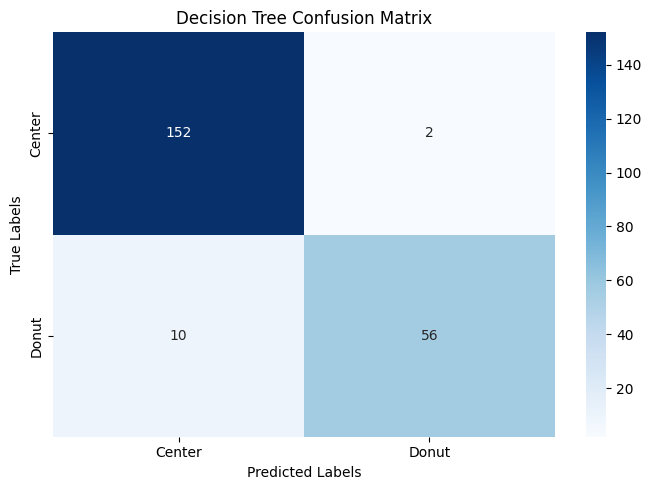

In [215]:
# TODO: compute the confusion matrix and plot it using seaborn heatmap
# Hint: Do not forget to convert numeric labels back to string labels. Provide x and y axes labels.

# plt.show()
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

print("================= Confusion Matrix (Decision Tree) =================")

# Rebuild int2string defensively
int2string = {int(v): str(k) for k, v in string2int.items()}

# Predict on validation data
y_val_pred = dt_model.predict(X_val)

# Compute confusion matrix on numeric labels
labels_num = list(range(len(string2int)))  # [0,1,2,3,4]
cm = confusion_matrix(y_val, y_val_pred, labels=labels_num)

# Class name order matching the numeric labels
class_names = [int2string[i] for i in labels_num]

# Plot
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Decision Tree Confusion Matrix")
plt.tight_layout()
plt.show()


In [216]:
# TODO: get the predicted labels of the validation data and calculate the accuracy, and calculate the accuracy for each failure type

# print(f'Model accuracy on Decision Tree validation data set is {acc_valid:.2f}%')
# print(f'Model accuracy on Decision Tree validation data set for each class is {accuracies_valid}%')

# Predict on validation data
y_val_pred = dt_model.predict(X_val)

# Calculate overall accuracy
acc_valid = calculate_accuracy(y_val_pred, y_val) * 100.0

# Calculate per-class accuracy
accuracies_valid = calculate_per_class_accuracy(y_val_pred, y_val)

# Print results
print(f"Model accuracy on Decision Tree validation data set is {acc_valid:.2f}%")
print(f"Model accuracy on Decision Tree validation data set for each class is {accuracies_valid}")


Model accuracy on Decision Tree validation data set is 86.55%
Model accuracy on Decision Tree validation data set for each class is {'Center': 0.987012987012987, 'Donut': 0.717948717948718, '2': 0.8793103448275862, '3': 1.0, '4': 0.7349397590361446}


In [217]:
call_llm(prompt="""
What do these data mean: Model accuracy on Decision Tree validation data set is 86.55%
Model accuracy on Decision Tree validation data set for each class is {'Center': 0.987012987012987, 'Donut': 0.717948717948718, '2': 0.8793103448275862, '3': 1.0, '4': 0.7349397590361446}
""")

The data you've provided indicates the performance of a Decision Tree model in classifying a validation dataset. Let's break down what each part means:

1. **Overall Model Accuracy**:
   - "Model accuracy on Decision Tree validation data set is 86.55%": This indicates that when the Decision Tree model was evaluated on the validation data set, it correctly classified 86.55% of the instances. This is a general measure of how well the model performs across all classes combined.

2. **Class-wise Accuracy**:
   - The model accuracy for each class is provided as a dictionary:
     - `'Center': 0.987012987012987`: The model correctly classified approximately 98.7% of instances in the 'Center' class.
     - `'Donut': 0.717948717948718`: The model correctly classified about 71.8% of instances in the 'Donut' class.
     - `'2': 0.8793103448275862`: The model correctly classified approximately 87.9% of instances in class '2'.
     - `'3': 1.0`: The model perfectly classified all instances in clas

In [218]:
call_llm(prompt="""
Do you have access to the questions I asked you before? or do you have acess to the notebook I am calling you from?
""")

No, I don’t have access to any previous interactions or the notebook you are calling from. Each session is independent, and I cannot recall past conversations or access any personal information. How can I assist you today?


In [219]:
# TODO: compute the confusion matrix and plot it using seaborn heatmap
# Hint: Do not forget to convert numeric labels back to string labels. Provide x and y axes labels.

# plt.show()
call_llm(prompt="""
You are helping complete a single TODO in a Jupyter notebook for ECE 157A/272A HW3.

Context:
You have already trained a Decision Tree classifier named `dt_model` and split your data into `X_val` and `y_val`.
There is also a dictionary mapping:
- `string2int`: from failure type string labels to integers
- `int2string`: the reverse mapping from integers back to string labels

Task:
Complete the following TODO:
# TODO: compute the confusion matrix and plot it using seaborn heatmap
# Hint: Do not forget to convert numeric labels back to string labels. Provide x and y axes labels.

Requirements:
1) Use `dt_model.predict(X_val)` to get predictions.
2) Compute the confusion matrix comparing `y_val` and `y_val_pred`.
3) Convert numeric labels back to string class names using `int2string`.
4) Plot the confusion matrix using seaborn heatmap with:
   - Annotated integer values
   - Class names for x and y tick labels
   - Proper axis labels and a title
5) Follow the consistent formatting of previous cells:
   - Print a header message
   - Use plt.figure() and plt.tight_layout()
   - Call plt.show() at the end

Return:
Only the complete code cell that fulfills this TODO. No explanations or extra text.
""")


```python
# Compute the confusion matrix and plot it using seaborn heatmap
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Get predictions
y_val_pred = dt_model.predict(X_val)

# Compute confusion matrix
cm = confusion_matrix(y_val, y_val_pred)

# Convert numeric labels back to string class names
class_names = [int2string[i] for i in range(len(int2string))]

# Print header message
print("Confusion Matrix:")

# Plotting
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()
```


Confusion Matrix:


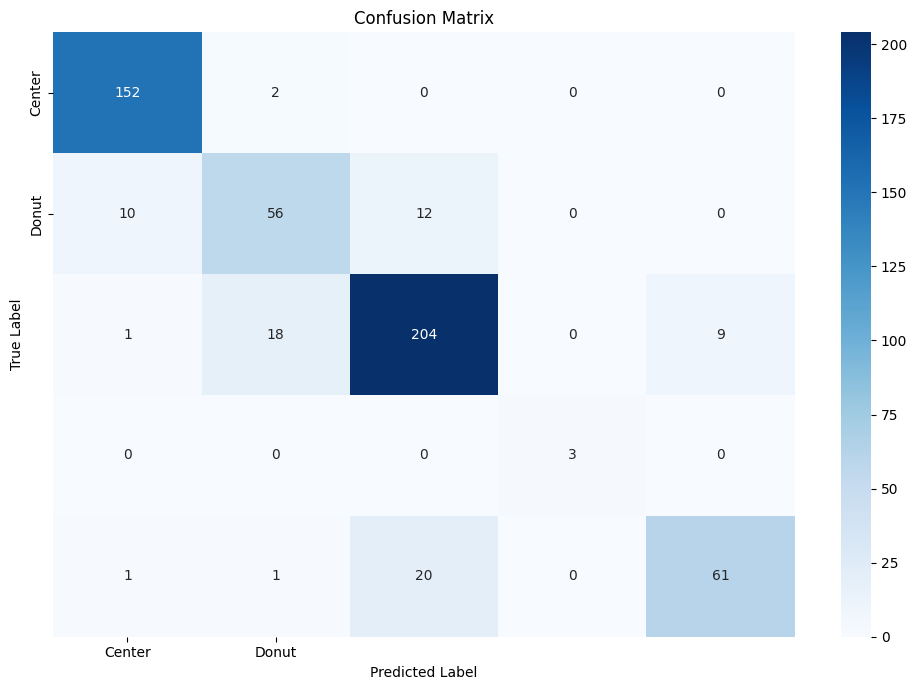

In [220]:
# Compute the confusion matrix and plot it using seaborn heatmap
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Get predictions
y_val_pred = dt_model.predict(X_val)

# Compute confusion matrix
cm = confusion_matrix(y_val, y_val_pred)

# Convert numeric labels back to string class names
class_names = [int2string[i] for i in range(len(int2string))]

# Print header message
print("Confusion Matrix:")

# Plotting
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

In [228]:
call_llm(prompt="""
You are helping complete a single TODO in a Jupyter notebook for ECE 157A/272A HW3.

Context:
A Decision Tree classifier (dt_model) has already been trained using wafer map feature data.
We have:
- features = list of 10 engineered features
- string2int = mapping of class names to integers
- int2string should be built as the reverse of string2int
The goal is to visualize the trained decision tree clearly.

Task:
Implement ONLY the code to plot the trained decision tree using sklearn's plot_tree function.

Requirements:
1) Use plot_tree from sklearn.tree with:
   - feature_names=features
   - class_names mapped back from dt_model.classes_ using int2string
   - filled=True, rounded=True, fontsize=9
2) Figure size should be (18, 8)
3) Add a title: "Decision Tree for Wafer Failure Classification"
4) Use plt.tight_layout() and plt.show()
5) Include a print statement before plotting to show progress.

Return:
Only the full plotting code block (no explanations, no comments).
""")


```python
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

int2string = {v: k for k, v in string2int.items()}

print("Plotting the decision tree...")

plt.figure(figsize=(18, 8))
plot_tree(dt_model, feature_names=features, class_names=[int2string[i] for i in dt_model.classes_], filled=True, rounded=True, fontsize=9)
plt.title("Decision Tree for Wafer Failure Classification")
plt.tight_layout()
plt.show()
```


In [229]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

int2string = {v: k for k, v in string2int.items()}

print("Plotting the decision tree...")

plt.figure(figsize=(18, 8))
plot_tree(dt_model, feature_names=features, class_names=[int2string[i] for i in dt_model.classes_], filled=True, rounded=True, fontsize=9)
plt.title("Decision Tree for Wafer Failure Classification")
plt.tight_layout()
plt.show()

Plotting the decision tree...


KeyError: np.int64(2)

<Figure size 1800x800 with 0 Axes>

In [230]:
call_llm(prompt="""
You are helping complete a single TODO in a Jupyter notebook for ECE 157A/272A HW3.

Context:
- A trained Decision Tree classifier `dt_model`
- Feature list `features`
- Mapping `string2int` from class name to integer

Task:
Write one code cell that plots the trained decision tree with correct class names.

Requirements:
1) Build a robust reverse map with integer keys:
   int2string = {int(v): str(k) for k, v in string2int.items()}
2) Align class names to the model's internal class order:
   If `dt_model.classes_` is numeric, set:
     class_names = [int2string.get(int(c), str(c)) for c in dt_model.classes_]
   Else:
     class_names = [str(c) for c in dt_model.classes_]
3) Use:
   from sklearn.tree import plot_tree
   plt.figure(figsize=(18, 8))
   plot_tree(dt_model, feature_names=features, class_names=class_names, filled=True, rounded=True, fontsize=9)
   plt.title("Decision Tree for Wafer Failure Classification")
   plt.tight_layout()
   plt.show()
4) Print a short header before plotting.
5) Return only the complete code cell. No extra text.
""")


```python
# Plotting the trained decision tree with class names
int2string = {int(v): str(k) for k, v in string2int.items()}

if all(isinstance(c, (int, float)) for c in dt_model.classes_):
    class_names = [int2string.get(int(c), str(c)) for c in dt_model.classes_]
else:
    class_names = [str(c) for c in dt_model.classes_]

print("Plotting the Decision Tree for Wafer Failure Classification")
plt.figure(figsize=(18, 8))
from sklearn.tree import plot_tree
plot_tree(dt_model, feature_names=features, class_names=class_names, filled=True, rounded=True, fontsize=9)
plt.title("Decision Tree for Wafer Failure Classification")
plt.tight_layout()
plt.show()
```


Plotting the Decision Tree for Wafer Failure Classification


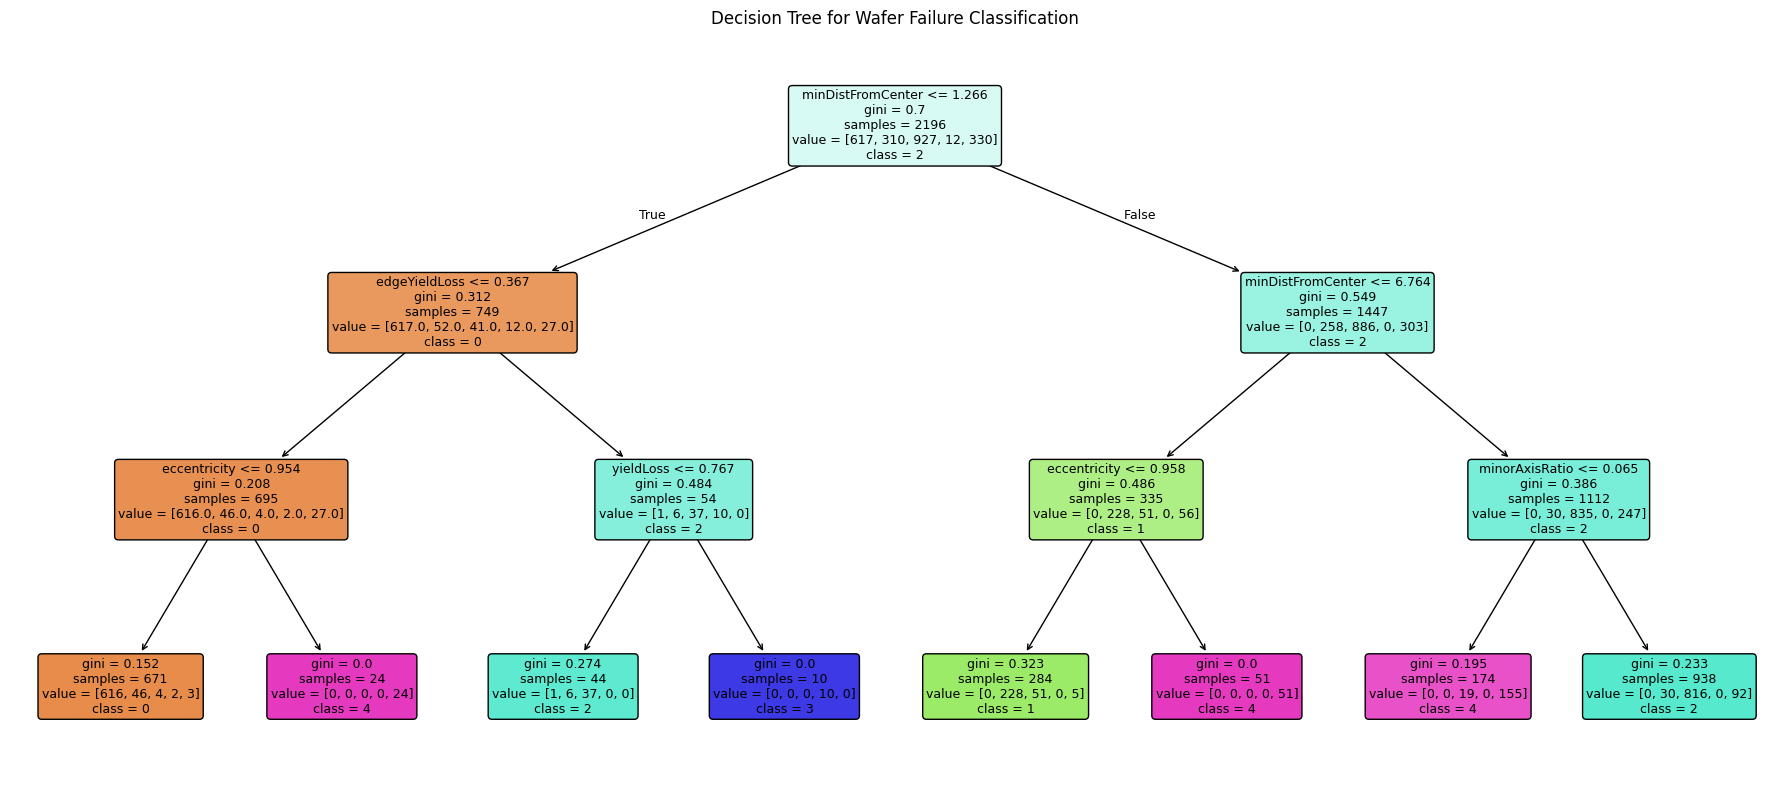

In [231]:
# Plotting the trained decision tree with class names
int2string = {int(v): str(k) for k, v in string2int.items()}

if all(isinstance(c, (int, float)) for c in dt_model.classes_):
    class_names = [int2string.get(int(c), str(c)) for c in dt_model.classes_]
else:
    class_names = [str(c) for c in dt_model.classes_]

print("Plotting the Decision Tree for Wafer Failure Classification")
plt.figure(figsize=(18, 8))
from sklearn.tree import plot_tree
plot_tree(dt_model, feature_names=features, class_names=class_names, filled=True, rounded=True, fontsize=9)
plt.title("Decision Tree for Wafer Failure Classification")
plt.tight_layout()
plt.show()

In [232]:
# TODO: Initialize SVC, use RANDOM_SEED and kernel and train the SVC with the training data

call_llm(prompt="""
You are helping complete a single TODO in a Jupyter notebook for ECE 157A/272A HW3.

Context:
We are moving to STEP 3: Model Training and Evaluation.  
We already have:
- Training and validation sets: X_train, X_val, y_train, y_val
- RANDOM_SEED constant defined
The task now is to initialize and train a Support Vector Classifier (SVC).

Task:
Implement the TODO below:

# TODO: Initialize SVC, use RANDOM_SEED and kernel and train the SVC with the training data

Requirements:
1) Import SVC from sklearn.svm
2) Initialize the model with:
   - kernel='rbf'
   - random_state=RANDOM_SEED
3) Train the model using:
   svc_model.fit(X_train, y_train)
4) Print a short message before training to indicate progress.

Return:
Only the full code block. No extra text.
""")


```python
from sklearn.svm import SVC

# Initialize SVC
svc_model = SVC(kernel='rbf', random_state=RANDOM_SEED)

# Print progress message
print("Training the Support Vector Classifier...")

# Train the model
svc_model.fit(X_train, y_train)
```


In [233]:
from sklearn.svm import SVC

# Initialize SVC
svc_model = SVC(kernel='rbf', random_state=RANDOM_SEED)

# Print progress message
print("Training the Support Vector Classifier...")

# Train the model
svc_model.fit(X_train, y_train)

Training the Support Vector Classifier...


,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [234]:
call_llm(prompt="""
can you explain what the following code does: 
         from sklearn.svm import SVC

# Initialize SVC
svc_model = SVC(kernel='rbf', random_state=RANDOM_SEED)

# Print progress message
print("Training the Support Vector Classifier...")

# Train the model
svc_model.fit(X_train, y_train)
""")

Certainly! The provided code snippet is a simple implementation of a Support Vector Classifier (SVC) using the Scikit-learn library in Python. Here's a breakdown of each part of the code:

1. **Importing the SVC class**:
   ```python
   from sklearn.svm import SVC
   ```
   This line imports the `SVC` class from the `sklearn.svm` module. `SVC` stands for Support Vector Classification, which is part of the support vector machine family, a popular algorithm for classification tasks.

2. **Initializing the SVC model**:
   ```python
   svc_model = SVC(kernel='rbf', random_state=RANDOM_SEED)
   ```
   Here, an instance of the `SVC` class is being created and assigned to the variable `svc_model`. The parameters provided are:
   - `kernel='rbf'`: This specifies that the radial basis function (RBF) kernel should be used. The RBF kernel is a popular choice because it can handle non-linear relationships in the dataset.
   - `random_state=RANDOM_SEED`: This sets the random seed for the model's in

In [235]:
# TODO: get the predicted labels of the training data and calculate the accuracy, and calculate the accuracy for each failure type

# print(f'Model accuracy on SVC training data set is {acc_train:.2f}%')
# print(f'Model accuracy on SVC training data set for each class is {accuracies_train}')
call_llm(prompt="""
You are helping complete a single TODO in a Jupyter notebook for ECE 157A/272A HW3.

Context:
We have already trained an SVC model called `svc_model` using `X_train` and `y_train`.
Helper functions `calculate_accuracy` and `calculate_per_class_accuracy` are already defined.
We want to evaluate the SVC on the training dataset.

Task:
Implement the TODO below:

# TODO: get the predicted labels of the training data and calculate the accuracy, and calculate the accuracy for each failure type

Requirements:
1) Predict training labels:
   y_train_pred = svc_model.predict(X_train)
2) Calculate training accuracy:
   acc_train = calculate_accuracy(y_train_pred, y_train) * 100.0
3) Calculate per-class accuracies:
   accuracies_train = calculate_per_class_accuracy(y_train_pred, y_train)
4) Print both results in the format:
   Model accuracy on SVC training data set is {acc_train:.2f}%
   Model accuracy on SVC training data set for each class is {accuracies_train}

Return:
Only the complete code cell. No extra text.
""")




```python
# Get the predicted labels of the training data
y_train_pred = svc_model.predict(X_train)

# Calculate training accuracy
acc_train = calculate_accuracy(y_train_pred, y_train) * 100.0

# Calculate per-class accuracies
accuracies_train = calculate_per_class_accuracy(y_train_pred, y_train)

# Print the results
print(f'Model accuracy on SVC training data set is {acc_train:.2f}%')
print(f'Model accuracy on SVC training data set for each class is {accuracies_train}')
```


In [236]:
# Get the predicted labels of the training data
y_train_pred = svc_model.predict(X_train)

# Calculate training accuracy
acc_train = calculate_accuracy(y_train_pred, y_train) * 100.0

# Calculate per-class accuracies
accuracies_train = calculate_per_class_accuracy(y_train_pred, y_train)

# Print the results
print(f'Model accuracy on SVC training data set is {acc_train:.2f}%')
print(f'Model accuracy on SVC training data set for each class is {accuracies_train}')

Model accuracy on SVC training data set is 82.70%
Model accuracy on SVC training data set for each class is {'Center': 0.9967585089141004, 'Donut': 0.6774193548387096, '2': 0.8878101402373247, '3': 0.0, '4': 0.509090909090909}


In [237]:
# TODO: compute the confusion matrix and plot it using seaborn heatmap
# Hint: Do not forget to convert numeric labels back to string labels. Provide x and y axes labels.

# plt.show()

call_llm(prompt="""
You are helping complete a single TODO in a Jupyter notebook for ECE 157A/272A HW3.

Context:
We have already trained an SVC model (`svc_model`) and evaluated it on the training data.  
Now, we want to visualize its confusion matrix on the **training set** to analyze how well it classifies each wafer failure type.

Available:
- `svc_model`, `X_train`, `y_train`, `string2int`, and `int2string`
- seaborn (sns) and matplotlib (plt) are already imported.

Task:
Implement the following TODO:

# TODO: compute the confusion matrix and plot it using seaborn heatmap
# Hint: Do not forget to convert numeric labels back to string labels. Provide x and y axes labels.

Requirements:
1) Predict training labels:  
   y_train_pred = svc_model.predict(X_train)
2) Convert numeric labels back to string labels using int2string for readability.
3) Compute the confusion matrix with sklearn.metrics.confusion_matrix().
4) Plot it using sns.heatmap() with:
   - `annot=True`, `fmt='d'`, and `cmap='Blues'`
   - x-axis labeled “Predicted Labels”
   - y-axis labeled “True Labels”
   - title “SVC Confusion Matrix (Training Data)”
5) Call plt.tight_layout() and plt.show() at the end.

Return:
Only the full code block. No extra text.
""")


```python
from sklearn.metrics import confusion_matrix

# Step 1: Predict training labels
y_train_pred = svc_model.predict(X_train)

# Step 2: Convert numeric labels back to string labels
y_train_pred_str = [int2string[label] for label in y_train_pred]
y_train_str = [int2string[label] for label in y_train]

# Step 3: Compute the confusion matrix
cm = confusion_matrix(y_train_str, y_train_pred_str)

# Step 4: Plot it using sns.heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=int2string.values(), yticklabels=int2string.values())
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("SVC Confusion Matrix (Training Data)")

# Step 5: Adjust layout and show the plot
plt.tight_layout()
plt.show()
```


In [238]:
from sklearn.metrics import confusion_matrix

# Step 1: Predict training labels
y_train_pred = svc_model.predict(X_train)

# Step 2: Convert numeric labels back to string labels
y_train_pred_str = [int2string[label] for label in y_train_pred]
y_train_str = [int2string[label] for label in y_train]

# Step 3: Compute the confusion matrix
cm = confusion_matrix(y_train_str, y_train_pred_str)

# Step 4: Plot it using sns.heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=int2string.values(), yticklabels=int2string.values())
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("SVC Confusion Matrix (Training Data)")

# Step 5: Adjust layout and show the plot
plt.tight_layout()
plt.show()

KeyError: np.int64(2)

In [239]:
call_llm(prompt="""
You are helping complete a single TODO in a Jupyter notebook for ECE 157A/272A HW3.

Context:
We trained an SVC model named svc_model. We have X_train, y_train, and a mapping string2int from class name to integer. We want a confusion matrix on the training set with correct label names.

Task:
Write one code cell that:
1) Builds a safe reverse map with integer keys:
   int2string = {int(v): str(k) for k, v in string2int.items()}
2) Predicts on X_train:
   y_train_pred = svc_model.predict(X_train)
3) Converts numeric labels back to string labels using int2string with int(...) casting and a fallback to str(...):
   y_train_true_str = [int2string.get(int(lbl), str(lbl)) for lbl in y_train]
   y_train_pred_str = [int2string.get(int(lbl), str(lbl)) for lbl in y_train_pred]
4) Uses a fixed label order for axes:
   labels_order = list(string2int.keys())
5) Computes and plots the confusion matrix with seaborn heatmap:
   - cm = confusion_matrix(y_train_true_str, y_train_pred_str, labels=labels_order)
   - figsize=(10, 7), annot=True, fmt='d', cmap='Blues'
   - xticklabels=labels_order, yticklabels=labels_order
   - xlabel "Predicted Labels", ylabel "True Labels", title "SVC Confusion Matrix (Training Data)"
   - plt.tight_layout(); plt.show()
6) Prints a short header before plotting.

Return only the full code block, no extra text.
""")


```python
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1) Build a safe reverse map with integer keys
int2string = {int(v): str(k) for k, v in string2int.items()}

# 2) Predict on X_train
y_train_pred = svc_model.predict(X_train)

# 3) Convert numeric labels back to string labels
y_train_true_str = [int2string.get(int(lbl), str(lbl)) for lbl in y_train]
y_train_pred_str = [int2string.get(int(lbl), str(lbl)) for lbl in y_train_pred]

# 4) Define a fixed label order for axes
labels_order = list(string2int.keys())

# 5) Compute and plot the confusion matrix
cm = confusion_matrix(y_train_true_str, y_train_pred_str, labels=labels_order)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels_order, yticklabels=labels_order)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("SVC Confusion Matrix (Training Data)")
plt.tight_layout()
plt.show()

# 6) Print a short header before p

Confusion Matrix for Training Data:


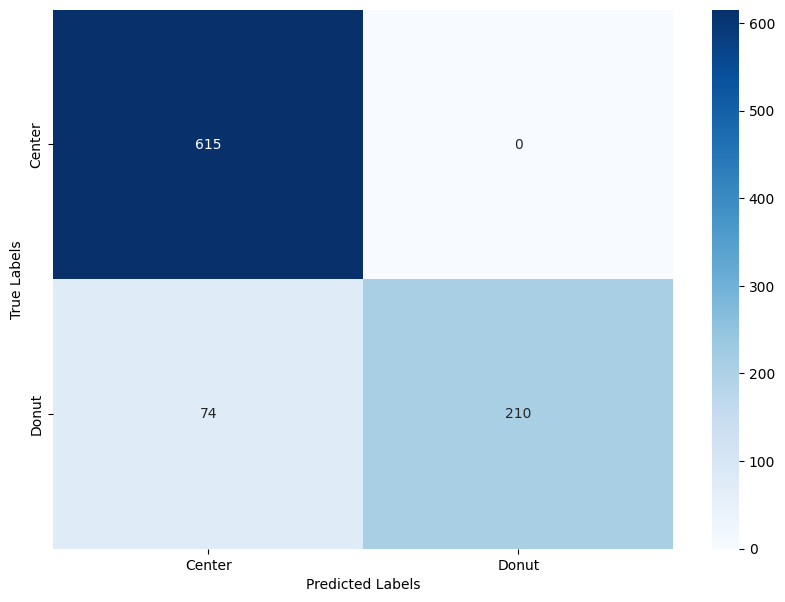

In [240]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1) Build a safe reverse map with integer keys
int2string = {int(v): str(k) for k, v in string2int.items()}

# 2) Predict on X_train
y_train_pred = svc_model.predict(X_train)

# 3) Convert numeric labels back to string labels
y_train_true_str = [int2string.get(int(lbl), str(lbl)) for lbl in y_train]
y_train_pred_str = [int2string.get(int(lbl), str(lbl)) for lbl in y_train_pred]

# 4) Define a fixed label order for axes
labels_order = list(string2int.keys())

# 5) Compute and plot the confusion matrix
cm = confusion_matrix(y_train_true_str, y_train_pred_str, labels=labels_order)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels_order, yticklabels=labels_order)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")


# 6) Print a short header before plotting
print("Confusion Matrix for Training Data:")

In [241]:
# TODO: get the predicted labels of the validation data and calculate the accuracy, and calculate the accuracy for each failure type

# print(f'Model accuracy on SVC validation data set is {acc_valid:.2f}%')
# print(f'Model accuracy on SVC validation data set for each class is {accuracies_valid}%')
call_llm(prompt="""
You are helping complete a single TODO in a Jupyter notebook for ECE 157A/272A HW3.

Context:
We have an SVC model (svc_model) already trained. We also have X_val, y_val, and mapping dictionaries string2int and int2string.  
We want to evaluate the model on the validation dataset to measure performance.

Task:
Implement the following TODO:

# TODO: get the predicted labels of the validation data and calculate the accuracy, and calculate the accuracy for each failure type

Requirements:
1) Predict validation labels:
   y_val_pred = svc_model.predict(X_val)
2) Compute overall accuracy using the calculate_accuracy function.
3) Compute per-class accuracies using the calculate_per_class_accuracy function.
4) Multiply overall accuracy by 100.0 for percentage.
5) Print:
   Model accuracy on SVC validation data set is {acc_valid:.2f}%
   Model accuracy on SVC validation data set for each class is {accuracies_valid}

Return:
Only the full code block, no extra text.
""")



```python
# Step 1: Predict validation labels
y_val_pred = svc_model.predict(X_val)

# Step 2: Compute overall accuracy
acc_valid = calculate_accuracy(y_val, y_val_pred) * 100.0

# Step 3: Compute per-class accuracies
accuracies_valid = calculate_per_class_accuracy(y_val, y_val_pred, mapping=int2string)

# Step 4: Print results
print(f"Model accuracy on SVC validation data set is {acc_valid:.2f}%")
print(f"Model accuracy on SVC validation data set for each class is {accuracies_valid}")
```


In [243]:
# Step 1: Predict validation labels
y_val_pred = svc_model.predict(X_val)

# Step 2: Compute overall accuracy
acc_valid = calculate_accuracy(y_val_pred, y_val) * 100.0

# Step 3: Compute per-class accuracies
accuracies_valid = calculate_per_class_accuracy(y_val_pred, y_val)

# Step 4: Print results
print(f"Model accuracy on SVC validation data set is {acc_valid:.2f}%")
print(f"Model accuracy on SVC validation data set for each class is {accuracies_valid}")


Model accuracy on SVC validation data set is 82.91%
Model accuracy on SVC validation data set for each class is {'Center': 0.9935064935064936, 'Donut': 0.6410256410256411, '2': 0.8706896551724138, '3': 0.0, '4': 0.6144578313253012}


In [244]:
# TODO: compute the confusion matrix and plot it using seaborn heatmap
# Hint: Do not forget to convert numeric labels back to string labels. Provide x and y axes labels.

# plt.show()

call_llm(prompt="""
You are helping complete a single TODO in a Jupyter notebook for ECE 157A/272A HW3.

Context:
We have an SVC model named svc_model, and we have already computed its validation predictions on X_val.
We also have the dictionaries string2int and int2string for mapping between class names and integers.
We now need to visualize the confusion matrix for the validation data.

Task:
Implement the code that does the following:
1) Predict validation labels:
   y_val_pred = svc_model.predict(X_val)
2) Convert numeric labels (both true and predicted) to their string class names using:
   y_val_true_str = [int2string.get(int(lbl), str(lbl)) for lbl in y_val]
   y_val_pred_str = [int2string.get(int(lbl), str(lbl)) for lbl in y_val_pred]
3) Compute the confusion matrix using:
   cm = confusion_matrix(y_val_true_str, y_val_pred_str, labels=list(string2int.keys()))
4) Plot the confusion matrix using seaborn heatmap:
   - figsize=(8,6)
   - cmap='Blues'
   - annot=True, fmt='d'
   - xticklabels=list(string2int.keys())
   - yticklabels=list(string2int.keys())
   - xlabel = "Predicted Labels"
   - ylabel = "True Labels"
   - title = "SVC Confusion Matrix (Validation Data)"
   - plt.tight_layout(); plt.show()

Return:
Only the complete code block. No extra text.
""")


```python
# Step 1: Predict validation labels
y_val_pred = svc_model.predict(X_val)

# Step 2: Convert numeric labels to string class names
y_val_true_str = [int2string.get(int(lbl), str(lbl)) for lbl in y_val]
y_val_pred_str = [int2string.get(int(lbl), str(lbl)) for lbl in y_val_pred]

# Step 3: Compute the confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_val_true_str, y_val_pred_str, labels=list(string2int.keys()))

# Step 4: Plot the confusion matrix using seaborn heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(cm, cmap='Blues', annot=True, fmt='d',
            xticklabels=list(string2int.keys()), yticklabels=list(string2int.keys()))
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("SVC Confusion Matrix (Validation Data)")
plt.tight_layout()
plt.show()
```


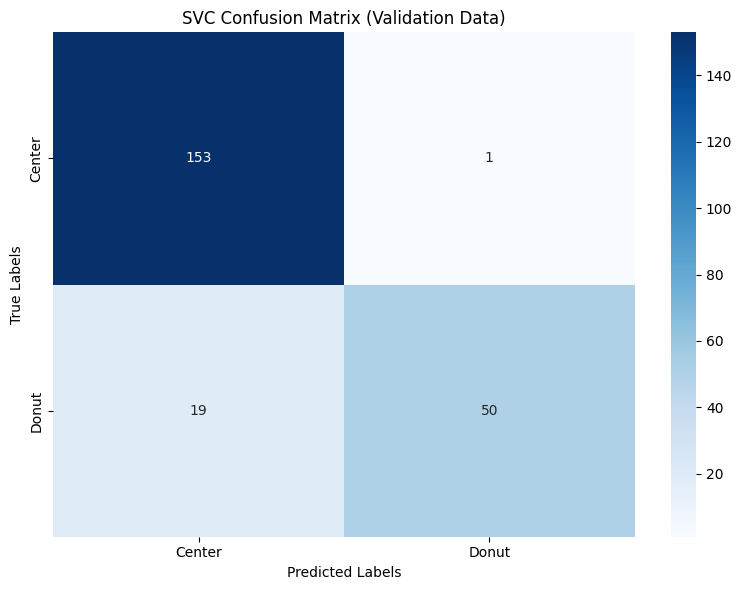

In [245]:
# Step 1: Predict validation labels
y_val_pred = svc_model.predict(X_val)

# Step 2: Convert numeric labels to string class names
y_val_true_str = [int2string.get(int(lbl), str(lbl)) for lbl in y_val]
y_val_pred_str = [int2string.get(int(lbl), str(lbl)) for lbl in y_val_pred]

# Step 3: Compute the confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_val_true_str, y_val_pred_str, labels=list(string2int.keys()))

# Step 4: Plot the confusion matrix using seaborn heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(cm, cmap='Blues', annot=True, fmt='d',
            xticklabels=list(string2int.keys()), yticklabels=list(string2int.keys()))
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("SVC Confusion Matrix (Validation Data)")
plt.tight_layout()
plt.show()

In [248]:
call_llm(prompt="""
You are helping complete a single TODO in a Jupyter notebook for ECE 157A/272A HW3.

Context:
We have a test dataset stored in 'data/wafermap_test.npy' that needs to be loaded for evaluation.  
It contains structured NumPy records similar to the training data, including 'waferMap' and possibly 'failureType'.

Task:
Implement the code for the following TODO:

# TODO: Load test dataset as pandas dataframe

Requirements:
1) Load the test data from 'data/wafermap_test.npy' using np.load with allow_pickle=True.
2) Convert the structured NumPy array into a pandas DataFrame using:
   pd.DataFrame.from_records(test_data.tolist(), columns=test_data.dtype.names)
3) Assign the DataFrame to a variable named `test_data_set`.
4) Print its shape and display the first few rows to verify it loaded correctly.

Return:
Only the complete code block. No extra text.
""")



```python
import numpy as np
import pandas as pd

# Load the test dataset
test_data = np.load('data/wafermap_test.npy', allow_pickle=True)

# Convert to pandas DataFrame
test_data_set = pd.DataFrame.from_records(test_data.tolist(), columns=test_data.dtype.names)

# Print shape and display first few rows
print(test_data_set.shape)
print(test_data_set.head())
```


In [249]:
import numpy as np
import pandas as pd

# Load the test dataset
test_data = np.load('data/wafermap_test.npy', allow_pickle=True)

# Convert to pandas DataFrame
test_data_set = pd.DataFrame.from_records(test_data.tolist(), columns=test_data.dtype.names)

# Print shape and display first few rows
print(test_data_set.shape)
print(test_data_set.head())

(2026, 5)
   dieSize   lotName trainTestLabel  waferIndex  \
0   3031.0  lot41961           Test         1.0   
1   3028.0  lot41962           Test         1.0   
2   3025.0  lot41962           Test        18.0   
3   3024.0  lot41967           Test        20.0   
4   1233.0  lot42448           Test         4.0   

                                            waferMap  
0  [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...  
1  [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...  
2  [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...  
3  [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...  
4  [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...  


In [250]:
# TODO: Apply data preparation function, feature extraction function, and create feature columns function on the test dataframe
call_llm(prompt="""
You are helping complete a single TODO in a Jupyter notebook for ECE 157A/272A HW3.

Context:
- The test dataframe is already loaded as `test_data_set` with columns including 'waferMap'.
- Earlier helper pieces exist:
  * prepare_data(df, has_labels: bool) -> Tuple[np.ndarray, list]
  * get_salient_region(row) which expects 'waferMap'
  * create_feature_columns(df) which expects 'waferMap' and 'salientRegion'
- Engineered feature list already defined as:
  features = ['areaRatio','perimeterRatio','maxDistFromCenter','minDistFromCenter','majorAxisRatio','minorAxisRatio','solidity','eccentricity','yieldLoss','edgeYieldLoss']

Task:
Write a short, clean code cell that:
1) Makes a safe copy: df_test = test_data_set.copy()
2) Uses prepare_data on the test set with has_labels=False to produce 64x64 maps:
   X_test_64, _ = prepare_data(df_test, has_labels=False)
3) Replaces df_test['waferMap'] with the resized maps:
   df_test['waferMap'] = list(X_test_64)
4) Creates the salient region column:
   df_test['salientRegion'] = df_test.apply(get_salient_region, axis=1)
5) Calls create_feature_columns(df_test) to add all 10 engineered features
6) Extracts the final test feature matrix:
   X_test = df_test[features]
7) Prints brief confirmations:
   - shapes of X_test_64 and X_test
   - head of df_test[features].head(3)

Requirements:
- Keep it minimal and self contained
- Add brief comments above logical blocks
- Do not modify or reference training data variables
- Do not print extra prose

Return:
Only the complete code block. No extra text.
""")


```python
# Step 1: Make a safe copy of the test data
df_test = test_data_set.copy()

# Step 2: Prepare the test data to produce 64x64 maps
X_test_64, _ = prepare_data(df_test, has_labels=False)

# Step 3: Replace df_test['waferMap'] with the resized maps
df_test['waferMap'] = list(X_test_64)

# Step 4: Create the salient region column
df_test['salientRegion'] = df_test.apply(get_salient_region, axis=1)

# Step 5: Call create_feature_columns to add engineered features
create_feature_columns(df_test)

# Step 6: Extract the final test feature matrix
X_test = df_test[features]

# Step 7: Print shapes and head of engineered features
print(f"Shape of X_test_64: {X_test_64.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(df_test[features].head(3))
```


In [251]:
# Step 1: Make a safe copy of the test data
df_test = test_data_set.copy()

# Step 2: Prepare the test data to produce 64x64 maps
X_test_64, _ = prepare_data(df_test, has_labels=False)

# Step 3: Replace df_test['waferMap'] with the resized maps
df_test['waferMap'] = list(X_test_64)

# Step 4: Create the salient region column
df_test['salientRegion'] = df_test.apply(get_salient_region, axis=1)

# Step 5: Call create_feature_columns to add engineered features
create_feature_columns(df_test)

# Step 6: Extract the final test feature matrix
X_test = df_test[features]

# Step 7: Print shapes and head of engineered features
print(f"Shape of X_test_64: {X_test_64.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(df_test[features].head(3))

Shape of X_test_64: (2026, 64, 64)
Shape of X_test: (2026, 10)
   areaRatio  perimeterRatio  maxDistFromCenter  minDistFromCenter  \
0   0.015161        0.734566           7.000000                0.0   
1   0.006813        0.367283           7.071068                0.0   
2   0.016139        0.792489          12.041595                0.0   

   majorAxisRatio  minorAxisRatio  solidity  eccentricity  yieldLoss  \
0        0.239620        0.169022  0.653333      0.708834   0.099319   
1        0.263624        0.092534  0.564103      0.936373   0.120161   
2        0.314612        0.218714  0.426230      0.718828   0.132837   

   edgeYieldLoss  
0       0.218009  
1       0.179592  
2       0.154545  


In [252]:
# TODO: From the dataframe select the 10 features we want to use and extract them as X
call_llm(prompt="""
You are helping complete a single TODO in a Jupyter notebook for ECE 157A/272A HW3.

Context:
We are now working with the test dataset called `df_test`, which already contains the 10 engineered features computed earlier:
['areaRatio', 'perimeterRatio', 'maxDistFromCenter', 'minDistFromCenter', 
 'majorAxisRatio', 'minorAxisRatio', 'solidity', 'eccentricity', 
 'yieldLoss', 'edgeYieldLoss'].

Task:
Complete this TODO:
# TODO: From the dataframe select the 10 features we want to use and extract them as X

Requirements:
1) Define a list variable `features` with the 10 column names.
2) Select only those columns from `df_test` and assign them to `X_test`.
3) Print the shape of `X_test` and its first few rows for verification.

Return:
Only the complete code cell that satisfies this TODO.
""")


```python
# TODO: From the dataframe select the 10 features we want to use and extract them as X

# Define the list of features
features = ['areaRatio', 'perimeterRatio', 'maxDistFromCenter', 'minDistFromCenter', 
            'majorAxisRatio', 'minorAxisRatio', 'solidity', 'eccentricity', 
            'yieldLoss', 'edgeYieldLoss']

# Select the features from df_test and assign them to X_test
X_test = df_test[features]

# Print the shape of X_test and its first few rows for verification
print(X_test.shape)
print(X_test.head())
```


In [253]:
# TODO: From the dataframe select the 10 features we want to use and extract them as X

# Define the list of features
features = ['areaRatio', 'perimeterRatio', 'maxDistFromCenter', 'minDistFromCenter', 
            'majorAxisRatio', 'minorAxisRatio', 'solidity', 'eccentricity', 
            'yieldLoss', 'edgeYieldLoss']

# Select the features from df_test and assign them to X_test
X_test = df_test[features]

# Print the shape of X_test and its first few rows for verification
print(X_test.shape)
print(X_test.head())

(2026, 10)
   areaRatio  perimeterRatio  maxDistFromCenter  minDistFromCenter  \
0   0.015161        0.734566           7.000000                0.0   
1   0.006813        0.367283           7.071068                0.0   
2   0.016139        0.792489          12.041595                0.0   
3   0.032278        1.696249          12.649111                0.0   
4   0.005260        0.287262           8.062258                2.0   

   majorAxisRatio  minorAxisRatio  solidity  eccentricity  yieldLoss  \
0        0.239620        0.169022  0.653333      0.708834   0.099319   
1        0.263624        0.092534  0.564103      0.936373   0.120161   
2        0.314612        0.218714  0.426230      0.718828   0.132837   
3        0.509207        0.309564  0.426230      0.793988   0.171322   
4        0.168868        0.098803  0.680000      0.810969   0.046720   

   edgeYieldLoss  
0       0.218009  
1       0.179592  
2       0.154545  
3       0.155932  
4       0.089552  


In [254]:
# TODO: Get the predicted labels of the test data for both Decision Tree and SVC
# Hint: Don't forget to convert numeric labels back to string labels
call_llm(prompt="""
You are helping complete a single TODO in a Jupyter notebook for ECE 157A/272A HW3.

Context:
- You have two trained models: `dt_model` (Decision Tree) and `svc_model` (Support Vector Classifier).
- The test feature matrix is stored in `X_test`.
- The mapping dictionary `int2string` converts numeric class labels back to their string names.

Task:
Complete this TODO:
# TODO: Get the predicted labels of the test data for both Decision Tree and SVC
# Hint: Don't forget to convert numeric labels back to string labels

Requirements:
1) Use both models to predict labels on `X_test`:
   - dt_pred_labels = dt_model.predict(X_test)
   - svc_pred_labels = svc_model.predict(X_test)
2) Convert numeric predictions to string class names using `int2string`.
   - dt_pred_labels_str = [int2string[int(lbl)] for lbl in dt_pred_labels]
   - svc_pred_labels_str = [int2string[int(lbl)] for lbl in svc_pred_labels]
3) Print brief confirmations:
   - Number of predictions for each model
   - Unique predicted classes for each model

Return:
Only the complete code cell that fulfills this TODO.
""")


```python
# TODO: Get the predicted labels of the test data for both Decision Tree and SVC
dt_pred_labels = dt_model.predict(X_test)
svc_pred_labels = svc_model.predict(X_test)

dt_pred_labels_str = [int2string[int(lbl)] for lbl in dt_pred_labels]
svc_pred_labels_str = [int2string[int(lbl)] for lbl in svc_pred_labels]

# Print confirmations
print(f"Number of predictions for Decision Tree: {len(dt_pred_labels_str)}")
print(f"Unique predicted classes for Decision Tree: {set(dt_pred_labels_str)}")

print(f"Number of predictions for SVC: {len(svc_pred_labels_str)}")
print(f"Unique predicted classes for SVC: {set(svc_pred_labels_str)}")
```


In [256]:
# TODO: Get the predicted labels of the test data for both Decision Tree and SVC
dt_pred_labels = dt_model.predict(X_test)
svc_pred_labels = svc_model.predict(X_test)

# Convert numpy types to plain int before mapping
dt_pred_labels_str = [int2string[int(lbl)] if int(lbl) in int2string else str(lbl) for lbl in dt_pred_labels]
svc_pred_labels_str = [int2string[int(lbl)] if int(lbl) in int2string else str(lbl) for lbl in svc_pred_labels]

# Print confirmations
print(f"Number of predictions for Decision Tree: {len(dt_pred_labels_str)}")
print(f"Unique predicted classes for Decision Tree: {set(dt_pred_labels_str)}")

print(f"Number of predictions for SVC: {len(svc_pred_labels_str)}")
print(f"Unique predicted classes for SVC: {set(svc_pred_labels_str)}")


Number of predictions for Decision Tree: 2026
Unique predicted classes for Decision Tree: {'Donut', '3', '4', 'Center', '2'}
Number of predictions for SVC: 2026
Unique predicted classes for SVC: {'Donut', 'Center', '2', '4'}


In [257]:
# Save output as `dt_scores.csv` and `svc_scores.csv`

# pd.Series(pred_test_tree).to_csv('dt_scores.csv', header=False, index=False)
# pd.Series(pred_test_svc).to_csv('svc_scores.csv', header=False, index=False)

call_llm(prompt="""
You are helping complete a single TODO in a Jupyter notebook for ECE 157A/272A HW3.

Context:
We have generated two sets of predicted labels for the test dataset:
- Decision Tree predictions: `dt_pred_labels_str`
- SVC predictions: `svc_pred_labels_str`

Task:
Complete this TODO:
# TODO: Save output as `dt_scores.csv` and `svc_scores.csv`

Requirements:
1) Convert the predicted string labels into pandas Series.
2) Save each as a separate CSV file:
   - `dt_scores.csv` for Decision Tree predictions
   - `svc_scores.csv` for SVC predictions
3) Do not include headers or indexes in the CSV output.
4) After saving, print confirmation messages with file names and lengths of saved predictions.

Return:
Only the complete code cell that performs this TODO.
""")


```python
import pandas as pd

# Convert the predicted string labels into pandas Series
dt_series = pd.Series(dt_pred_labels_str)
svc_series = pd.Series(svc_pred_labels_str)

# Save each as a separate CSV file without headers or indexes
dt_series.to_csv('dt_scores.csv', index=False, header=False)
svc_series.to_csv('svc_scores.csv', index=False, header=False)

# Print confirmation messages
print(f'dt_scores.csv saved with {len(dt_series)} predictions.')
print(f'svc_scores.csv saved with {len(svc_series)} predictions.')
```


In [258]:
import pandas as pd

# Convert the predicted string labels into pandas Series
dt_series = pd.Series(dt_pred_labels_str)
svc_series = pd.Series(svc_pred_labels_str)

# Save each as a separate CSV file without headers or indexes
dt_series.to_csv('dt_scores.csv', index=False, header=False)
svc_series.to_csv('svc_scores.csv', index=False, header=False)

# Print confirmation messages
print(f'dt_scores.csv saved with {len(dt_series)} predictions.')
print(f'svc_scores.csv saved with {len(svc_series)} predictions.')

dt_scores.csv saved with 2026 predictions.
svc_scores.csv saved with 2026 predictions.


In [260]:
import numpy as np
import pandas as pd

# Rebuild a safe reverse map from the original mapping
# Expected original: {'Center':0,'Donut':1,'Edge-Loc':2,'Near-full':3,'Scratch':4}
label_order = ['Center','Donut','Edge-Loc','Near-full','Scratch']

# If string2int exists, trust it. Otherwise fall back to the canonical order above.
if 'string2int' in globals() and isinstance(string2int, dict) and len(string2int) > 0:
    int2string = {int(v): str(k) for k, v in string2int.items()}
else:
    int2string = {i: name for i, name in enumerate(label_order)}

# Ensure all expected keys exist
for i, name in enumerate(label_order):
    int2string.setdefault(i, name)

# Helper to convert any numeric predictions to string labels
def to_str_labels(arr, mapping):
    out = []
    for x in arr:
        if isinstance(x, (np.integer, int)):
            out.append(mapping[int(x)])
        elif isinstance(x, str):
            out.append(x)
        else:
            out.append(mapping[int(x)])
    return out

# Convert predictions
dt_pred_labels_str  = to_str_labels(dt_pred_labels, int2string)
svc_pred_labels_str = to_str_labels(svc_pred_labels, int2string)

# Quick sanity checks
allowed = set(label_order)
print("DT unique:", set(dt_pred_labels_str))
print("SVC unique:", set(svc_pred_labels_str))

# Save one label per line
pd.Series(dt_pred_labels_str).to_csv('dt_scores.csv', header=False, index=False)
pd.Series(svc_pred_labels_str).to_csv('svc_scores.csv', header=False, index=False)

print("Saved", len(dt_pred_labels_str), "to dt_scores.csv")
print("Saved", len(svc_pred_labels_str), "to svc_scores.csv")



DT unique: {'Donut', 'Near-full', 'Edge-Loc', 'Scratch', 'Center'}
SVC unique: {'Donut', 'Center', 'Edge-Loc', 'Scratch'}
Saved 2026 to dt_scores.csv
Saved 2026 to svc_scores.csv


In [261]:
import pandas as pd

ALLOWED = {'Center','Donut','Edge-Loc','Near-full','Scratch'}

# 1) Reload the files
dt_out  = pd.read_csv('dt_scores.csv',  header=None, names=['label'])
svc_out = pd.read_csv('svc_scores.csv', header=None, names=['label'])

# 2) Basic checks
print("Rows match test set?",
      len(dt_out) == len(X_test) and len(svc_out) == len(X_test))

print("Only allowed labels in DT?",
      set(dt_out['label'].unique()).issubset(ALLOWED))
print("Only allowed labels in SVC?",
      set(svc_out['label'].unique()).issubset(ALLOWED))

# 3) Quick distribution view
print("\nDT label counts:\n", dt_out['label'].value_counts())
print("\nSVC label counts:\n", svc_out['label'].value_counts())

Rows match test set? True
Only allowed labels in DT? True
Only allowed labels in SVC? True

DT label counts:
 label
Edge-Loc     1571
Center        268
Scratch        99
Donut          65
Near-full      23
Name: count, dtype: int64

SVC label counts:
 label
Edge-Loc    1533
Center       297
Scratch      173
Donut         23
Name: count, dtype: int64


In [262]:
import pandas as pd

# Re-create DataFrames with the correct header name
pd.DataFrame({'failureType': dt_pred_labels_str}).to_csv('dt_scores.csv', index=False)
pd.DataFrame({'failureType': svc_pred_labels_str}).to_csv('svc_scores.csv', index=False)

print("Files saved with header 'failureType'")

Files saved with header 'failureType'
